# 🛡️ Dynamic Graph-Based Intrusion Detection in IoT/IIoT Networks
## Using the TON_IoT Network Dataset — Complete Sample-Style Pipeline

---

| | |
|---|---|
| **Course** | AIML505 – Statistics for Data Science |
| **Project** | Dynamic Graph-Based Intrusion Detection in IoT/IIoT Networks |
| **Dataset** | TON_IoT – Network + IoT/Linux/Windows telemetry collection |
| **Primary modelling file** | `Train_Test_Network_dataset/train_test_network.csv` |
| **Graph semantics** | IP hosts = nodes; network flows = directed edges |
| **Execution target** | Kaggle Notebook (CPU/GPU compatible) |
| **Group** | A / Group 1 |

### Team
- Sababa Hoque Saba — 2026-2-74-003
- Parmita Hossain Simia — 2026-2-74-009
- Asfar Hossain Sitab — 2026-2-74-008

---

## Abstract

This notebook reproduces the complete structure and modelling coverage of the supplied sample notebook, but adapts it correctly to the **TON_IoT** dataset and the Group-A dynamic graph intrusion-detection problem.

### Track A – Classical ML & Sequential Deep Learning
Feature-vector based intrusion detection using:
- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- AdaBoost
- XGBoost
- LightGBM
- CatBoost
- Gaussian Naive Bayes
- KNN
- Linear SVM
- MLP
- RNN
- LSTM
- GRU
- BiLSTM
- CNN-LSTM

### Track B – Graph Neural Networks
The TON_IoT communication system is represented as:
- **Nodes:** IP hosts
- **Directed edges:** `src_ip → dst_ip` flows
- **Node features:** label-free communication aggregates
- **Edge features:** TON_IoT flow attributes
- **Target:** benign vs attack flow

Four paper-inspired GNN architectures are implemented in pure PyTorch:
**GCN, GraphSAGE, GAT, and GIN**.

A supplementary **flow-similarity k-NN graph** is also retained so that the graph-analysis content of the supplied sample is not lost.

---

## Research Questions

1. Do GNNs exploit host-to-host communication structure to improve intrusion detection?
2. Which classical model provides the best detection / speed trade-off?
3. Do ordered-flow sequence models improve recall?
4. How do attack categories distribute in the feature space?
5. Which host connections dominate the TON_IoT communication graph?
6. Does a connection-disjoint split change model ranking compared with ordinary random-flow evaluation?

---

## 📋 Notebook Sections

| # | Section | Description |
|---|---|---|
| 1 | Introduction | Project overview and research questions |
| 2 | Imports | Libraries and fallbacks |
| 3 | Global Configuration | Seeds, paths, hyperparameters |
| 4 | Dataset Loading | Kaggle auto-discovery + leakage-aware split |
| 5 | Dataset Inspection | Dynamic schema detection |
| 6 | Exploratory Data Analysis | Distributions, PCA, t-SNE, UMAP |
| 7 | Statistical Analysis | Descriptive stats, tests, stationarity |
| 8 | Data Cleaning | Imputation and deduplication |
| 9 | Feature Engineering | Flow, rolling and graph-topology features |
| 10 | Data Encoding | OOV-safe categorical encoding |
| 11 | Scaling | Train-only MinMax scaling |
| 12 | Class Imbalance Analysis | Balanced weights |
| 13 | Correlation Analysis | Redundancy removal + RF importance |
| 14 | Stationarity Analysis | Engineered rolling variables |
| 15 | Time-Series Preparation | Sliding-window sequences |
| 16 | Graph Construction | Main host graph + k-NN graph |
| 17 | Graph Visualisation | Connection graph, ego graph, matrices |
| 18 | Track A – ML Models | Complete classical baseline set |
| 19 | Track A – DL Models | RNN, LSTM, GRU, BiLSTM, CNN-LSTM |
| 20 | Track B – GNN Models | GCN, GraphSAGE, GAT, GIN |
| 21 | Hyperparameter Tuning | Optuna LightGBM tuning |
| 22 | Model Evaluation | Metrics, ROC, PR curves |
| 23 | Comparative Analysis | Rankings + McNemar test |
| 24 | Error Analysis | Confusion matrices, FP/FN audit |
| 25 | Discussion | Statistical and security interpretation |
| 26 | Conclusion & Future Work | Findings and extensions |
| 27 | References & Reproducibility | Papers, checklist, viva notes |

## 2. Imports

This section retains the broad import coverage of the supplied sample notebook. Optional packages are handled safely so a missing non-essential package does not break the whole Kaggle run.

The GNNs use pure PyTorch, therefore PyTorch Geometric and DGL are optional rather than required.

In [1]:
# ─── Standard Library ────────────────────────────────────────────────────────
import os, sys, time, random, warnings, subprocess, json, hashlib, zipfile, glob, pickle
from pathlib import Path
from copy import deepcopy
from collections import Counter

# ─── Data Science Core ───────────────────────────────────────────────────────
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

# ─── Statsmodels ─────────────────────────────────────────────────────────────
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.holtwinters import SimpleExpSmoothing

# ─── Scikit-Learn ────────────────────────────────────────────────────────────
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.neighbors import kneighbors_graph, KNeighborsClassifier
from sklearn.ensemble import (RandomForestClassifier, ExtraTreesClassifier,
                              AdaBoostClassifier, IsolationForest, GradientBoostingClassifier)
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import LinearSVC
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, average_precision_score,
                             precision_recall_curve, roc_curve, auc,
                             confusion_matrix, classification_report)

# ─── Graph / Network Analysis ────────────────────────────────────────────────
import networkx as nx

# ─── Gradient Boosting (optional-safe) ───────────────────────────────────────
XGB_AVAILABLE = LGB_AVAILABLE = CAT_AVAILABLE = False

try:
    import xgboost as xgb
    XGB_AVAILABLE = True
except Exception as e:
    print("⚠ XGBoost unavailable:", e)

try:
    import lightgbm as lgb
    LGB_AVAILABLE = True
except Exception as e:
    print("⚠ LightGBM unavailable:", e)

try:
    import catboost as cb
    CAT_AVAILABLE = True
except Exception as e:
    print("⚠ CatBoost unavailable:", e)

# ─── PyTorch ─────────────────────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

warnings.filterwarnings("ignore")

def safe_optional_import(package_name, import_name=None):
    """Import an optional package; try pip install only as a fallback."""
    import_name = import_name or package_name
    try:
        return __import__(import_name), True
    except Exception:
        try:
            subprocess.check_call([sys.executable, "-m", "pip", "install", package_name, "-q"])
            return __import__(import_name), True
        except Exception as e:
            print(f"⚠ Optional package '{package_name}' unavailable: {e}")
            return None, False

# Optuna
try:
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)
    OPTUNA_AVAILABLE = True
except Exception:
    optuna, OPTUNA_AVAILABLE = safe_optional_import("optuna")
    if OPTUNA_AVAILABLE:
        import optuna
        optuna.logging.set_verbosity(optuna.logging.WARNING)

# UMAP
try:
    import umap
    UMAP_AVAILABLE = True
except Exception:
    umap, UMAP_AVAILABLE = safe_optional_import("umap-learn", "umap")

# tabulate
try:
    from tabulate import tabulate
    TABULATE_AVAILABLE = True
except Exception:
    _, TABULATE_AVAILABLE = safe_optional_import("tabulate")
    if TABULATE_AVAILABLE:
        from tabulate import tabulate

# Optional GNN packages (not required)
try:
    import torch_geometric
    PYG_AVAILABLE = True
except Exception:
    PYG_AVAILABLE = False

# Aesthetic setup
sns.set_theme(style="darkgrid", palette="muted", font_scale=1.05)
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "axes.titlesize": 14,
    "axes.labelsize": 12,
    "figure.dpi": 100,
    "savefig.bbox": "tight",
})

print("✅ Core imports successful.")
print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("PyTorch:", torch.__version__)
print("XGBoost:", XGB_AVAILABLE, "| LightGBM:", LGB_AVAILABLE, "| CatBoost:", CAT_AVAILABLE)
print("UMAP:", UMAP_AVAILABLE, "| Optuna:", OPTUNA_AVAILABLE, "| PyG:", PYG_AVAILABLE)

✅ Core imports successful.
Python: 3.12.13
NumPy: 2.0.2
Pandas: 2.3.3
PyTorch: 2.10.0+cu128
XGBoost: True | LightGBM: True | CatBoost: True
UMAP: True | Optuna: True | PyG: False


## 3. Global Configuration

A single configuration class centralises all tuneable parameters. The defaults are designed for a full Kaggle run while remaining CPU-feasible.

In [2]:
class Config:
    """Central configuration for the complete TON_IoT notebook."""

    NETWORK_BASENAME = "train_test_network.csv"
    LOCAL_ZIP = "/mnt/data/Train_Test_datasets.zip"  # local smoke-test fallback only

    SEED = 42
    DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

    # Deterministic connection-disjoint split
    HASH_MOD = 10
    TRAIN_BUCKETS = tuple(range(0, 7))
    TEST_BUCKETS  = tuple(range(7, 10))
    TUNE_BUCKETS  = tuple(range(0, 6))
    VAL_BUCKETS   = (6,)

    # Sampling
    TRAIN_SAMPLE = 15_000
    TEST_SAMPLE  = 5_000
    DL_TRAIN     = 6_000
    DL_TEST      = 2_000

    # GNN edge samples
    GNN_TRAIN_EDGES = 12_000
    GNN_VAL_EDGES   = 3_000
    GNN_TEST_EDGES  = 5_000
    GNN_EDGE_FEATURES = 24

    # Sequential
    WINDOW_SIZE = 5

    # DL
    DL_EPOCHS   = 25
    DL_BATCH    = 64
    DL_LR       = 1e-3
    DL_HIDDEN   = 32
    DL_PATIENCE = 3

    # GNN
    GNN_EPOCHS   = 25
    GNN_LR       = 1e-3
    GNN_HIDDEN   = 32
    GNN_PATIENCE = 4
    GNN_K_NEIGHBORS = 5

    CORR_THRESHOLD = 0.95

    GRAPH_TOP_CONNECTIONS = 90
    EGO_NEIGHBORS = 35
    KNN_VIS_N = 200

CFG = Config()

def set_seed(seed: int) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    os.environ["PYTHONHASHSEED"] = str(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(CFG.SEED)
print(f"✅ Seed = {CFG.SEED} | Device = {CFG.DEVICE}")

✅ Seed = 42 | Device = cuda


## 4. Dataset Loading

The TON_IoT archive contains four major data domains:

1. **IoT telemetry** — Fridge, Garage Door, GPS Tracker, Modbus, Motion Light, Thermostat, Weather
2. **Linux telemetry** — Process, Disk, Memory
3. **Network traffic** — `train_test_network.csv`
4. **Windows telemetry** — Windows 7 and Windows 10

For this intrusion-detection project, the **network traffic file is the primary modelling table** because it contains source/destination IP addresses, ports, protocol, service, flow statistics, binary labels and attack types.

### Leakage-aware split

The supplied network file is already a combined `train_test_network.csv` and does not expose a true flow timestamp or capture ID. A random row split could place repeated `src_ip → dst_ip` relationships into both train and test sets.

Therefore, this notebook creates a deterministic **connection-disjoint split**:

\[
b(u,v)=\mathrm{MD5}(u\rightarrow v)\bmod 10
\]

- buckets `0–6` → training
- buckets `7–9` → testing

The same directed host pair can never occur in both partitions.

In [3]:
def stable_pair_bucket(src, dst, mod=10):
    """Stable deterministic bucket for a directed host pair."""
    key = f"{src}→{dst}".encode("utf-8")
    return int(hashlib.md5(key).hexdigest()[:8], 16) % mod

def discover_csvs():
    """Discover TON_IoT CSVs under Kaggle input; include local ZIP fallback."""
    rows = []
    seen = set()

    for root in ["/kaggle/input", "/mnt/data"]:
        if not os.path.exists(root):
            continue
        for p in glob.glob(os.path.join(root, "**", "*.csv"), recursive=True):
            if p in seen:
                continue
            seen.add(p)
            rows.append({"source": "filesystem", "path": p, "name": os.path.basename(p)})

    if os.path.exists(CFG.LOCAL_ZIP):
        with zipfile.ZipFile(CFG.LOCAL_ZIP) as zf:
            for name in zf.namelist():
                if name.lower().endswith(".csv"):
                    rows.append({"source": "zip", "path": name, "name": os.path.basename(name)})

    return pd.DataFrame(rows).drop_duplicates(subset=["source", "path"]).reset_index(drop=True)

inventory = discover_csvs()

if inventory.empty:
    raise FileNotFoundError(
        "No TON_IoT CSV files found. On Kaggle, attach the TON-IOT dataset using Add Data."
    )

def domain_from_path(path):
    p = path.lower()
    if "iot_dataset" in p:
        return "IoT telemetry"
    if "linux" in p:
        return "Linux telemetry"
    if "windows" in p:
        return "Windows telemetry"
    if "network" in p:
        return "Network traffic"
    return "Other"

inventory["domain"] = inventory["path"].map(domain_from_path)
display(inventory[["domain", "name", "source", "path"]].sort_values(["domain", "name"]).reset_index(drop=True))

def load_primary_network_dataset():
    fs_matches = inventory[
        (inventory["source"] == "filesystem") &
        (inventory["name"].str.lower() == CFG.NETWORK_BASENAME.lower())
    ]
    if len(fs_matches):
        path = fs_matches.iloc[0]["path"]
        print("Loading network dataset from:", path)
        return pd.read_csv(path), path

    zip_matches = inventory[
        (inventory["source"] == "zip") &
        (inventory["name"].str.lower() == CFG.NETWORK_BASENAME.lower())
    ]
    if len(zip_matches) and os.path.exists(CFG.LOCAL_ZIP):
        member = zip_matches.iloc[0]["path"]
        print("Loading network dataset from ZIP member:", member)
        with zipfile.ZipFile(CFG.LOCAL_ZIP) as zf:
            with zf.open(member) as f:
                return pd.read_csv(f), f"{CFG.LOCAL_ZIP}::{member}"

    raise FileNotFoundError(f"Could not locate {CFG.NETWORK_BASENAME}")

df_all_raw, NETWORK_SOURCE = load_primary_network_dataset()
df_all_raw = df_all_raw.copy()
df_all_raw["_row_id"] = np.arange(len(df_all_raw), dtype=np.int64)

required = {"src_ip", "dst_ip", "label", "type"}
missing_required = required - set(df_all_raw.columns)
if missing_required:
    raise ValueError(f"Required TON_IoT columns missing: {missing_required}")

df_all_raw["_pair_key"] = (
    df_all_raw["src_ip"].astype(str) + "→" + df_all_raw["dst_ip"].astype(str)
)
df_all_raw["_split_bucket"] = [
    stable_pair_bucket(s, d, CFG.HASH_MOD)
    for s, d in zip(df_all_raw["src_ip"], df_all_raw["dst_ip"])
]

df_train_raw = df_all_raw[df_all_raw["_split_bucket"].isin(CFG.TRAIN_BUCKETS)].copy()
df_test_raw  = df_all_raw[df_all_raw["_split_bucket"].isin(CFG.TEST_BUCKETS)].copy()

train_pairs = set(df_train_raw["_pair_key"])
test_pairs = set(df_test_raw["_pair_key"])
pair_overlap = train_pairs.intersection(test_pairs)

print("\n" + "=" * 72)
print("  TON_IoT NETWORK DATASET + CONNECTION-DISJOINT SPLIT")
print("=" * 72)
print(f"Source file                 : {NETWORK_SOURCE}")
print(f"Full dataset                : {len(df_all_raw):,} rows")
print(f"Training partition          : {len(df_train_raw):,} rows")
print(f"Testing partition           : {len(df_test_raw):,} rows")
print(f"Unique directed train pairs : {len(train_pairs):,}")
print(f"Unique directed test pairs  : {len(test_pairs):,}")
print(f"Pair overlap                : {len(pair_overlap)}")
print("=" * 72)

assert len(pair_overlap) == 0, "Connection leakage detected."

print("\nBinary label distribution:")
print(df_all_raw["label"].value_counts().sort_index().to_string())

print("\nAttack-type distribution:")
print(df_all_raw["type"].value_counts().to_string())

display(df_train_raw.head(3))

,domain,name,source,path
0,IoT telemetry,Train_Test_IoT_Fridge.csv,filesystem,/kaggle/input/datasets/asfarhossainsitab/ton-i...
1,IoT telemetry,Train_Test_IoT_GPS_Tracker.csv,filesystem,/kaggle/input/datasets/asfarhossainsitab/ton-i...
2,IoT telemetry,Train_Test_IoT_Garage_Door.csv,filesystem,/kaggle/input/datasets/asfarhossainsitab/ton-i...
3,IoT telemetry,Train_Test_IoT_Modbus.csv,filesystem,/kaggle/input/datasets/asfarhossainsitab/ton-i...
4,IoT telemetry,Train_Test_IoT_Motion_Light.csv,filesystem,/kaggle/input/datasets/asfarhossainsitab/ton-i...
5,IoT telemetry,Train_Test_IoT_Thermostat.csv,filesystem,/kaggle/input/datasets/asfarhossainsitab/ton-i...
6,IoT telemetry,Train_Test_IoT_Weather.csv,filesystem,/kaggle/input/datasets/asfarhossainsitab/ton-i...
7,Linux telemetry,Train_Test_Linux_process.csv,filesystem,/kaggle/input/datasets/asfarhossainsitab/ton-i...
8,Linux telemetry,Train_test_linux_disk.csv,filesystem,/kaggle/input/datasets/asfarhossainsitab/ton-i...
9,Linux telemetry,Train_test_linux_memory.csv,filesystem,/kaggle/input/datasets/asfarhossainsitab/ton-i...


Loading network dataset from: /kaggle/input/datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_Network_dataset/train_test_network.csv

  TON_IoT NETWORK DATASET + CONNECTION-DISJOINT SPLIT
Source file                 : /kaggle/input/datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_Network_dataset/train_test_network.csv
Full dataset                : 211,043 rows
Training partition          : 143,657 rows
Testing partition           : 67,386 rows
Unique directed train pairs : 728
Unique directed test pairs  : 298
Pair overlap                : 0

Binary label distribution:
label
0     50000
1    161043

Attack-type distribution:
type
normal        50000
backdoor      20000
ddos          20000
dos           20000
injection     20000
password      20000
scanning      20000
ransomware    20000
xss           20000
mitm           1043


,src_ip,src_port,dst_ip,dst_port,proto,service,duration,src_bytes,dst_bytes,conn_state,...,http_orig_mime_types,http_resp_mime_types,weird_name,weird_addl,weird_notice,label,type,_row_id,_pair_key,_split_bucket
0,192.168.1.37,4444,192.168.1.193,49178,tcp,-,290.371539,101568,2592,OTH,...,-,-,-,-,-,1,backdoor,0,192.168.1.37→192.168.1.193,0
1,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000102,0,0,REJ,...,-,-,-,-,-,1,backdoor,1,192.168.1.193→192.168.1.37,0
2,192.168.1.193,49180,192.168.1.37,8080,tcp,-,0.000148,0,0,REJ,...,-,-,-,-,-,1,backdoor,2,192.168.1.193→192.168.1.37,0


## 5. Dataset Inspection

The schema is detected dynamically.

TON_IoT-specific elements:
- Binary target: `label`
- Multi-class attack target: `type`
- Source endpoint: `src_ip`
- Destination endpoint: `dst_ip`
- Connection state: `conn_state`

Raw IP addresses are retained for graph construction but excluded from ordinary tabular feature vectors so that baseline models cannot simply memorise host identity.

In [4]:
def inspect_dataset(df_tr, df_te):
    schema = {}
    schema["binary_target"] = "label" if "label" in df_tr.columns else df_tr.columns[-2]
    schema["multiclass_target"] = "type" if "type" in df_tr.columns else None
    schema["id_col"] = None
    schema["src_col"] = "src_ip" if "src_ip" in df_tr.columns else None
    schema["dst_col"] = "dst_ip" if "dst_ip" in df_tr.columns else None
    schema["metadata_cols"] = [c for c in df_tr.columns if c.startswith("_")]

    schema["missing_train"] = int(df_tr.isnull().sum().sum())
    schema["missing_test"] = int(df_te.isnull().sum().sum())

    dup_subset = [c for c in df_tr.columns if not c.startswith("_")]
    schema["dup_train"] = int(df_tr.duplicated(subset=dup_subset).sum())
    schema["dup_test"] = int(df_te.duplicated(subset=dup_subset).sum())

    exclude = set([
        schema["binary_target"], schema["multiclass_target"],
        schema["src_col"], schema["dst_col"]
    ] + schema["metadata_cols"])

    schema["numeric_cols"] = [
        c for c in df_tr.select_dtypes(include=[np.number]).columns if c not in exclude
    ]
    schema["cat_cols"] = [
        c for c in df_tr.select_dtypes(exclude=[np.number]).columns if c not in exclude
    ]
    schema["attack_cats"] = (
        sorted(df_tr[schema["multiclass_target"]].astype(str).unique().tolist())
        if schema["multiclass_target"] else []
    )
    return schema

SCHEMA = inspect_dataset(df_train_raw, df_test_raw)

print("=" * 62)
print("  DATASET SCHEMA SUMMARY")
print("=" * 62)
print("Binary target       :", SCHEMA["binary_target"])
print("Multiclass target   :", SCHEMA["multiclass_target"])
print("Graph source column :", SCHEMA["src_col"])
print("Graph target column :", SCHEMA["dst_col"])
print("Numerical features  :", len(SCHEMA["numeric_cols"]))
print("Categorical features:", len(SCHEMA["cat_cols"]))
print("Missing (train)     :", SCHEMA["missing_train"])
print("Missing (test)      :", SCHEMA["missing_test"])
print("Duplicates (train)  :", SCHEMA["dup_train"])
print("Duplicates (test)   :", SCHEMA["dup_test"])
print("Attack categories   :", SCHEMA["attack_cats"])
print("=" * 62)

dtype_summary = pd.DataFrame({
    "dtype": df_train_raw.dtypes.astype(str),
    "n_unique": df_train_raw.nunique(dropna=False),
    "missing": df_train_raw.isnull().sum()
})
display(dtype_summary)

  DATASET SCHEMA SUMMARY
Binary target       : label
Multiclass target   : type
Graph source column : src_ip
Graph target column : dst_ip
Numerical features  : 16
Categorical features: 24
Missing (train)     : 0
Missing (test)      : 0
Duplicates (train)  : 14614
Duplicates (test)   : 5955
Attack categories   : ['backdoor', 'ddos', 'dos', 'injection', 'mitm', 'normal', 'password', 'ransomware', 'scanning', 'xss']


,dtype,n_unique,missing
src_ip,object,44,0
src_port,int64,25048,0
dst_ip,object,566,0
dst_port,int64,1993,0
proto,object,3,0
service,object,9,0
duration,float64,51786,0
src_bytes,int64,1796,0
dst_bytes,int64,1634,0
conn_state,object,13,0


## 6. Exploratory Data Analysis (EDA)

### 6.1 Target & Attack Distributions

We begin by characterising class balance, attack-category frequencies and protocol usage.

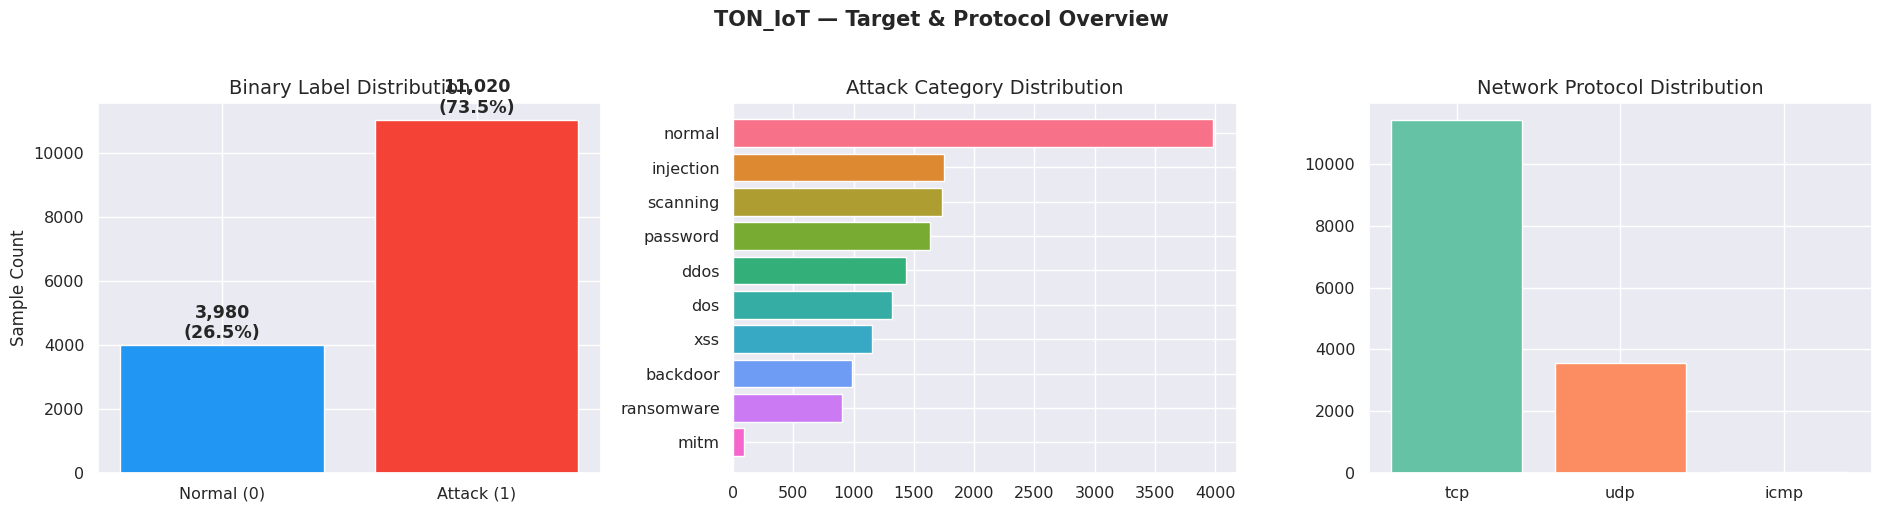

Class balance ratio (Normal:Attack) = 0.361:1


In [5]:
TARGET = SCHEMA["binary_target"]
MCTARGET = SCHEMA["multiclass_target"]

df_eda = df_train_raw.sample(
    n=min(CFG.TRAIN_SAMPLE, len(df_train_raw)),
    random_state=CFG.SEED
)

fig, axes = plt.subplots(1, 3, figsize=(19, 5))

vc = df_eda[TARGET].value_counts().reindex([0, 1], fill_value=0)
axes[0].bar(
    ["Normal (0)", "Attack (1)"], vc.values,
    color=["#2196F3", "#F44336"], edgecolor="white"
)
axes[0].set_title("Binary Label Distribution")
axes[0].set_ylabel("Sample Count")
for i, v in enumerate(vc.values):
    axes[0].text(
        i, v + max(vc.values)*0.02,
        f"{v:,}\n({v/max(vc.sum(),1)*100:.1f}%)",
        ha="center", fontweight="bold"
    )

cat_order = df_eda[MCTARGET].astype(str).value_counts()
axes[1].barh(
    cat_order.index, cat_order.values,
    color=sns.color_palette("husl", len(cat_order))
)
axes[1].set_title("Attack Category Distribution")
axes[1].invert_yaxis()

proto_vc = df_eda["proto"].astype(str).value_counts().head(10)
axes[2].bar(
    proto_vc.index, proto_vc.values,
    color=sns.color_palette("Set2", len(proto_vc))
)
axes[2].set_title("Network Protocol Distribution")

plt.suptitle("TON_IoT — Target & Protocol Overview", fontsize=15, y=1.02, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Class balance ratio (Normal:Attack) = {vc.get(0,0)/max(vc.get(1,1),1):.3f}:1")

### 6.2 Service & Connection-State Distributions

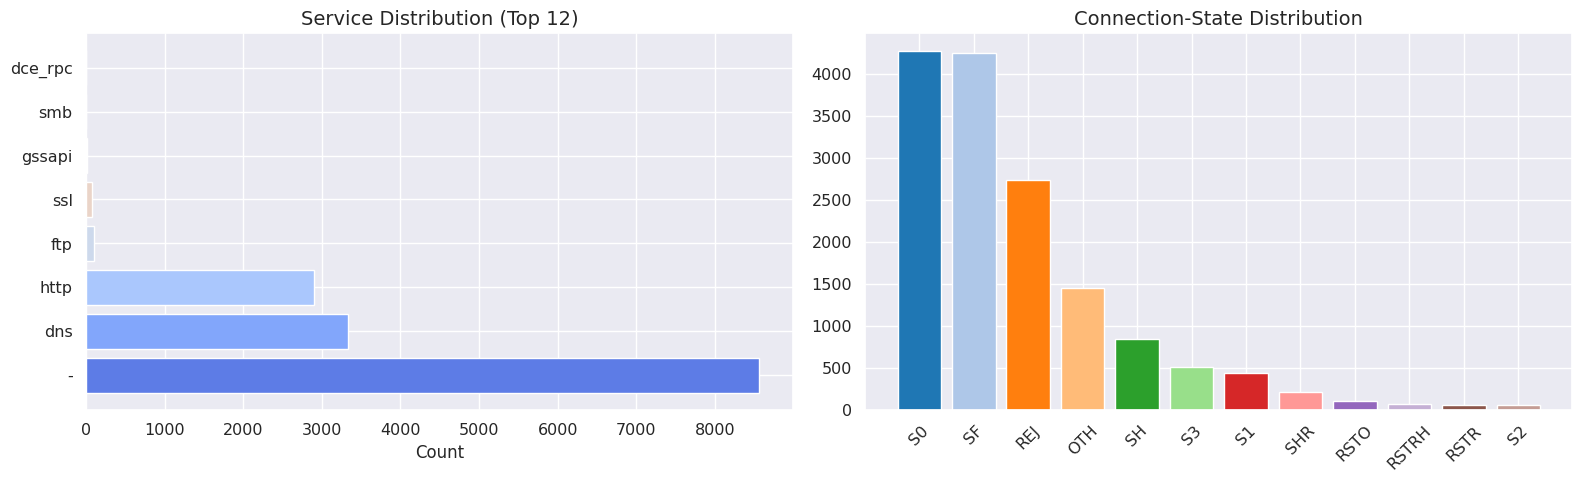

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

svc_vc = df_eda["service"].astype(str).value_counts().head(12)
axes[0].barh(
    svc_vc.index, svc_vc.values,
    color=sns.color_palette("coolwarm", len(svc_vc))
)
axes[0].set_title("Service Distribution (Top 12)")
axes[0].set_xlabel("Count")

if "conn_state" in df_eda.columns:
    state_vc = df_eda["conn_state"].astype(str).value_counts().head(12)
    axes[1].bar(
        state_vc.index, state_vc.values,
        color=sns.color_palette("tab20", len(state_vc))
    )
    axes[1].set_title("Connection-State Distribution")
    axes[1].tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()

### 6.3 Histograms & KDE – Key Numerical Features

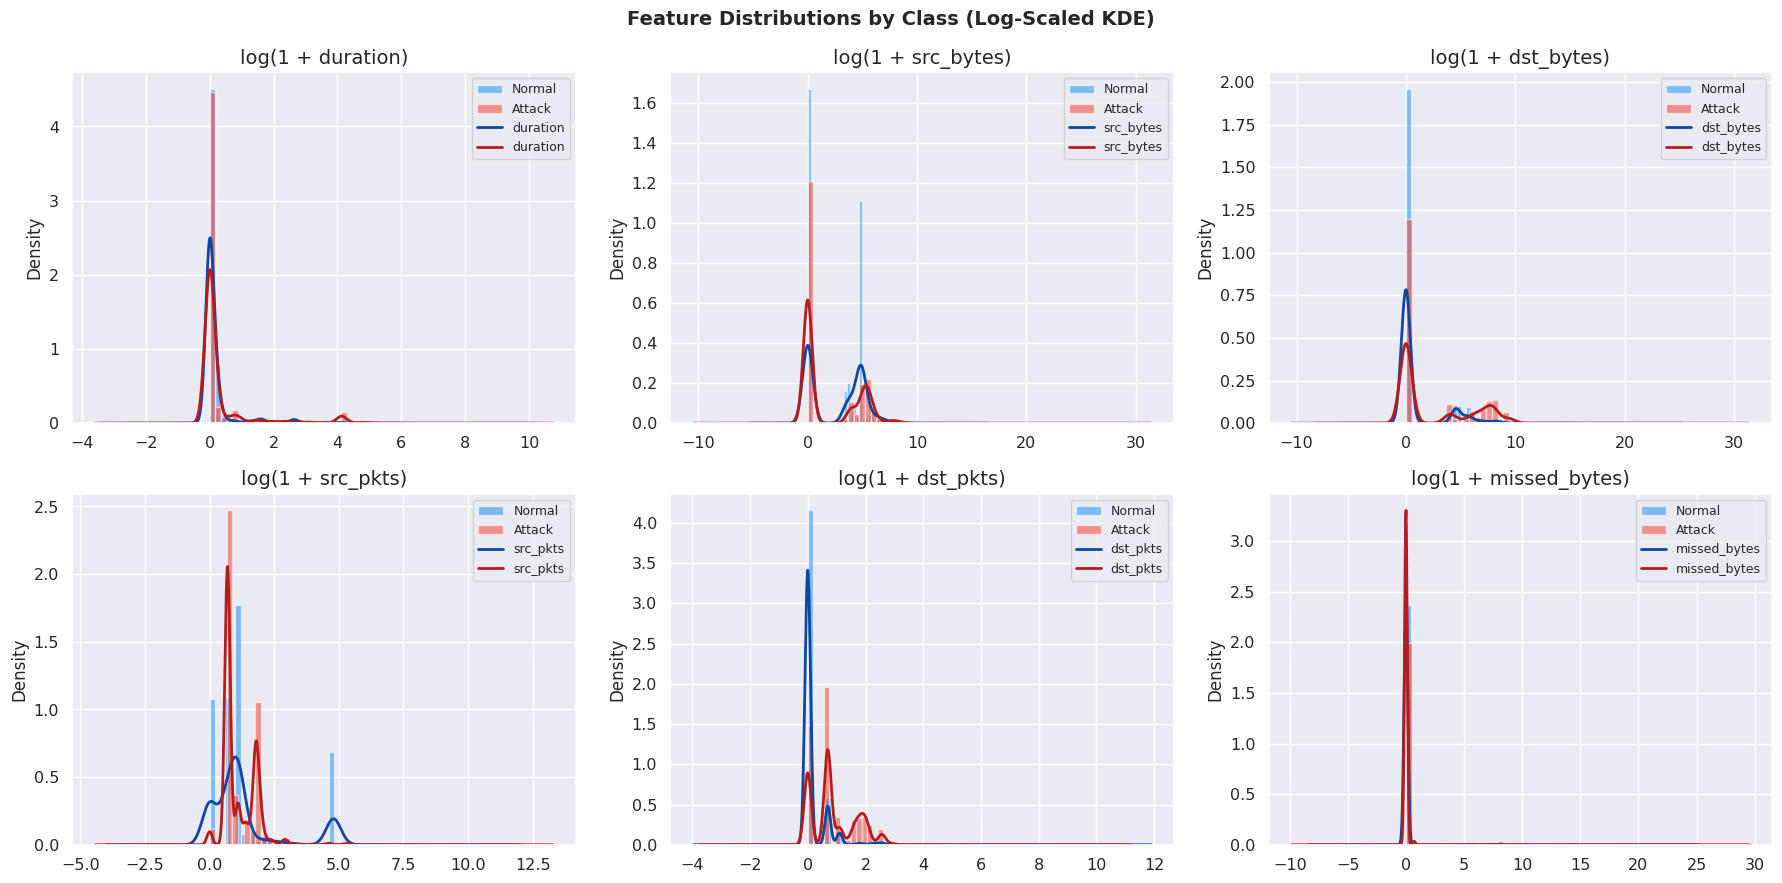

In [7]:
candidate_feats = [
    "duration", "src_bytes", "dst_bytes",
    "src_pkts", "dst_pkts", "missed_bytes"
]
key_feats = [f for f in candidate_feats if f in df_eda.columns]

fig, axes = plt.subplots(2, 3, figsize=(18, 9))
axes = np.asarray(axes).flatten()

for ax in axes:
    ax.axis("off")

for i, feat in enumerate(key_feats):
    ax = axes[i]
    ax.axis("on")

    data0 = pd.to_numeric(
        df_eda[df_eda[TARGET] == 0][feat], errors="coerce"
    ).dropna().clip(lower=0)

    data1 = pd.to_numeric(
        df_eda[df_eda[TARGET] == 1][feat], errors="coerce"
    ).dropna().clip(lower=0)

    data0_log = np.log1p(data0)
    data1_log = np.log1p(data1)

    ax.hist(data0_log, bins=40, alpha=0.55, label="Normal", color="#2196F3", density=True)
    ax.hist(data1_log, bins=40, alpha=0.55, label="Attack", color="#F44336", density=True)

    if len(data0_log) > 5 and np.std(data0_log) > 0:
        pd.Series(data0_log).plot.kde(ax=ax, color="#0D47A1", lw=2)
    if len(data1_log) > 5 and np.std(data1_log) > 0:
        pd.Series(data1_log).plot.kde(ax=ax, color="#B71C1C", lw=2)

    ax.set_title(f"log(1 + {feat})")
    ax.legend(fontsize=9)

plt.suptitle("Feature Distributions by Class (Log-Scaled KDE)", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.4 Boxplots & Violin Plots

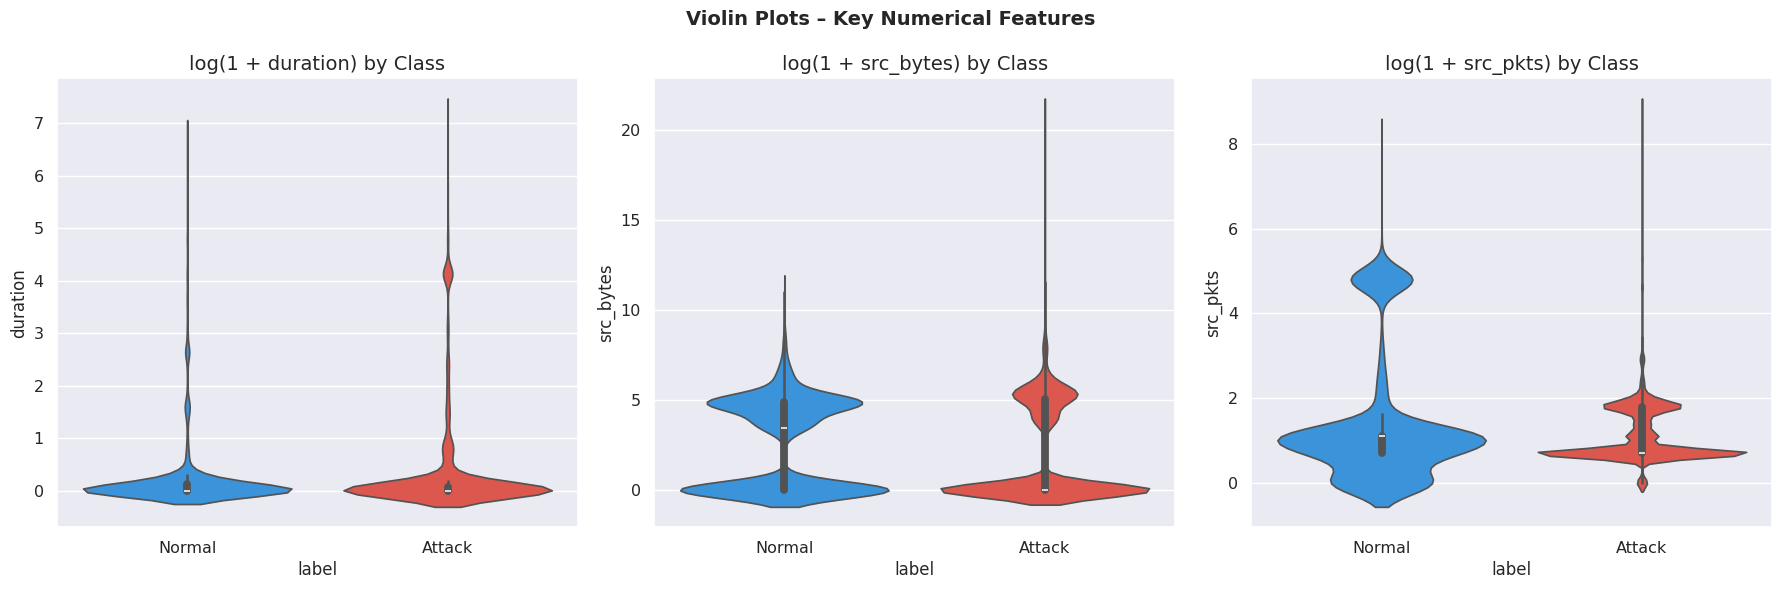

In [8]:
box_feats = [f for f in ["duration", "src_bytes", "src_pkts"] if f in df_eda.columns]

fig, axes = plt.subplots(
    1, max(1, len(box_feats)),
    figsize=(6 * max(1, len(box_feats)), 6)
)
if len(box_feats) == 1:
    axes = [axes]

for i, feat in enumerate(box_feats):
    temp = df_eda[[TARGET, feat]].copy()
    temp[feat] = np.log1p(
        pd.to_numeric(temp[feat], errors="coerce").clip(lower=0)
    )

    sns.violinplot(
        data=temp, x=TARGET, y=feat, ax=axes[i],
        palette=["#2196F3", "#F44336"], inner="box", cut=2
    )
    axes[i].set_title(f"log(1 + {feat}) by Class")
    axes[i].set_xticklabels(["Normal", "Attack"])

plt.suptitle("Violin Plots – Key Numerical Features", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### 6.5 PCA, t-SNE, and UMAP Dimensionality Reduction

We project a manageable subset into 2D using PCA, t-SNE and UMAP (if available), preserving the supplied notebook's dimensionality-reduction analysis.

Running t-SNE ...
Running UMAP ...


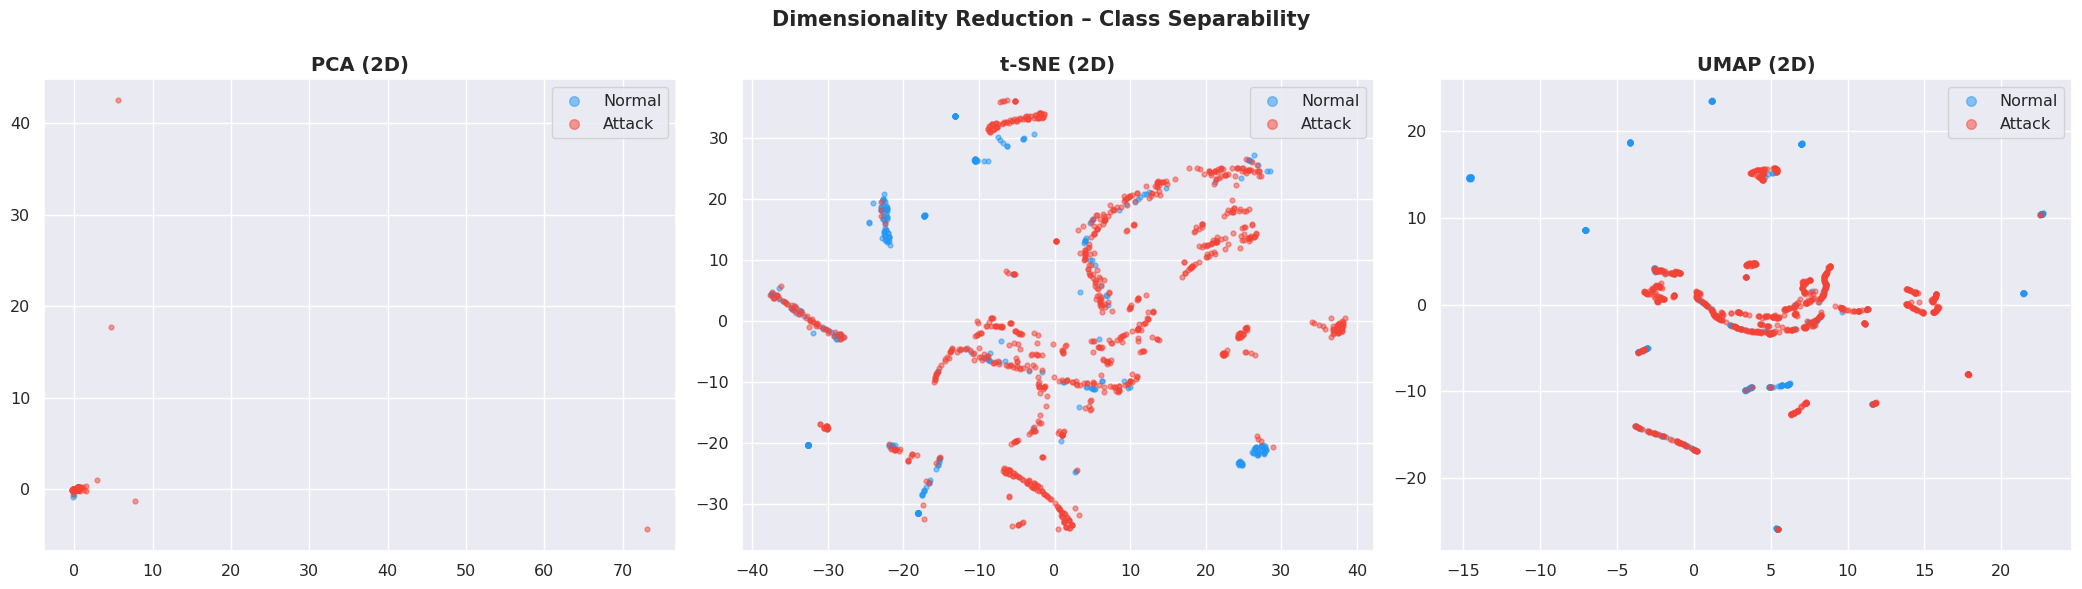

PCA explained variance (2 components): 42.6%


In [9]:
DIM_SAMPLE = 1200
df_dim = df_eda.sample(
    n=min(DIM_SAMPLE, len(df_eda)),
    random_state=CFG.SEED
)

NCOLS = SCHEMA["numeric_cols"]
X_dim = (
    df_dim[NCOLS]
    .apply(pd.to_numeric, errors="coerce")
    .replace([np.inf, -np.inf], np.nan)
    .fillna(0)
    .values
)
y_dim = df_dim[TARGET].values.astype(int)

scaler_dim = StandardScaler()
X_dim_sc = scaler_dim.fit_transform(X_dim)

pca = PCA(n_components=2, random_state=CFG.SEED)
X_pca = pca.fit_transform(X_dim_sc)

print("Running t-SNE ...")
try:
    tsne = TSNE(
        n_components=2, perplexity=30,
        random_state=CFG.SEED, max_iter=500,
        learning_rate="auto", init="pca"
    )
except TypeError:
    tsne = TSNE(
        n_components=2, perplexity=30,
        random_state=CFG.SEED, n_iter=500,
        learning_rate="auto", init="pca"
    )
X_tsne = tsne.fit_transform(X_dim_sc)

n_plots = 3 if UMAP_AVAILABLE else 2
fig, axes = plt.subplots(1, n_plots, figsize=(7*n_plots, 6))
if n_plots == 1:
    axes = [axes]

for ax, X_2d, title in zip(
    axes[:2], [X_pca, X_tsne], ["PCA (2D)", "t-SNE (2D)"]
):
    ax.scatter(
        X_2d[y_dim == 0, 0], X_2d[y_dim == 0, 1],
        s=12, alpha=0.5, c="#2196F3", label="Normal"
    )
    ax.scatter(
        X_2d[y_dim == 1, 0], X_2d[y_dim == 1, 1],
        s=12, alpha=0.5, c="#F44336", label="Attack"
    )
    ax.set_title(title, fontweight="bold")
    ax.legend(markerscale=2)

if UMAP_AVAILABLE:
    print("Running UMAP ...")
    reducer = umap.UMAP(
        n_components=2, random_state=CFG.SEED,
        n_neighbors=15, min_dist=0.1
    )
    X_umap = reducer.fit_transform(X_dim_sc)

    axes[2].scatter(
        X_umap[y_dim == 0, 0], X_umap[y_dim == 0, 1],
        s=12, alpha=0.5, c="#2196F3", label="Normal"
    )
    axes[2].scatter(
        X_umap[y_dim == 1, 0], X_umap[y_dim == 1, 1],
        s=12, alpha=0.5, c="#F44336", label="Attack"
    )
    axes[2].set_title("UMAP (2D)", fontweight="bold")
    axes[2].legend(markerscale=2)

plt.suptitle("Dimensionality Reduction – Class Separability", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.show()

print(f"PCA explained variance (2 components): {pca.explained_variance_ratio_.sum()*100:.1f}%")

### 6.6 Isolation Forest – Outlier Detection

Isolation Forest detected 60 outliers (5.0%) in the EDA subset.


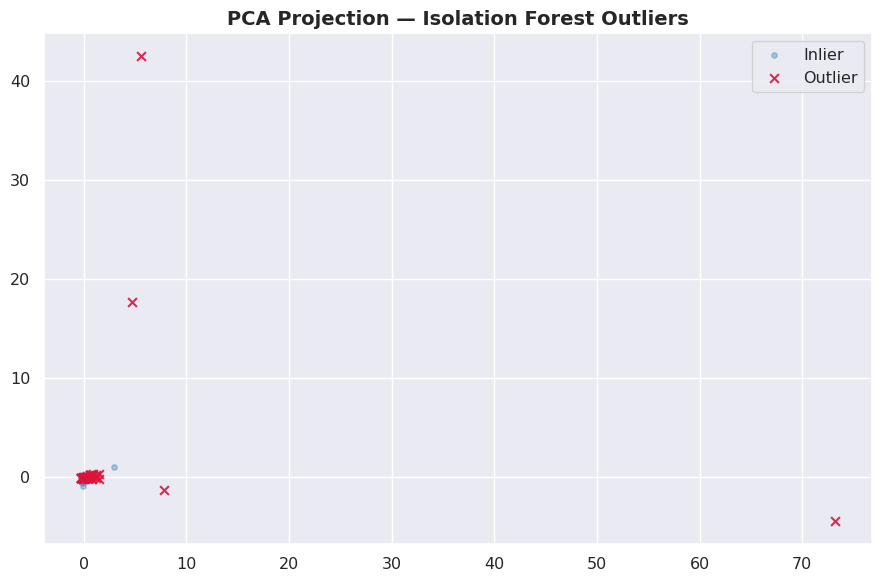

In [10]:
iso = IsolationForest(
    contamination=0.05,
    random_state=CFG.SEED,
    n_jobs=-1
)
outlier_labels = iso.fit_predict(X_dim_sc)
n_outliers = int(np.sum(outlier_labels == -1))

print(
    f"Isolation Forest detected {n_outliers} outliers "
    f"({n_outliers/len(outlier_labels)*100:.1f}%) in the EDA subset."
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(
    X_pca[outlier_labels == 1, 0],
    X_pca[outlier_labels == 1, 1],
    s=15, alpha=0.4, c="steelblue", label="Inlier"
)
ax.scatter(
    X_pca[outlier_labels == -1, 0],
    X_pca[outlier_labels == -1, 1],
    s=40, alpha=0.9, c="crimson", marker="x", label="Outlier"
)
ax.set_title("PCA Projection — Isolation Forest Outliers", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.show()

## 7. Statistical Analysis

A separate statistical-analysis section is retained as required by the project.

### 7.1 Descriptive Statistics

In [11]:
desc_cols = SCHEMA["numeric_cols"][:10]

desc = (
    df_train_raw[desc_cols]
    .apply(pd.to_numeric, errors="coerce")
    .describe()
    .T
)
desc["skewness"] = (
    df_train_raw[desc_cols]
    .apply(pd.to_numeric, errors="coerce")
    .skew()
)
desc["kurtosis"] = (
    df_train_raw[desc_cols]
    .apply(pd.to_numeric, errors="coerce")
    .kurtosis()
)
desc["cv"] = desc["std"] / (desc["mean"].abs() + 1e-9)

display(
    desc[["mean", "std", "min", "50%", "max", "skewness", "kurtosis", "cv"]]
)

,mean,std,min,50%,max,skewness,kurtosis,cv
src_port,39346.494588,1.853346e+04,1.0,44310.000000,6.552800e+04,-1.133588,0.131478,0.471032
dst_port,4070.069534,1.074020e+04,0.0,80.000000,6.546700e+04,3.766112,13.776733,2.638825
duration,5.924425,3.921178e+02,0.0,0.000164,9.351693e+04,210.022176,47265.171365,66.186636
src_bytes,379100.656710,2.071887e+07,0.0,0.000000,3.890855e+09,83.630608,10642.102592,54.652676
dst_bytes,379597.223567,2.184693e+07,0.0,0.000000,3.913853e+09,94.007894,12577.070276,57.552932
missed_bytes,50332.589265,6.377040e+06,0.0,0.000000,1.854527e+09,208.524991,53837.737525,126.698028
src_pkts,8.742581,1.076662e+02,0.0,1.000000,2.462300e+04,121.852129,22301.819227,12.315148
src_ip_bytes,808.355945,2.692371e+04,0.0,86.000000,6.522626e+06,138.157503,27044.932522,33.306753
dst_pkts,4.253715,3.857510e+02,0.0,1.000000,1.219420e+05,263.506823,76291.523818,90.685652
dst_ip_bytes,1917.438113,2.303102e+05,0.0,40.000000,8.639552e+07,367.810650,137843.261076,120.113518


### 7.2 Normality Testing (Kolmogorov–Smirnov)

The KS test compares each standardised empirical feature against a Normal distribution.

In [12]:
print(f"{'Feature':<28} {'KS Stat':>10} {'p-value':>12} {'Normal?':>10}")
print("-" * 65)

for feat in SCHEMA["numeric_cols"][:12]:
    sample = pd.to_numeric(
        df_eda[feat], errors="coerce"
    ).dropna().values

    if len(sample) < 20 or np.std(sample) == 0:
        print(f"{feat:<28} {'N/A':>10} {'N/A':>12} {'constant':>10}")
        continue

    z = (sample - sample.mean()) / (sample.std() + 1e-9)
    ks, pv = stats.kstest(z, "norm")
    normal = "✘ No" if pv < 0.05 else "✔ Yes"
    print(f"{feat:<28} {ks:>10.4f} {pv:>12.4e} {normal:>10}")

print("\nSmall p-values indicate non-Gaussian traffic variables,")
print("supporting non-parametric tests and tree-based models.")

Feature                         KS Stat      p-value    Normal?
-----------------------------------------------------------------
src_port                         0.1908   0.0000e+00       ✘ No
dst_port                         0.3533   0.0000e+00       ✘ No
duration                         0.4423   0.0000e+00       ✘ No
src_bytes                        0.5071   0.0000e+00       ✘ No
dst_bytes                        0.5055   0.0000e+00       ✘ No
missed_bytes                     0.5027   0.0000e+00       ✘ No
src_pkts                         0.4573   0.0000e+00       ✘ No
src_ip_bytes                     0.4852   0.0000e+00       ✘ No
dst_pkts                         0.4682   0.0000e+00       ✘ No
dst_ip_bytes                     0.4768   0.0000e+00       ✘ No
dns_qclass                       0.5292   0.0000e+00       ✘ No
dns_qtype                        0.4681   0.0000e+00       ✘ No

Small p-values indicate non-Gaussian traffic variables,
supporting non-parametric tests and tree-base

### 7.3 Mann–Whitney U Tests – Normal vs Attack

**Null hypothesis \(H_0\):** the feature distribution is the same in benign and attack traffic.  
**Alternative \(H_1\):** the distributions differ.

Rank-biserial effect size and Benjamini–Hochberg FDR-adjusted p-values are reported.

In [13]:
results_mw = []

for feat in SCHEMA["numeric_cols"]:
    g0 = pd.to_numeric(
        df_eda[df_eda[TARGET] == 0][feat], errors="coerce"
    ).dropna()

    g1 = pd.to_numeric(
        df_eda[df_eda[TARGET] == 1][feat], errors="coerce"
    ).dropna()

    if len(g0) > 10 and len(g1) > 10:
        u, p = stats.mannwhitneyu(g0, g1, alternative="two-sided")
        r = 1 - (2*u) / (len(g0)*len(g1))
        results_mw.append({
            "feature": feat,
            "U_stat": u,
            "p_value": p,
            "effect_size_r": abs(r),
            "significant_0.05": p < 0.05
        })

mw_df = pd.DataFrame(results_mw).sort_values(
    "effect_size_r", ascending=False
)

if len(mw_df):
    pvals = mw_df["p_value"].to_numpy()
    order = np.argsort(pvals)
    sorted_p = pvals[order]
    m = len(sorted_p)
    adj_sorted = np.minimum.accumulate(
        (sorted_p * m / np.arange(1, m+1))[::-1]
    )[::-1]
    adj_sorted = np.clip(adj_sorted, 0, 1)

    adjusted = np.empty_like(adj_sorted)
    adjusted[order] = adj_sorted
    mw_df["p_fdr_bh"] = adjusted

display(mw_df.head(20))

,feature,U_stat,p_value,effect_size_r,significant_0.05,p_fdr_bh
8,dst_pkts,9408385.5,0.000000e+00,0.570977,True,0.000000e+00
9,dst_ip_bytes,10646070.5,0.000000e+00,0.514539,True,0.000000e+00
11,dns_qtype,32973692.5,0.000000e+00,0.503602,True,0.000000e+00
10,dns_qclass,32536228.0,0.000000e+00,0.483654,True,0.000000e+00
0,src_port,16690862.0,6.997911e-111,0.238896,True,1.866110e-110
4,dst_bytes,16992833.0,8.696361e-143,0.225126,True,2.782835e-142
7,src_ip_bytes,24019789.5,3.923857e-19,0.095304,True,7.847714e-19
3,src_bytes,23907461.0,3.160249e-21,0.090181,True,7.223425e-21
2,duration,20463956.5,2.379617e-10,0.066843,True,3.172822e-10
1,dst_port,23084870.5,5.520197e-07,0.052671,True,6.308796e-07


### 7.4 Correlation Analysis

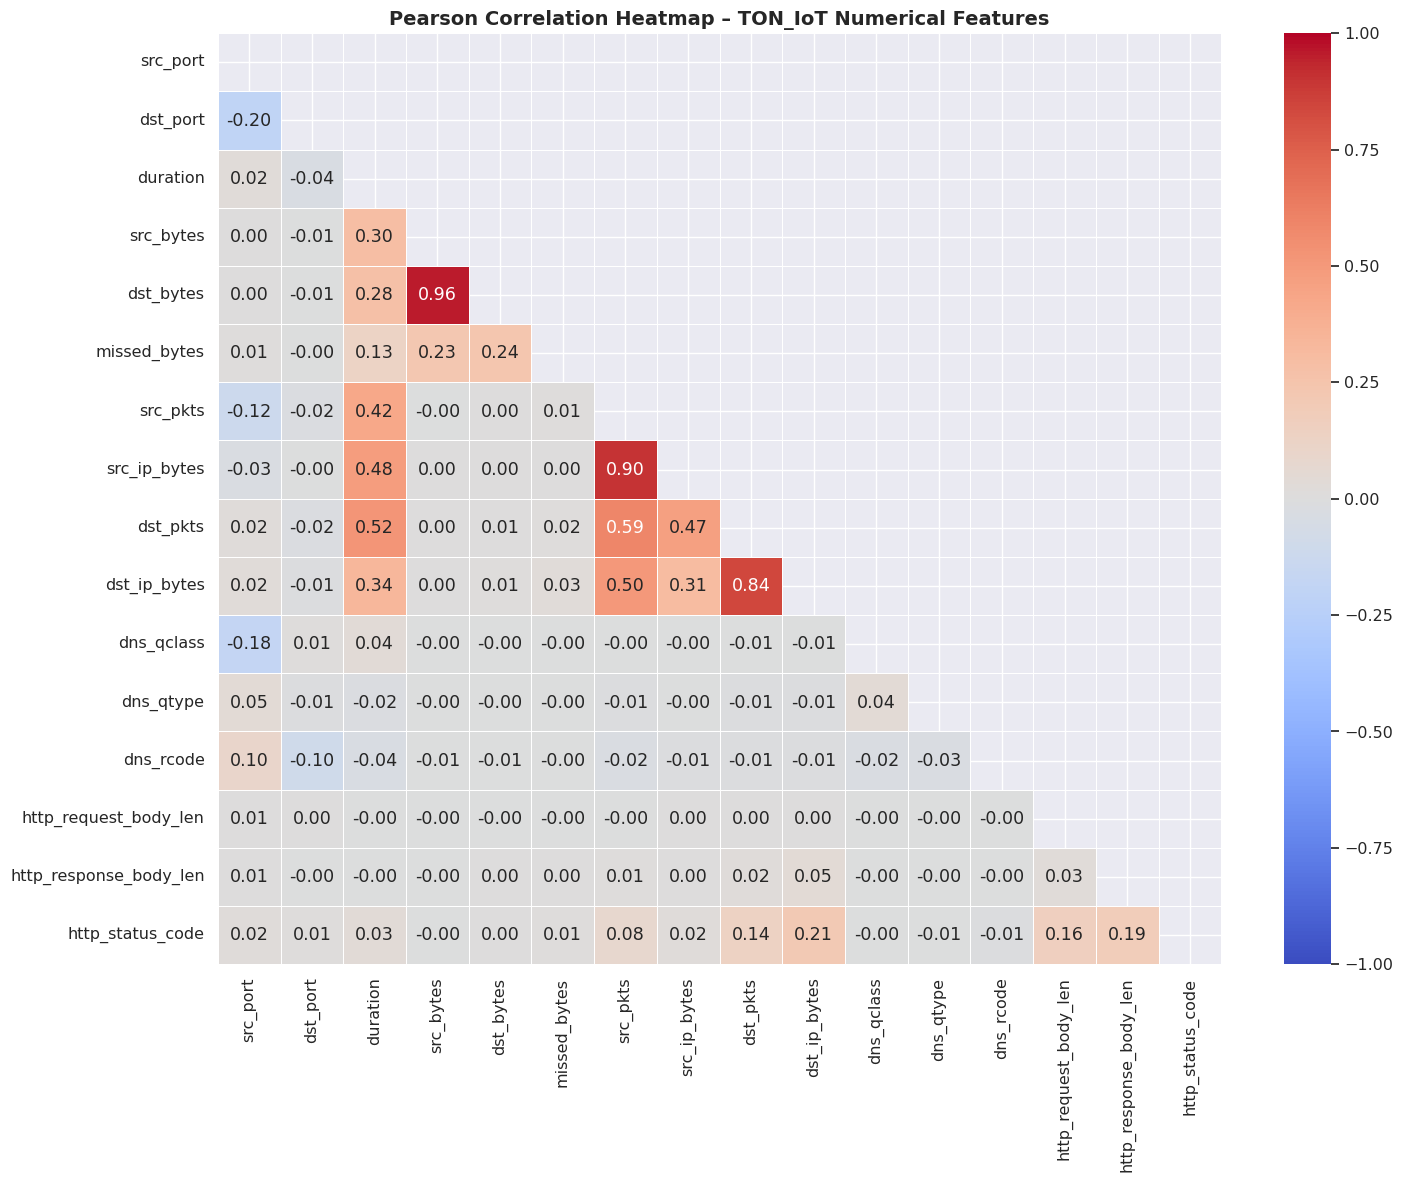

In [14]:
corr = (
    df_eda[SCHEMA["numeric_cols"]]
    .apply(pd.to_numeric, errors="coerce")
    .corr()
)
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(15, 12))
sns.heatmap(
    corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    linewidths=0.4,
    ax=ax,
    annot=len(SCHEMA["numeric_cols"]) < 20,
    fmt=".2f" if len(SCHEMA["numeric_cols"]) < 20 else ""
)
ax.set_title(
    "Pearson Correlation Heatmap – TON_IoT Numerical Features",
    fontsize=14, fontweight="bold"
)
plt.tight_layout()
plt.show()

### 7.5 Stationarity Analysis (ADF & KPSS)

The network CSV does not expose a true flow timestamp. Therefore the row order is treated only as an **ordered-flow pseudo-time-series**, not as exact elapsed time.

The following subsection also uses real `date` + `time` columns from an IoT telemetry file for genuine inter-arrival analysis.

  ORDERED-FLOW STATIONARITY TESTS
Series: duration | n=1500

ADF statistic: -38.7595
ADF p-value  : 0
ADF decision : STATIONARY

KPSS statistic: 0.4499
KPSS p-value  : 0.0556362
KPSS decision: STATIONARY


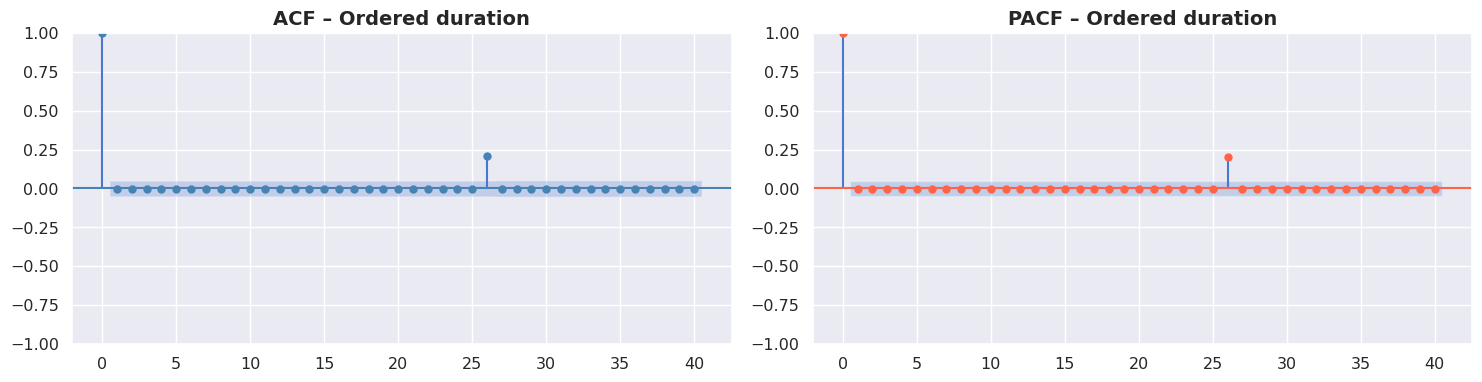

In [15]:
series_col = (
    "duration" if "duration" in df_train_raw.columns
    else SCHEMA["numeric_cols"][0]
)

series = (
    pd.to_numeric(
        df_train_raw.sort_values("_row_id")[series_col],
        errors="coerce"
    )
    .fillna(0)
    .values[:1500]
)

print("=" * 62)
print("  ORDERED-FLOW STATIONARITY TESTS")
print("=" * 62)
print(f"Series: {series_col} | n={len(series)}")

try:
    adf_stat, adf_p, _, _, _, _ = adfuller(series, autolag="AIC")
    print(f"\nADF statistic: {adf_stat:.4f}")
    print(f"ADF p-value  : {adf_p:.6g}")
    print(
        "ADF decision :",
        "STATIONARY" if adf_p < 0.05 else "NON-STATIONARY"
    )
except Exception as e:
    print("ADF test unavailable:", e)

try:
    kpss_stat, kpss_p, _, _ = kpss(
        series, regression="c", nlags="auto"
    )
    print(f"\nKPSS statistic: {kpss_stat:.4f}")
    print(f"KPSS p-value  : {kpss_p:.6g}")
    print(
        "KPSS decision:",
        "STATIONARY" if kpss_p > 0.05 else "NON-STATIONARY"
    )
except Exception as e:
    print("KPSS test unavailable:", e)

max_lags = min(40, max(5, len(series)//4 - 1))

fig, axes = plt.subplots(1, 2, figsize=(15, 4))
plot_acf(series, lags=max_lags, ax=axes[0], color="steelblue")
plot_pacf(
    series, lags=max_lags, ax=axes[1],
    color="tomato", method="ywm"
)
axes[0].set_title(f"ACF – Ordered {series_col}", fontweight="bold")
axes[1].set_title(f"PACF – Ordered {series_col}", fontweight="bold")
plt.tight_layout()
plt.show()

### 7.6 Real Timestamp / Inter-Arrival Analysis from TON_IoT IoT Telemetry

Telemetry source: /kaggle/input/datasets/asfarhossainsitab/ton-iot/Train_Test_datasets/Train_Test_IoT_dataset/Train_Test_IoT_Weather.csv
Valid timestamps: 39,260
Inter-arrivals  : 39,259
count    3.925900e+04
mean     6.174271e+01
std      1.019763e+04
min      0.000000e+00
50%      0.000000e+00
90%      4.000000e+00
95%      5.000000e+00
99%      1.000000e+01
max      2.014567e+06


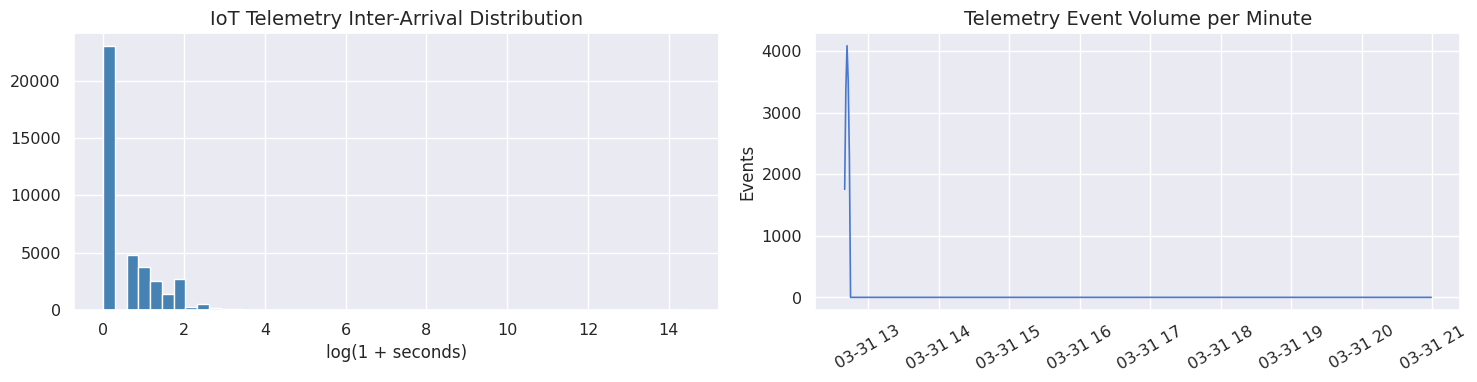

In [16]:
def load_one_iot_telemetry():
    """Load one IoT telemetry CSV with date/time columns."""
    candidates = inventory[
        (inventory["domain"] == "IoT telemetry") &
        (
            inventory["name"].str.contains(
                "Weather|Fridge|Thermostat",
                case=False, regex=True
            )
        )
    ]

    if candidates.empty:
        candidates = inventory[
            inventory["domain"] == "IoT telemetry"
        ]

    if candidates.empty:
        return None, None

    row = candidates.iloc[0]

    if row["source"] == "filesystem":
        return pd.read_csv(row["path"]), row["path"]

    if row["source"] == "zip" and os.path.exists(CFG.LOCAL_ZIP):
        with zipfile.ZipFile(CFG.LOCAL_ZIP) as zf:
            with zf.open(row["path"]) as f:
                return pd.read_csv(f), f"{CFG.LOCAL_ZIP}::{row['path']}"

    return None, None

iot_time_df, iot_time_source = load_one_iot_telemetry()

if (
    iot_time_df is None
    or not {"date", "time"}.issubset(iot_time_df.columns)
):
    print("⚠ No IoT telemetry file with date/time available.")
else:
    ts = pd.to_datetime(
        iot_time_df["date"].astype(str) + " " +
        iot_time_df["time"].astype(str),
        errors="coerce"
    ).dropna().sort_values()

    inter = ts.diff().dt.total_seconds().dropna()
    inter = inter[(inter >= 0) & np.isfinite(inter)]

    print("Telemetry source:", iot_time_source)
    print(f"Valid timestamps: {len(ts):,}")
    print(f"Inter-arrivals  : {len(inter):,}")
    print(inter.describe(
        percentiles=[0.5, 0.9, 0.95, 0.99]
    ).to_string())

    fig, axes = plt.subplots(1, 2, figsize=(15, 4))

    axes[0].hist(
        np.log1p(inter.clip(lower=0)),
        bins=50,
        color="steelblue",
        edgecolor="white"
    )
    axes[0].set_title("IoT Telemetry Inter-Arrival Distribution")
    axes[0].set_xlabel("log(1 + seconds)")

    temp = pd.DataFrame({"timestamp": ts})
    volume = temp.set_index("timestamp").resample("1min").size()

    axes[1].plot(
        volume.index[:500],
        volume.values[:500],
        lw=1.2
    )
    axes[1].set_title("Telemetry Event Volume per Minute")
    axes[1].set_ylabel("Events")
    axes[1].tick_params(axis="x", rotation=30)

    plt.tight_layout()
    plt.show()

## 8. Data Cleaning

A structured pipeline is used:

1. Preserve graph identifiers and split metadata.
2. Convert non-finite numeric values to missing.
3. Impute numeric missing values with **training medians**.
4. Replace placeholder categorical values such as `-` with `missing`.
5. Drop exact duplicate observations within each partition.

In [17]:
def fit_cleaning_statistics(df_train, schema):
    numeric_medians = {}
    categorical_modes = {}

    for col in schema["numeric_cols"]:
        s = (
            pd.to_numeric(df_train[col], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
        )
        numeric_medians[col] = (
            float(s.median()) if s.notna().any() else 0.0
        )

    cat_candidates = [
        c for c in df_train.select_dtypes(exclude=[np.number]).columns
        if c not in [schema["multiclass_target"], "_pair_key"]
    ]

    for col in cat_candidates:
        s = (
            df_train[col].astype(str)
            .replace({
                "-": np.nan,
                "": np.nan,
                "nan": np.nan
            })
        )
        mode = s.mode(dropna=True)
        categorical_modes[col] = (
            str(mode.iloc[0]) if len(mode) else "missing"
        )

    return numeric_medians, categorical_modes

NUM_MEDIANS, CAT_MODES = fit_cleaning_statistics(
    df_train_raw, SCHEMA
)

def clean_dataframe(
    df, schema,
    numeric_medians,
    categorical_modes
):
    df = df.copy()

    for col in schema["numeric_cols"]:
        df[col] = (
            pd.to_numeric(df[col], errors="coerce")
            .replace([np.inf, -np.inf], np.nan)
            .fillna(numeric_medians.get(col, 0.0))
        )

    for col, mode in categorical_modes.items():
        if col in df.columns:
            df[col] = (
                df[col].astype(str)
                .replace({
                    "-": "missing",
                    "": "missing",
                    "nan": "missing"
                })
                .fillna(mode)
            )

    dup_subset = [
        c for c in df.columns
        if c not in ["_row_id", "_split_bucket", "_pair_key"]
    ]

    before = len(df)
    df = df.drop_duplicates(subset=dup_subset).copy()
    print(f"Dropped {before-len(df):,} exact duplicate rows.")

    return (
        df.sort_values("_row_id")
        .reset_index(drop=True)
    )

df_train_clean = clean_dataframe(
    df_train_raw, SCHEMA,
    NUM_MEDIANS, CAT_MODES
)
df_test_clean = clean_dataframe(
    df_test_raw, SCHEMA,
    NUM_MEDIANS, CAT_MODES
)

print(f"✅ Cleaned train: {df_train_clean.shape}")
print(f"✅ Cleaned test : {df_test_clean.shape}")

Dropped 14,614 exact duplicate rows.
Dropped 5,955 exact duplicate rows.
✅ Cleaned train: (129043, 47)
✅ Cleaned test : (61431, 47)


## 9. Feature Engineering

The sample notebook's ratio, rolling and frequency features are retained and translated to TON_IoT names. Additional **connection-topology features** are added because graph connectivity is the main project focus.

| Feature | Description |
|---|---|
| `bytes_ratio` | `src_bytes / (dst_bytes + 1)` |
| `pkts_ratio` | `src_pkts / (dst_pkts + 1)` |
| `total_bytes` | source + destination bytes |
| `total_pkts` | source + destination packets |
| `bytes_per_sec` | total bytes / duration |
| `pkts_per_sec` | total packets / duration |
| `rolling_mean_duration` | 3-flow ordered rolling mean |
| `rolling_std_duration` | 3-flow ordered rolling SD |
| `rolling_mean_bytes` | 5-flow ordered rolling mean |
| `proto_freq`, `conn_state_freq`, `service_freq` | train-frequency encodings |
| `src_out_flow_count` | training source flow count |
| `dst_in_flow_count` | training destination flow count |
| `pair_train_count` | count of that directed train connection |
| `src_unique_dsts` | source fan-out |
| `dst_unique_srcs` | destination fan-in |

No label-derived statistic is used as a model feature.

In [18]:
def engineer_flow_features(df):
    df = df.copy()

    if {"src_bytes", "dst_bytes"}.issubset(df.columns):
        df["bytes_ratio"] = (
            df["src_bytes"] / (df["dst_bytes"] + 1.0)
        )
        df["total_bytes"] = (
            df["src_bytes"] + df["dst_bytes"]
        )

    if {"src_pkts", "dst_pkts"}.issubset(df.columns):
        df["pkts_ratio"] = (
            df["src_pkts"] / (df["dst_pkts"] + 1.0)
        )
        df["total_pkts"] = (
            df["src_pkts"] + df["dst_pkts"]
        )

    if "duration" in df.columns:
        dur = df["duration"].clip(lower=0) + 1e-6

        if "total_bytes" in df.columns:
            df["bytes_per_sec"] = (
                df["total_bytes"] / dur
            )

        if "total_pkts" in df.columns:
            df["pkts_per_sec"] = (
                df["total_pkts"] / dur
            )

        df["rolling_mean_duration"] = (
            df["duration"]
            .rolling(3, min_periods=1)
            .mean()
        )

        df["rolling_std_duration"] = (
            df["duration"]
            .rolling(3, min_periods=1)
            .std()
            .fillna(0)
        )

        df["ema_duration"] = (
            df["duration"]
            .ewm(span=5, adjust=False)
            .mean()
        )

    if "total_bytes" in df.columns:
        df["rolling_mean_bytes"] = (
            df["total_bytes"]
            .rolling(5, min_periods=1)
            .mean()
        )

        df["rolling_std_bytes"] = (
            df["total_bytes"]
            .rolling(5, min_periods=1)
            .std()
            .fillna(0)
        )

    if "src_port" in df.columns:
        df["src_well_known_port"] = (
            df["src_port"].between(0, 1023)
        ).astype(int)

    if "dst_port" in df.columns:
        df["dst_well_known_port"] = (
            df["dst_port"].between(0, 1023)
        ).astype(int)

    return df

df_train_eng = engineer_flow_features(df_train_clean)
df_test_eng = engineer_flow_features(df_test_clean)

# Train-derived category frequency encodings
for col in ["proto", "conn_state", "service"]:
    if col in df_train_eng.columns:
        freq = (
            df_train_eng[col]
            .astype(str)
            .value_counts(normalize=True)
        )

        df_train_eng[f"{col}_freq"] = (
            df_train_eng[col]
            .astype(str)
            .map(freq)
            .fillna(0)
        )

        df_test_eng[f"{col}_freq"] = (
            df_test_eng[col]
            .astype(str)
            .map(freq)
            .fillna(0)
        )

# Train-only connection statistics
src_count = df_train_eng.groupby("src_ip").size()
dst_count = df_train_eng.groupby("dst_ip").size()
pair_count = df_train_eng.groupby(
    ["src_ip", "dst_ip"]
).size()
src_unique_dsts = df_train_eng.groupby(
    "src_ip"
)["dst_ip"].nunique()
dst_unique_srcs = df_train_eng.groupby(
    "dst_ip"
)["src_ip"].nunique()

def apply_connection_features(df):
    out = df.copy()

    out["src_out_flow_count"] = (
        out["src_ip"]
        .map(src_count)
        .fillna(0)
        .astype(float)
    )

    out["dst_in_flow_count"] = (
        out["dst_ip"]
        .map(dst_count)
        .fillna(0)
        .astype(float)
    )

    out["src_unique_dsts"] = (
        out["src_ip"]
        .map(src_unique_dsts)
        .fillna(0)
        .astype(float)
    )

    out["dst_unique_srcs"] = (
        out["dst_ip"]
        .map(dst_unique_srcs)
        .fillna(0)
        .astype(float)
    )

    pair_index = pd.MultiIndex.from_arrays(
        [out["src_ip"], out["dst_ip"]]
    )

    out["pair_train_count"] = (
        pair_count
        .reindex(pair_index, fill_value=0)
        .to_numpy(dtype=float)
    )

    return out

df_train_eng = apply_connection_features(df_train_eng)
df_test_eng = apply_connection_features(df_test_eng)

new_feats = [
    c for c in df_train_eng.columns
    if c not in df_train_clean.columns
]

print(f"✅ {len(new_feats)} engineered features:")
print(new_feats)

✅ 21 engineered features:
['bytes_ratio', 'total_bytes', 'pkts_ratio', 'total_pkts', 'bytes_per_sec', 'pkts_per_sec', 'rolling_mean_duration', 'rolling_std_duration', 'ema_duration', 'rolling_mean_bytes', 'rolling_std_bytes', 'src_well_known_port', 'dst_well_known_port', 'proto_freq', 'conn_state_freq', 'service_freq', 'src_out_flow_count', 'dst_in_flow_count', 'src_unique_dsts', 'dst_unique_srcs', 'pair_train_count']


## 10. Data Encoding

Categorical traffic variables are label-encoded using mappings learned on the training set. Unknown test categories map to `-1`.

Raw `src_ip`, `dst_ip`, `type` and `_pair_key` are intentionally protected from ordinary encoding because they are graph/reporting identifiers.

In [19]:
encoders = {}

def encode_dataframes(df_tr, df_te, schema):
    df_tr = df_tr.copy()
    df_te = df_te.copy()
    enc_dict = {}

    protected = {
        schema["multiclass_target"],
        schema["src_col"],
        schema["dst_col"],
        "_pair_key"
    }

    cat_features = [
        c for c in df_tr.select_dtypes(
            exclude=[np.number]
        ).columns
        if c not in protected
    ]

    for col in cat_features:
        le = LabelEncoder()

        train_s = df_tr[col].astype(str)
        test_s = df_te[col].astype(str)

        df_tr[col] = le.fit_transform(train_s)

        mapping = dict(
            zip(
                le.classes_,
                le.transform(le.classes_)
            )
        )

        df_te[col] = (
            test_s
            .map(mapping)
            .fillna(-1)
            .astype(int)
        )

        enc_dict[col] = le

    return df_tr, df_te, enc_dict

df_train_enc, df_test_enc, encoders = (
    encode_dataframes(
        df_train_eng,
        df_test_eng,
        SCHEMA
    )
)

print("✅ Encoding complete.")
print("Encoded predictor columns:")
print(list(encoders.keys()))

✅ Encoding complete.
Encoded predictor columns:
['proto', 'service', 'conn_state', 'dns_query', 'dns_AA', 'dns_RD', 'dns_RA', 'dns_rejected', 'ssl_version', 'ssl_cipher', 'ssl_resumed', 'ssl_established', 'ssl_subject', 'ssl_issuer', 'http_trans_depth', 'http_method', 'http_uri', 'http_version', 'http_user_agent', 'http_orig_mime_types', 'http_resp_mime_types', 'weird_name', 'weird_addl', 'weird_notice']


## 11. Feature Scaling

`MinMaxScaler` is fitted only on the training partition and applied to the held-out connection-disjoint test partition.

In [20]:
def get_feature_columns(df, schema):
    exclude = {
        schema["binary_target"],
        schema["multiclass_target"],
        schema["src_col"],
        schema["dst_col"],
        "_row_id",
        "_pair_key",
        "_split_bucket"
    }

    return [
        c for c in df.columns
        if c not in exclude
        and pd.api.types.is_numeric_dtype(df[c])
    ]

FEAT_COLS = get_feature_columns(
    df_train_enc, SCHEMA
)

for col in FEAT_COLS:
    df_train_enc[col] = (
        pd.to_numeric(
            df_train_enc[col],
            errors="coerce"
        )
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

    df_test_enc[col] = (
        pd.to_numeric(
            df_test_enc[col],
            errors="coerce"
        )
        .replace([np.inf, -np.inf], np.nan)
        .fillna(0)
    )

scaler = MinMaxScaler()

df_train_enc[FEAT_COLS] = (
    scaler.fit_transform(
        df_train_enc[FEAT_COLS]
    )
)

df_test_enc[FEAT_COLS] = (
    scaler.transform(
        df_test_enc[FEAT_COLS]
    )
)

print(
    f"✅ Scaling applied to "
    f"{len(FEAT_COLS)} predictor columns."
)

✅ Scaling applied to 61 predictor columns.


## 12. Class Imbalance Analysis

Balanced class weights are computed from the training partition. No synthetic rows are created, so graph topology is not distorted.

Class Imbalance Summary:
  Normal (0): 30,219 (23.42%)
  Attack (1): 98,824 (76.58%)
Class weights: {np.int64(1): 0.6528930219379908, np.int64(0): 2.1351302160892156}


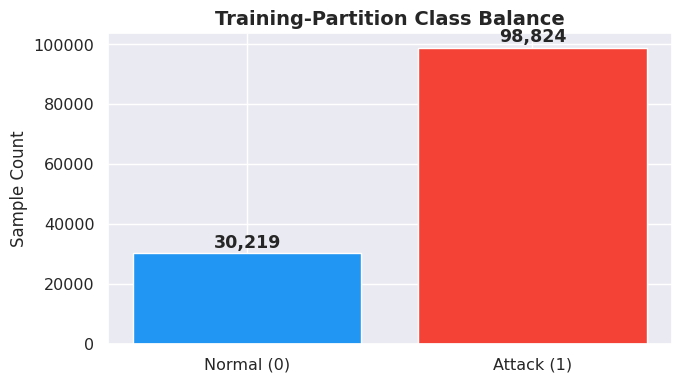

In [21]:
y_full = df_train_enc[TARGET].values.astype(int)
counts = Counter(y_full)
n_total = len(y_full)

class_weight_dict = {
    cls: n_total / (len(counts) * cnt)
    for cls, cnt in counts.items()
}

print("Class Imbalance Summary:")
for cls in sorted(counts):
    label_name = "Normal" if cls == 0 else "Attack"
    print(
        f"  {label_name} ({cls}): "
        f"{counts[cls]:,} "
        f"({counts[cls]/n_total*100:.2f}%)"
    )

print("Class weights:", class_weight_dict)

fig, ax = plt.subplots(figsize=(7, 4))
vals = [counts.get(0, 0), counts.get(1, 0)]

bars = ax.bar(
    ["Normal (0)", "Attack (1)"],
    vals,
    color=["#2196F3", "#F44336"]
)

ax.set_title(
    "Training-Partition Class Balance",
    fontweight="bold"
)
ax.set_ylabel("Sample Count")

for bar, cnt in zip(bars, vals):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + max(vals)*0.02,
        f"{cnt:,}",
        ha="center",
        fontweight="bold"
    )

plt.tight_layout()
plt.show()

## 13. Correlation Analysis

Pairwise correlations are computed after encoding/scaling. Features with absolute correlation above `0.95` are removed to reduce redundancy.

A quick Random Forest importance analysis is also retained from the supplied sample notebook.

Features removed (|r| > 0.95): 10
['dns_RA', 'dns_rejected', 'ssl_resumed', 'ssl_established', 'http_method', 'http_version', 'http_status_code', 'total_pkts', 'rolling_std_duration', 'proto_freq']
Remaining predictors: 51


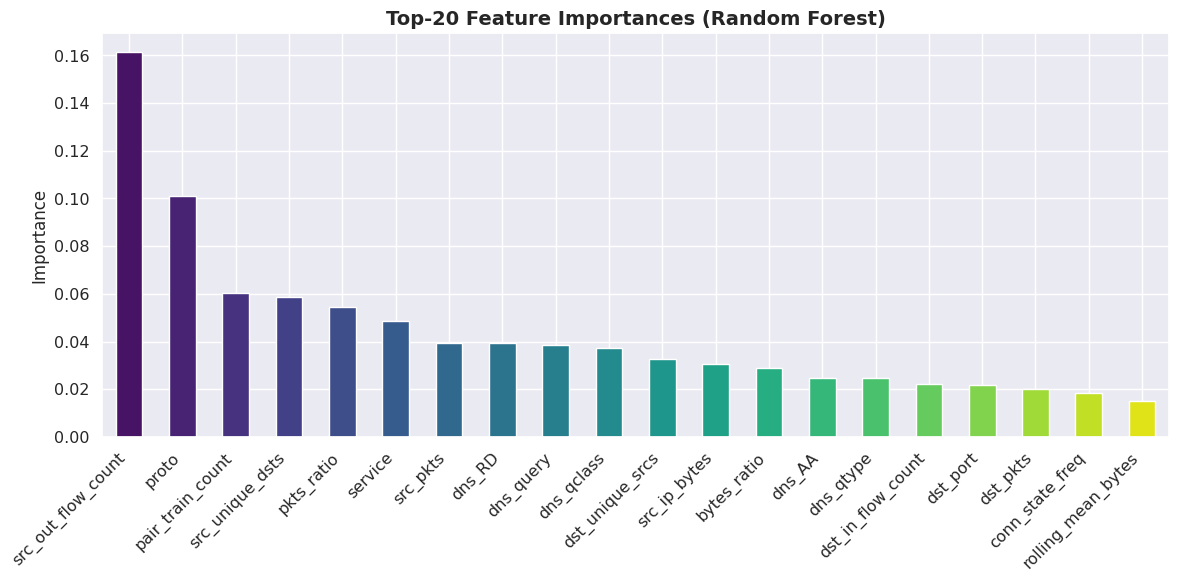

,importance
src_out_flow_count,0.161257
proto,0.101211
pair_train_count,0.060223
src_unique_dsts,0.058652
pkts_ratio,0.054403
service,0.048606
src_pkts,0.039534
dns_RD,0.039193
dns_query,0.038384
dns_qclass,0.037412


In [22]:
corr_mat = df_train_enc[FEAT_COLS].corr().abs()

upper_tri = corr_mat.where(
    np.triu(
        np.ones(corr_mat.shape),
        k=1
    ).astype(bool)
)

HIGH_CORR = [
    col for col in upper_tri.columns
    if any(
        upper_tri[col] > CFG.CORR_THRESHOLD
    )
]

FEAT_COLS_FINAL = [
    c for c in FEAT_COLS
    if c not in HIGH_CORR
]

print(
    f"Features removed "
    f"(|r| > {CFG.CORR_THRESHOLD}): "
    f"{len(HIGH_CORR)}"
)
print(HIGH_CORR)

print(
    f"Remaining predictors: "
    f"{len(FEAT_COLS_FINAL)}"
)

rf_imp = RandomForestClassifier(
    n_estimators=60,
    max_depth=8,
    random_state=CFG.SEED,
    n_jobs=-1,
    class_weight=class_weight_dict
)

rng = np.random.default_rng(CFG.SEED)

sample_idx = rng.choice(
    len(df_train_enc),
    size=min(6000, len(df_train_enc)),
    replace=False
)

rf_imp.fit(
    df_train_enc[FEAT_COLS_FINAL]
    .values[sample_idx],
    df_train_enc[TARGET]
    .values[sample_idx]
)

imp_df = pd.Series(
    rf_imp.feature_importances_,
    index=FEAT_COLS_FINAL
).sort_values(
    ascending=False
)

fig, ax = plt.subplots(
    figsize=(12, 6)
)

imp_df.head(20).plot.bar(
    ax=ax,
    color=sns.color_palette(
        "viridis",
        min(20, len(imp_df))
    )
)

ax.set_title(
    "Top-20 Feature Importances "
    "(Random Forest)",
    fontweight="bold"
)
ax.set_ylabel("Importance")
ax.set_xticklabels(
    ax.get_xticklabels(),
    rotation=45,
    ha="right"
)

plt.tight_layout()
plt.show()

display(
    imp_df.head(25)
    .rename("importance")
    .to_frame()
)

## 14. Stationarity Analysis — Engineered Rolling Features

The supplied notebook checks whether engineered rolling variables remain statistically stable. We apply the same diagnostic to TON_IoT duration and byte-volume rolling variables.

In [23]:
for col in [
    "rolling_mean_duration",
    "rolling_mean_bytes",
    "ema_duration"
]:
    if col not in df_train_enc.columns:
        continue

    s = (
        pd.to_numeric(
            df_train_enc
            .sort_values("_row_id")[col],
            errors="coerce"
        )
        .dropna()
        .values[:1000]
    )

    if len(s) < 30 or np.std(s) == 0:
        print(
            f"{col}: insufficient variation "
            "for ADF"
        )
        continue

    try:
        adf_s, adf_p_s, *_ = adfuller(s)
        status = (
            "STATIONARY"
            if adf_p_s < 0.05
            else "NON-STATIONARY"
        )
        print(
            f"ADF on '{col}': "
            f"stat={adf_s:.4f}, "
            f"p={adf_p_s:.6g} "
            f"→ {status}"
        )
    except Exception as e:
        print(
            f"ADF failed for {col}: {e}"
        )

ADF on 'rolling_mean_duration': stat=-5.2792, p=6.04625e-06 → STATIONARY
ADF on 'rolling_mean_bytes': stat=-4.5533, p=0.000157324 → STATIONARY
ADF on 'ema_duration': stat=-14.2249, p=1.63374e-26 → STATIONARY


## 15. Time-Series Preparation

As in the supplied notebook, ordered flows are converted into overlapping sliding-window sequences.

Because the network file has no explicit flow timestamp, these are **ordered-flow sequences**, not fixed-duration time windows.

In [24]:
def create_sequences(
    X,
    y,
    window=5
):
    """Create overlapping ordered-flow sequences."""
    X_seq = []
    y_seq = []

    for i in range(
        len(X) - window + 1
    ):
        X_seq.append(
            X[i:i+window]
        )
        y_seq.append(
            y[i+window-1]
        )

    return (
        np.asarray(
            X_seq,
            dtype=np.float32
        ),
        np.asarray(
            y_seq,
            dtype=np.float32
        )
    )

# Sample first, then restore original order
dl_tr = (
    df_train_enc
    .sample(
        n=min(
            CFG.DL_TRAIN,
            len(df_train_enc)
        ),
        random_state=CFG.SEED
    )
    .sort_values("_row_id")
)

dl_te = (
    df_test_enc
    .sample(
        n=min(
            CFG.DL_TEST,
            len(df_test_enc)
        ),
        random_state=CFG.SEED + 1
    )
    .sort_values("_row_id")
)

X_dl_tr = (
    dl_tr[FEAT_COLS_FINAL]
    .values.astype(np.float32)
)
y_dl_tr = (
    dl_tr[TARGET]
    .values.astype(np.float32)
)

X_dl_te = (
    dl_te[FEAT_COLS_FINAL]
    .values.astype(np.float32)
)
y_dl_te = (
    dl_te[TARGET]
    .values.astype(np.float32)
)

X_seq_tr, y_seq_tr = (
    create_sequences(
        X_dl_tr,
        y_dl_tr,
        CFG.WINDOW_SIZE
    )
)

X_seq_te, y_seq_te = (
    create_sequences(
        X_dl_te,
        y_dl_te,
        CFG.WINDOW_SIZE
    )
)

N_FEATURES = X_seq_tr.shape[2]

print(
    f"✅ Sequential train: "
    f"{X_seq_tr.shape} "
    f"→ labels {y_seq_tr.shape}"
)
print(
    f"✅ Sequential test : "
    f"{X_seq_te.shape} "
    f"→ labels {y_seq_te.shape}"
)
print(
    f"Input feature dim: "
    f"{N_FEATURES}"
)

✅ Sequential train: (5996, 5, 51) → labels (5996,)
✅ Sequential test : (1996, 5, 51) → labels (1996,)
Input feature dim: 51


## 16. Graph Construction

### 16.1 Main TON_IoT Communication Graph

This is the primary Track-B representation:

\[
G=(V,E)
\]

- \(V\): unique IP hosts
- \(E\): directed `src_ip → dst_ip` flows
- \(X_v\): label-free host communication features
- \(X_e\): selected flow-level edge features
- \(y_e\): binary intrusion label

Three separate graphs are used:
- GNN fit graph: buckets 0–5
- GNN validation graph: bucket 6
- GNN test graph: buckets 7–9

Thus, no directed source-destination pair appears in more than one graph partition.

In [25]:
# Shared evaluation subsets:
# Classical ML and GNN use the SAME held-out test rows.
eval_train_df = (
    df_train_enc
    .sample(
        n=min(
            CFG.TRAIN_SAMPLE,
            len(df_train_enc)
        ),
        random_state=CFG.SEED
    )
    .copy()
)

eval_test_df = (
    df_test_enc
    .sample(
        n=min(
            CFG.TEST_SAMPLE,
            len(df_test_enc)
        ),
        random_state=CFG.SEED + 2
    )
    .copy()
)

gnn_fit_pool = (
    df_train_enc[
        df_train_enc[
            "_split_bucket"
        ].isin(
            CFG.TUNE_BUCKETS
        )
    ]
)

gnn_val_pool = (
    df_train_enc[
        df_train_enc[
            "_split_bucket"
        ].isin(
            CFG.VAL_BUCKETS
        )
    ]
)

gnn_fit_df = (
    gnn_fit_pool
    .sample(
        n=min(
            CFG.GNN_TRAIN_EDGES,
            len(gnn_fit_pool)
        ),
        random_state=CFG.SEED
    )
    .copy()
)

gnn_val_df = (
    gnn_val_pool
    .sample(
        n=min(
            CFG.GNN_VAL_EDGES,
            len(gnn_val_pool)
        ),
        random_state=CFG.SEED + 1
    )
    .copy()
)

# Exactly same test rows as classical ML
gnn_test_df = (
    eval_test_df.copy()
)

EDGE_FEAT_COLS = (
    imp_df
    .head(
        min(
            CFG.GNN_EDGE_FEATURES,
            len(imp_df)
        )
    )
    .index
    .tolist()
)

print(
    "GNN edge-feature columns:"
)
print(EDGE_FEAT_COLS)

def build_host_graph_raw(df):
    """Build directed host graph + label-free node features."""
    df = (
        df.copy()
        .reset_index(drop=True)
    )

    hosts = sorted(
        set(
            df["src_ip"]
            .astype(str)
        ).union(
            df["dst_ip"]
            .astype(str)
        )
    )

    node_to_idx = {
        host: i
        for i, host in enumerate(hosts)
    }

    src_idx = (
        df["src_ip"]
        .astype(str)
        .map(node_to_idx)
        .to_numpy(np.int64)
    )

    dst_idx = (
        df["dst_ip"]
        .astype(str)
        .map(node_to_idx)
        .to_numpy(np.int64)
    )

    n = len(hosts)

    A = np.zeros(
        (n, n),
        dtype=np.float32
    )

    np.add.at(
        A,
        (src_idx, dst_idx),
        1.0
    )

    # Symmetric binary adjacency for message passing.
    # Directed counts remain available separately.
    A_msg = (
        (A + A.T) > 0
    ).astype(np.float32)

    out_flow = np.bincount(
        src_idx,
        minlength=n
    ).astype(float)

    in_flow = np.bincount(
        dst_idx,
        minlength=n
    ).astype(float)

    out_nbr = (
        (A > 0)
        .sum(axis=1)
        .astype(float)
    )

    in_nbr = (
        (A > 0)
        .sum(axis=0)
        .astype(float)
    )

    src_bytes = (
        pd.to_numeric(
            df["src_bytes"],
            errors="coerce"
        )
        .fillna(0)
        .to_numpy(float)
    )

    dst_bytes = (
        pd.to_numeric(
            df["dst_bytes"],
            errors="coerce"
        )
        .fillna(0)
        .to_numpy(float)
    )

    src_pkts = (
        pd.to_numeric(
            df["src_pkts"],
            errors="coerce"
        )
        .fillna(0)
        .to_numpy(float)
    )

    dst_pkts = (
        pd.to_numeric(
            df["dst_pkts"],
            errors="coerce"
        )
        .fillna(0)
        .to_numpy(float)
    )

    out_bytes = np.bincount(
        src_idx,
        weights=src_bytes,
        minlength=n
    )

    in_bytes = np.bincount(
        dst_idx,
        weights=dst_bytes,
        minlength=n
    )

    out_pkts = np.bincount(
        src_idx,
        weights=src_pkts,
        minlength=n
    )

    in_pkts = np.bincount(
        dst_idx,
        weights=dst_pkts,
        minlength=n
    )

    node_x = np.column_stack([
        np.log1p(out_flow),
        np.log1p(in_flow),
        np.log1p(out_nbr),
        np.log1p(in_nbr),
        np.log1p(out_bytes),
        np.log1p(in_bytes),
        np.log1p(out_pkts),
        np.log1p(in_pkts)
    ]).astype(np.float32)

    edge_x = (
        df[EDGE_FEAT_COLS]
        .to_numpy(np.float32)
    )

    edge_y = (
        df[TARGET]
        .to_numpy(np.float32)
    )

    return {
        "df": df,
        "hosts": hosts,
        "node_to_idx": node_to_idx,
        "src": src_idx,
        "dst": dst_idx,
        "adj_directed": A,
        "adj_msg": A_msg,
        "node_x_raw": node_x,
        "edge_x": edge_x,
        "y": edge_y
    }

graph_fit = build_host_graph_raw(
    gnn_fit_df
)
graph_val = build_host_graph_raw(
    gnn_val_df
)
graph_test = build_host_graph_raw(
    gnn_test_df
)

node_scaler = StandardScaler()

graph_fit["node_x"] = (
    node_scaler
    .fit_transform(
        graph_fit["node_x_raw"]
    )
    .astype(np.float32)
)

graph_val["node_x"] = (
    node_scaler
    .transform(
        graph_val["node_x_raw"]
    )
    .astype(np.float32)
)

graph_test["node_x"] = (
    node_scaler
    .transform(
        graph_test["node_x_raw"]
    )
    .astype(np.float32)
)

def graph_summary(name, g):
    A = g["adj_directed"]
    n_nodes = len(g["hosts"])
    unique_edges = int(
        (A > 0).sum()
    )
    flow_edges = len(g["y"])
    density = (
        unique_edges /
        max(
            n_nodes *
            max(n_nodes - 1, 1),
            1
        )
    )

    return {
        "graph": name,
        "hosts": n_nodes,
        "flow_edges": flow_edges,
        "unique_directed_connections": unique_edges,
        "density": density,
        "attack_rate": float(
            np.mean(g["y"])
        )
    }

graph_summary_df = pd.DataFrame([
    graph_summary(
        "GNN fit",
        graph_fit
    ),
    graph_summary(
        "GNN validation",
        graph_val
    ),
    graph_summary(
        "GNN test",
        graph_test
    )
])

display(graph_summary_df)

GNN edge-feature columns:
['src_out_flow_count', 'proto', 'pair_train_count', 'src_unique_dsts', 'pkts_ratio', 'service', 'src_pkts', 'dns_RD', 'dns_query', 'dns_qclass', 'dst_unique_srcs', 'src_ip_bytes', 'bytes_ratio', 'dns_AA', 'dns_qtype', 'dst_in_flow_count', 'dst_port', 'dst_pkts', 'conn_state_freq', 'rolling_mean_bytes', 'pkts_per_sec', 'dst_ip_bytes', 'bytes_per_sec', 'conn_state']


,graph,hosts,flow_edges,unique_directed_connections,density,attack_rate
0,GNN fit,192,12000,241,0.006572,0.75575
1,GNN validation,91,3000,80,0.009768,0.81000
2,GNN test,93,5000,97,0.011337,0.81100


### 16.2 Connection Mapping Audit

This cell proves that the graph edge indices decode back to the exact original source and destination IP addresses.

This is an important viva cell.

In [26]:
audit_n = min(
    12,
    len(graph_fit["df"])
)

audit = (
    graph_fit["df"]
    .iloc[:audit_n][[
        "src_ip",
        "dst_ip",
        "proto",
        "service",
        "label",
        "type"
    ]]
    .copy()
)

audit["src_idx"] = (
    graph_fit["src"][:audit_n]
)
audit["dst_idx"] = (
    graph_fit["dst"][:audit_n]
)

audit["decoded_src"] = [
    graph_fit["hosts"][i]
    for i in audit["src_idx"]
]

audit["decoded_dst"] = [
    graph_fit["hosts"][i]
    for i in audit["dst_idx"]
]

audit["mapping_ok"] = (
    (
        audit["src_ip"].astype(str) ==
        audit["decoded_src"]
    )
    &
    (
        audit["dst_ip"].astype(str) ==
        audit["decoded_dst"]
    )
)

display(audit)

assert audit["mapping_ok"].all()

print("Shapes:")
print(
    "node_x     :",
    graph_fit["node_x"].shape
)
print(
    "adj_msg    :",
    graph_fit["adj_msg"].shape
)
print(
    "src indices:",
    graph_fit["src"].shape
)
print(
    "dst indices:",
    graph_fit["dst"].shape
)
print(
    "edge_x     :",
    graph_fit["edge_x"].shape
)
print(
    "edge_y     :",
    graph_fit["y"].shape
)

,src_ip,dst_ip,proto,service,label,type,src_idx,dst_idx,decoded_src,decoded_dst,mapping_ok
0,192.168.1.31,52.59.177.21,0.5,0.500,1,injection,47,164,192.168.1.31,52.59.177.21,True
1,192.168.1.193,192.168.1.193,0.5,0.625,0,normal,41,41,192.168.1.193,192.168.1.193,True
2,192.168.1.30,192.168.1.184,0.5,0.625,1,password,46,37,192.168.1.30,192.168.1.184,True
3,192.168.1.30,192.168.1.194,0.5,0.625,1,dos,46,42,192.168.1.30,192.168.1.194,True
4,192.168.1.32,192.168.1.169,0.5,0.625,1,scanning,48,34,192.168.1.32,192.168.1.169,True
5,192.168.1.30,192.168.1.1,1.0,0.125,1,ddos,46,30,192.168.1.30,192.168.1.1,True
6,192.168.1.152,192.168.1.152,0.5,0.625,0,normal,33,33,192.168.1.152,192.168.1.152,True
7,192.168.1.31,192.168.1.152,0.5,0.500,1,injection,47,33,192.168.1.31,192.168.1.152,True
8,192.168.1.32,192.168.1.46,0.5,0.625,1,scanning,48,54,192.168.1.32,192.168.1.46,True
9,192.168.1.32,192.168.1.49,0.5,0.625,1,scanning,48,55,192.168.1.32,192.168.1.49,True


Shapes:
node_x     : (192, 8)
adj_msg    : (192, 192)
src indices: (12000,)
dst indices: (12000,)
edge_x     : (12000, 24)
edge_y     : (12000,)


### 16.3 Supplementary Flow-Similarity k-NN Graph

The supplied sample notebook models each flow as a node and joins similar flows with k-NN. That analysis is retained here as a supplementary graph.

The **main Track-B GNN still uses the real IP communication graph**.

In [27]:
flow_knn_df = (
    df_train_enc
    .sample(
        n=min(
            2500,
            len(df_train_enc)
        ),
        random_state=CFG.SEED + 3
    )
    .sort_values("_row_id")
)

X_graph_knn = (
    flow_knn_df[
        FEAT_COLS_FINAL
    ]
    .values.astype(np.float32)
)

y_graph_knn = (
    flow_knn_df[TARGET]
    .values.astype(np.float32)
)

A_sparse_knn = kneighbors_graph(
    X_graph_knn,
    n_neighbors=min(
        CFG.GNN_K_NEIGHBORS,
        len(flow_knn_df)-1
    ),
    mode="connectivity",
    include_self=False,
    metric="euclidean",
    n_jobs=-1
)

A_sym_knn = (
    A_sparse_knn +
    A_sparse_knn.T
)
A_sym_knn.data = np.ones_like(
    A_sym_knn.data
)

A_dense_knn = torch.FloatTensor(
    A_sym_knn.toarray()
)

n_edges_knn = int(
    A_dense_knn.sum().item()
)

print(
    f"Supplementary k-NN flow graph: "
    f"{len(y_graph_knn):,} flow nodes"
)
print(
    f"Adjacency entries: "
    f"{n_edges_knn:,}"
)
print(
    f"Average degree: "
    f"{n_edges_knn/len(y_graph_knn):.2f}"
)

Supplementary k-NN flow graph: 2,500 flow nodes
Adjacency entries: 15,706
Average degree: 6.28


## 17. Graph Visualisation

### 17.1 Directed Communication Graph

Repeated flows are aggregated only for drawing:
- node size = communication degree
- edge width = log flow count
- blue edge = majority benign
- red edge = majority attack
- arrows = source → destination

The GNN itself still receives individual flow edges.

,src_ip,dst_ip,flow_count,attack_rate,dominant_attack,src_bytes,dst_bytes
12,192.168.1.152,192.168.1.190,1374,0.000000,normal,4.026775e-05,1.083127e-05
95,192.168.1.193,192.168.1.37,1000,1.000000,backdoor,7.047859e-05,5.311318e-04
125,192.168.1.30,192.168.1.184,854,1.000000,ddos,6.307626e-01,6.271837e-01
123,192.168.1.30,192.168.1.152,715,0.998601,dos,1.632238e-05,3.491503e-04
147,192.168.1.31,192.168.1.190,703,1.000000,password,4.025645e-05,3.137238e-04
182,192.168.1.37,192.168.1.193,576,1.000000,ransomware,2.826577e-05,6.622629e-07
120,192.168.1.30,192.168.1.1,530,1.000000,ddos,7.022621e-06,9.020266e-06
150,192.168.1.31,192.168.1.195,529,1.000000,injection,2.990165e-05,1.637041e-04
144,192.168.1.31,192.168.1.152,453,1.000000,injection,2.087253e-05,2.603166e-04
127,192.168.1.30,192.168.1.195,378,1.000000,password,1.558218e-05,9.784321e-05


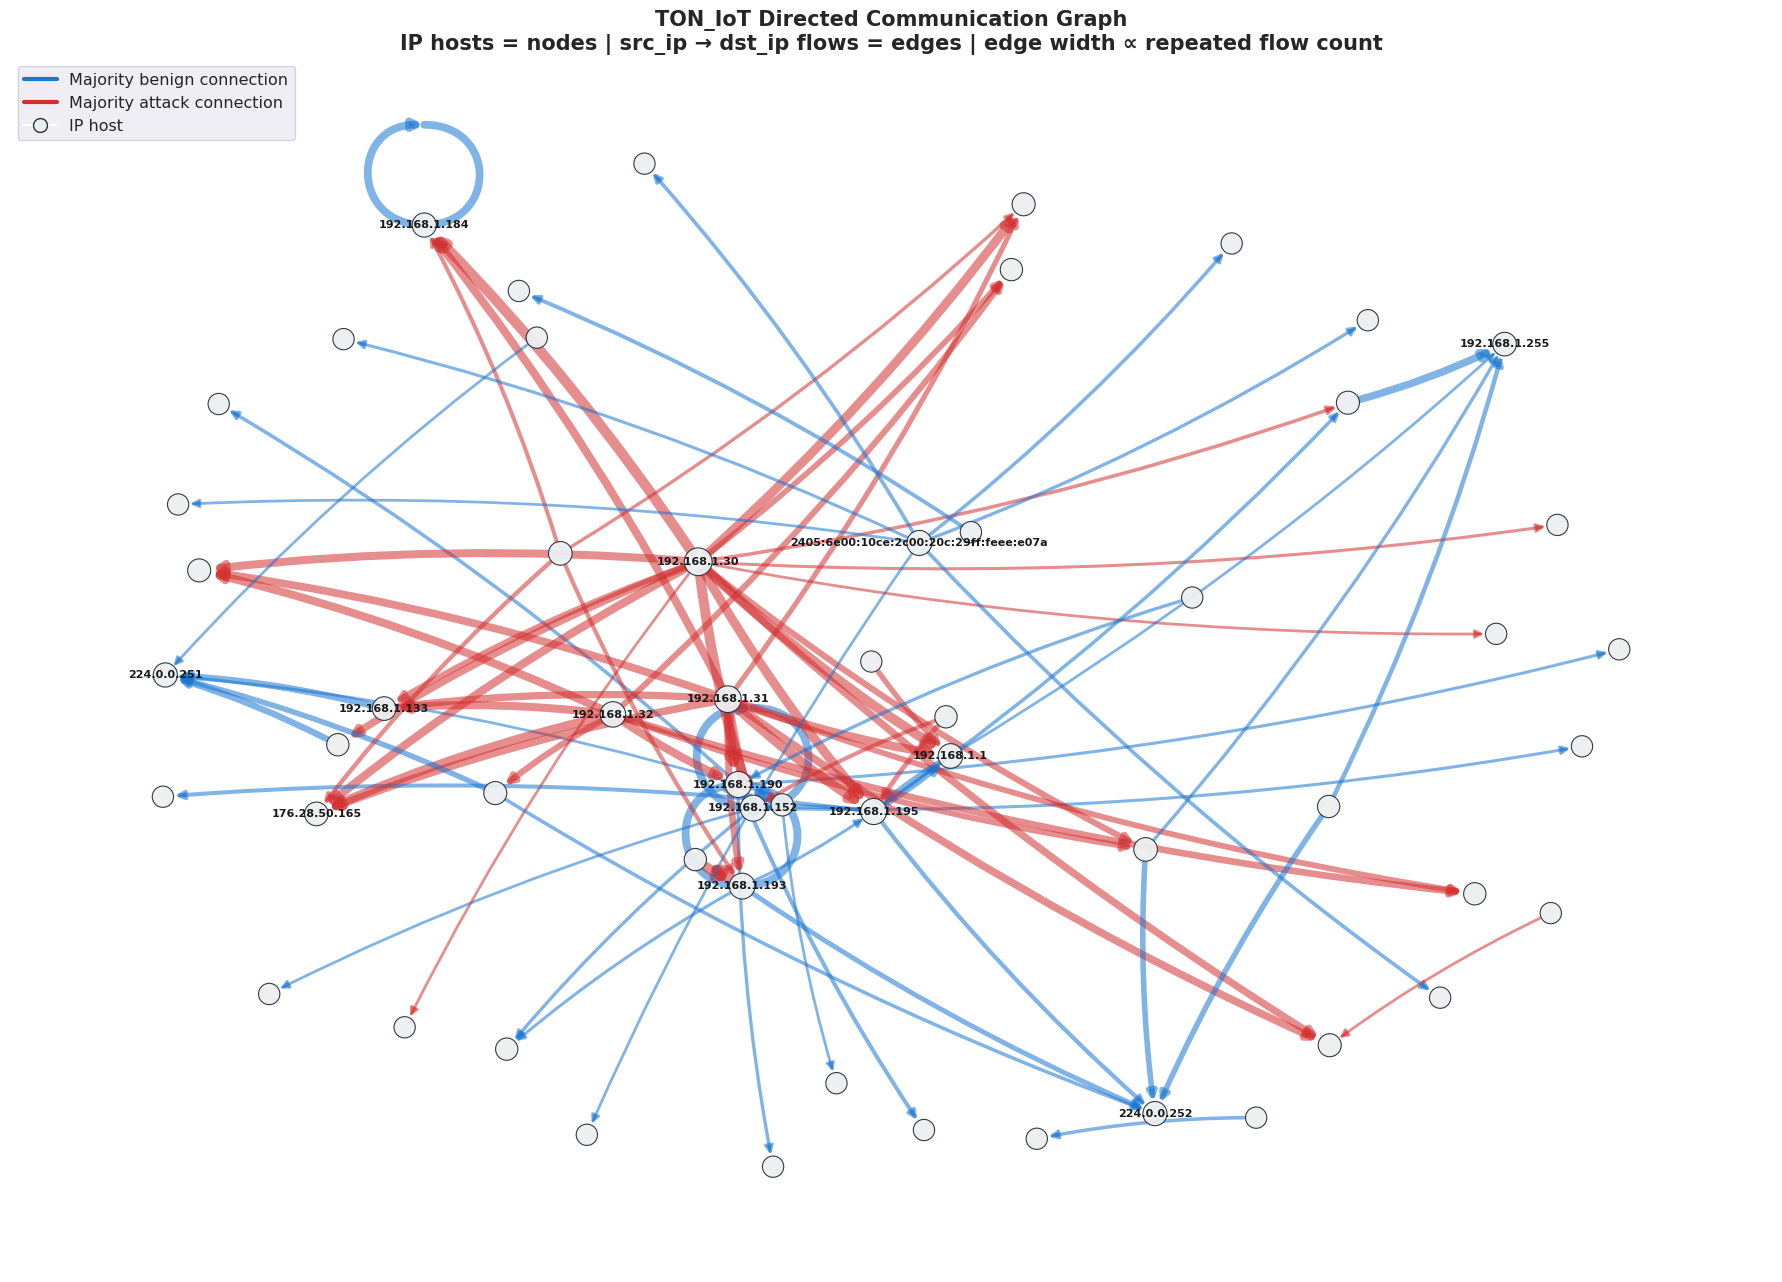

In [28]:
conn = (
    gnn_fit_df
    .groupby(
        ["src_ip", "dst_ip"],
        as_index=False
    )
    .agg(
        flow_count=("label", "size"),
        attack_rate=("label", "mean"),
        dominant_attack=(
            "type",
            lambda s: (
                s.astype(str)
                .value_counts()
                .index[0]
            )
        ),
        src_bytes=("src_bytes", "sum"),
        dst_bytes=("dst_bytes", "sum")
    )
    .sort_values(
        "flow_count",
        ascending=False
    )
)

display(conn.head(25))

top_conn = (
    conn.head(
        CFG.GRAPH_TOP_CONNECTIONS
    )
    .copy()
)

G_comm = nx.DiGraph()

for row in top_conn.itertuples(
    index=False
):
    G_comm.add_edge(
        str(row.src_ip),
        str(row.dst_ip),
        weight=float(row.flow_count),
        attack_rate=float(row.attack_rate),
        attack=str(row.dominant_attack)
    )

degree_total = dict(
    G_comm.degree()
)

pos = nx.spring_layout(
    G_comm,
    seed=CFG.SEED,
    k=1.1
)

node_sizes = [
    180 + 55*np.sqrt(
        degree_total.get(n, 1)
    )
    for n in G_comm.nodes()
]

edge_widths = [
    0.6 + np.log1p(
        G_comm[u][v]["weight"]
    )
    for u, v in G_comm.edges()
]

edge_colors = [
    "#D32F2F"
    if G_comm[u][v]["attack_rate"] >= 0.5
    else "#1976D2"
    for u, v in G_comm.edges()
]

fig, ax = plt.subplots(
    figsize=(18, 13)
)

nx.draw_networkx_nodes(
    G_comm,
    pos,
    node_size=node_sizes,
    node_color="#ECEFF1",
    edgecolors="#263238",
    linewidths=0.8,
    alpha=0.95,
    ax=ax
)

nx.draw_networkx_edges(
    G_comm,
    pos,
    width=edge_widths,
    edge_color=edge_colors,
    alpha=0.55,
    arrows=True,
    arrowsize=12,
    connectionstyle="arc3,rad=0.05",
    ax=ax
)

label_nodes = sorted(
    degree_total,
    key=degree_total.get,
    reverse=True
)[:15]

nx.draw_networkx_labels(
    G_comm,
    pos,
    labels={
        n: n
        for n in label_nodes
    },
    font_size=8,
    font_weight="bold",
    ax=ax
)

from matplotlib.lines import Line2D

legend_elements = [
    Line2D(
        [0], [0],
        color="#1976D2",
        lw=3,
        label="Majority benign connection"
    ),
    Line2D(
        [0], [0],
        color="#D32F2F",
        lw=3,
        label="Majority attack connection"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#ECEFF1",
        markeredgecolor="#263238",
        markersize=10,
        label="IP host"
    )
]

ax.legend(
    handles=legend_elements,
    loc="upper left"
)

ax.set_title(
    "TON_IoT Directed Communication Graph\n"
    "IP hosts = nodes | src_ip → dst_ip flows = edges | "
    "edge width ∝ repeated flow count",
    fontsize=15,
    fontweight="bold"
)

ax.axis("off")
plt.tight_layout()
plt.show()

### 17.2 Adjacency / Connection Matrix

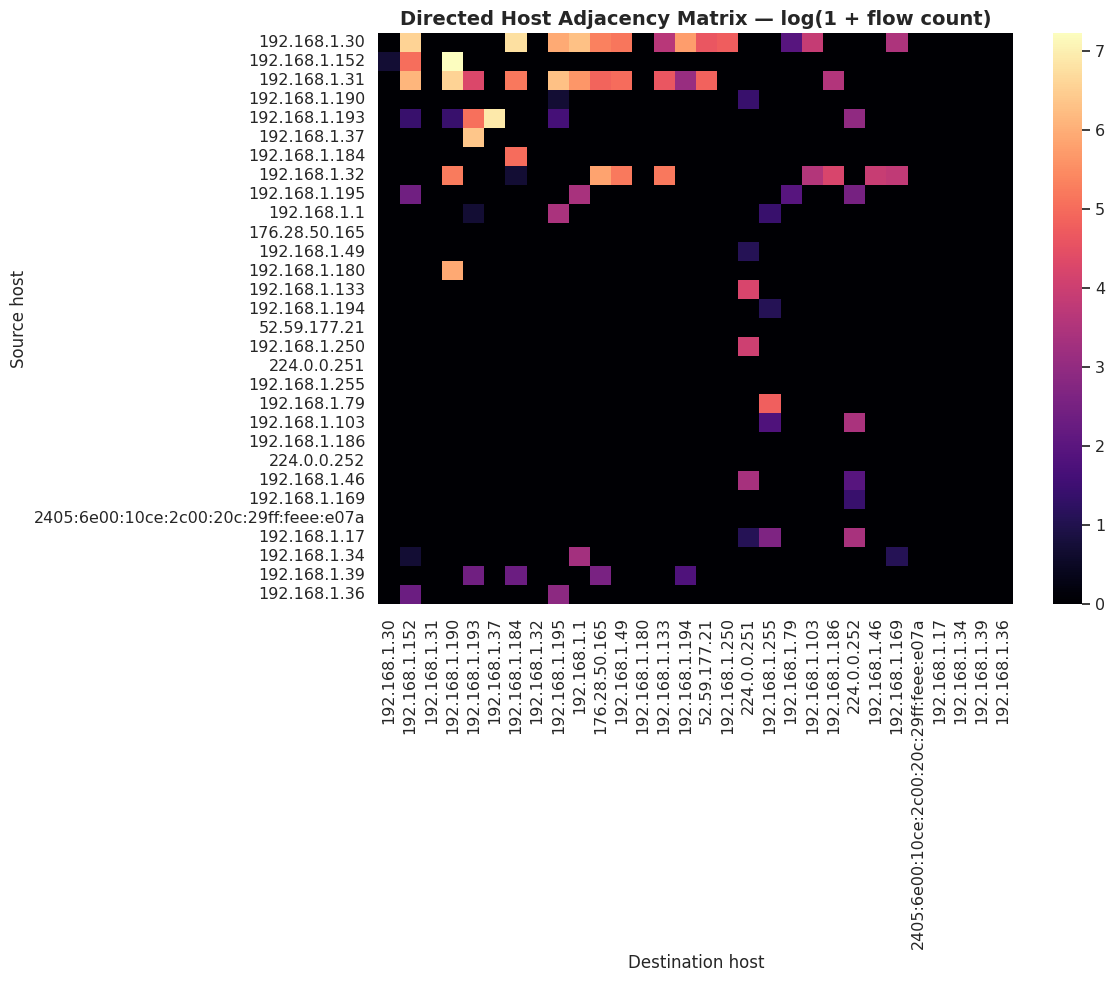

In [29]:
A = graph_fit["adj_directed"]

incident = (
    A.sum(axis=0) +
    A.sum(axis=1)
)

top_idx = np.argsort(
    incident
)[::-1][:
    min(
        30,
        len(incident)
    )
]

top_hosts = [
    graph_fit["hosts"][i]
    for i in top_idx
]

A_top = A[
    np.ix_(
        top_idx,
        top_idx
    )
]

fig, ax = plt.subplots(
    figsize=(12, 10)
)

sns.heatmap(
    np.log1p(A_top),
    cmap="magma",
    xticklabels=top_hosts,
    yticklabels=top_hosts,
    ax=ax
)

ax.set_title(
    "Directed Host Adjacency Matrix — "
    "log(1 + flow count)",
    fontweight="bold"
)
ax.set_xlabel("Destination host")
ax.set_ylabel("Source host")

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### 17.3 Ego Network Around the Highest-Traffic Host

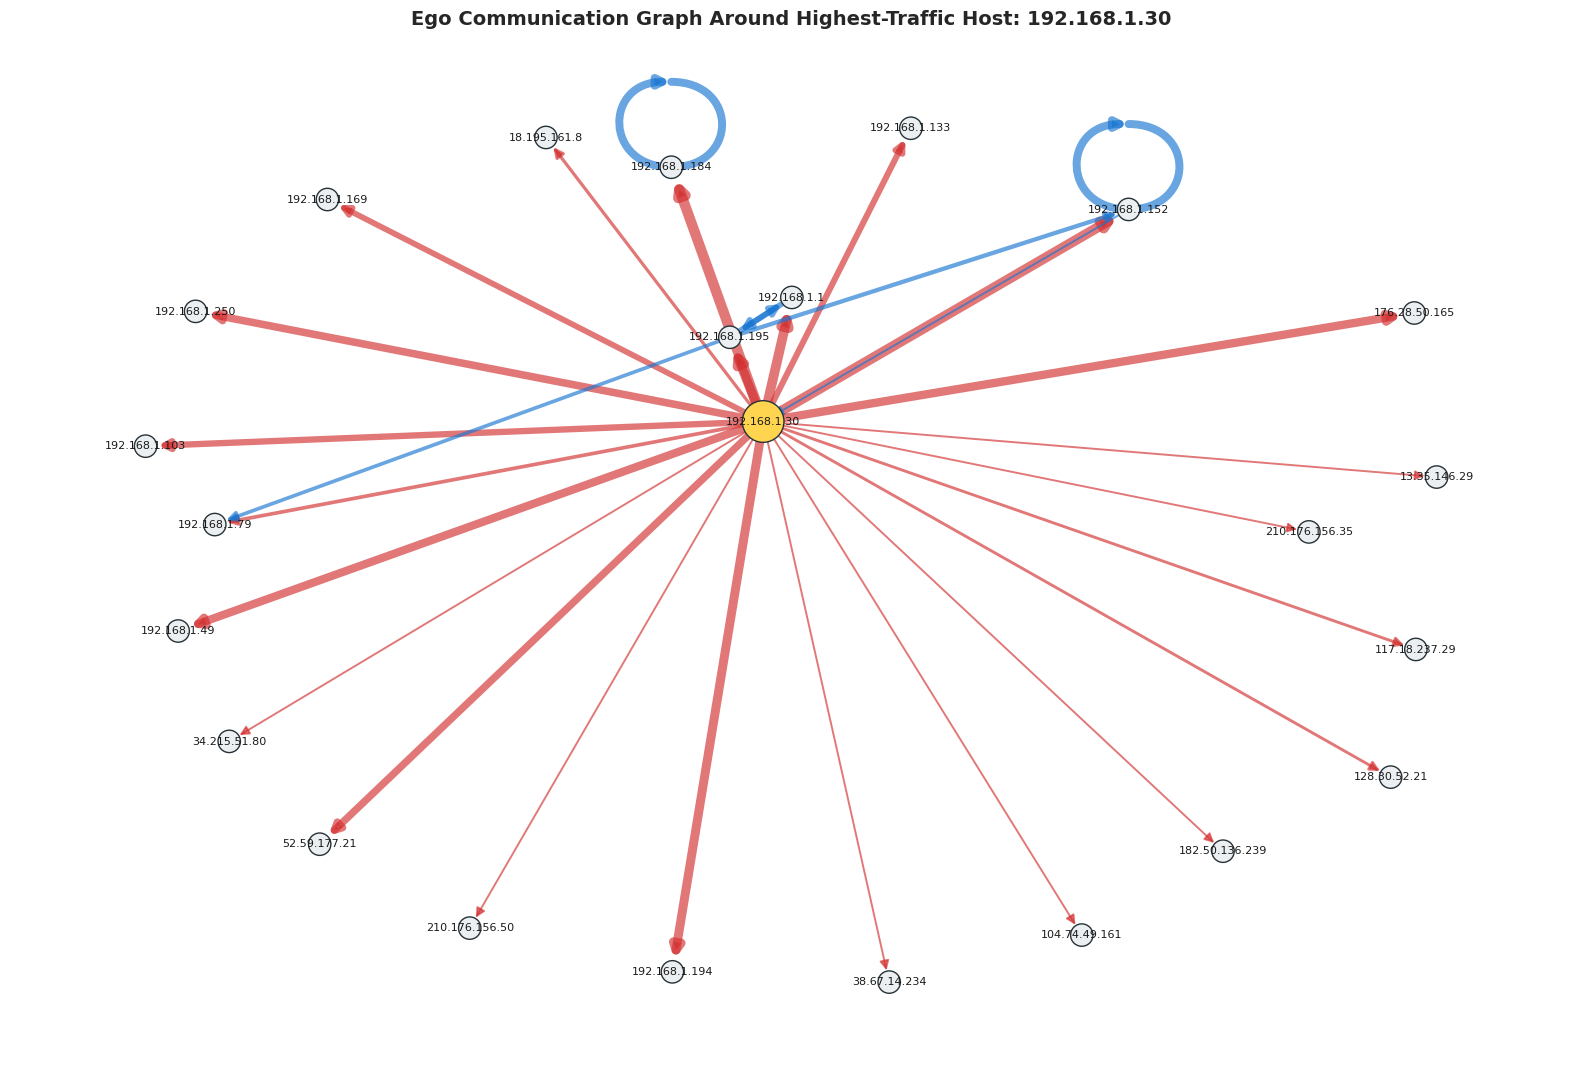

,src_ip,dst_ip,flow_count,attack_rate,dominant_attack,src_bytes,dst_bytes
125,192.168.1.30,192.168.1.184,854,1.000000,ddos,6.307626e-01,6.271837e-01
123,192.168.1.30,192.168.1.152,715,0.998601,dos,1.632238e-05,3.491503e-04
120,192.168.1.30,192.168.1.1,530,1.000000,ddos,7.022621e-06,9.020266e-06
127,192.168.1.30,192.168.1.195,378,1.000000,password,1.558218e-05,9.784321e-05
126,192.168.1.30,192.168.1.194,314,1.000000,dos,7.273465e-07,3.734682e-06
117,192.168.1.30,176.28.50.165,204,1.000000,dos,2.866979e-06,2.304992e-05
129,192.168.1.30,192.168.1.49,174,1.000000,scanning,0.000000e+00,0.000000e+00
128,192.168.1.30,192.168.1.250,114,1.000000,scanning,0.000000e+00,0.000000e+00
135,192.168.1.30,52.59.177.21,99,1.000000,injection,7.658214e-06,2.987759e-04
121,192.168.1.30,192.168.1.103,47,1.000000,scanning,0.000000e+00,0.000000e+00


In [30]:
if len(G_comm):
    hub = max(
        G_comm.degree,
        key=lambda x: x[1]
    )[0]

    G_full_vis = nx.DiGraph()

    for row in conn.itertuples(
        index=False
    ):
        G_full_vis.add_edge(
            str(row.src_ip),
            str(row.dst_ip),
            weight=float(row.flow_count),
            attack_rate=float(row.attack_rate)
        )

    nbrs = set(
        G_full_vis.predecessors(hub)
    ).union(
        G_full_vis.successors(hub)
    )

    nbrs = sorted(
        nbrs,
        key=lambda n: (
            G_full_vis
            .get_edge_data(
                hub, n, {}
            )
            .get("weight", 0)
            +
            G_full_vis
            .get_edge_data(
                n, hub, {}
            )
            .get("weight", 0)
        ),
        reverse=True
    )[:CFG.EGO_NEIGHBORS]

    ego_nodes = {
        hub,
        *nbrs
    }

    ego = (
        G_full_vis
        .subgraph(ego_nodes)
        .copy()
    )

    pos_ego = nx.spring_layout(
        ego,
        seed=CFG.SEED,
        k=1.0
    )

    widths = [
        0.7 + np.log1p(
            ego[u][v]["weight"]
        )
        for u, v in ego.edges()
    ]

    colors = [
        "#D32F2F"
        if ego[u][v]["attack_rate"] >= 0.5
        else "#1976D2"
        for u, v in ego.edges()
    ]

    sizes = [
        900 if n == hub else 260
        for n in ego.nodes()
    ]

    fig, ax = plt.subplots(
        figsize=(16, 11)
    )

    nx.draw_networkx_nodes(
        ego,
        pos_ego,
        node_size=sizes,
        node_color=[
            "#FFD54F"
            if n == hub
            else "#ECEFF1"
            for n in ego.nodes()
        ],
        edgecolors="#263238",
        ax=ax
    )

    nx.draw_networkx_edges(
        ego,
        pos_ego,
        width=widths,
        edge_color=colors,
        alpha=0.65,
        arrows=True,
        arrowsize=14,
        ax=ax
    )

    nx.draw_networkx_labels(
        ego,
        pos_ego,
        font_size=8,
        ax=ax
    )

    ax.set_title(
        f"Ego Communication Graph Around "
        f"Highest-Traffic Host: {hub}",
        fontsize=14,
        fontweight="bold"
    )

    ax.axis("off")
    plt.tight_layout()
    plt.show()

    hub_conn = conn[
        (
            conn["src_ip"].astype(str) == hub
        )
        |
        (
            conn["dst_ip"].astype(str) == hub
        )
    ]

    display(
        hub_conn.head(30)
    )

### 17.4 Flow-Similarity Graph View

This preserves the supplied notebook's original graph visualisation idea:
blue = benign flow node, red = attack flow node.

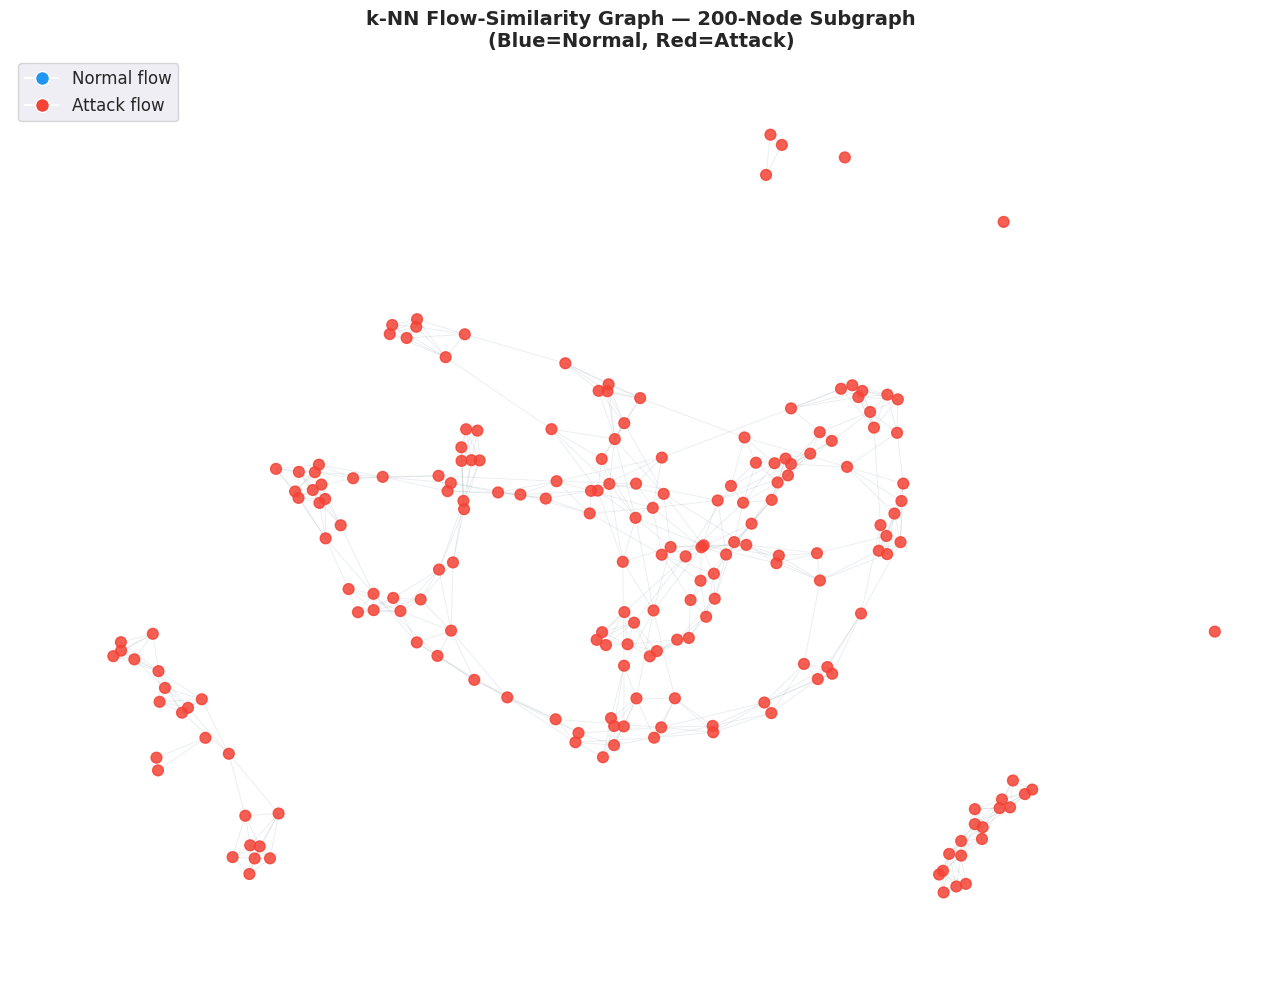

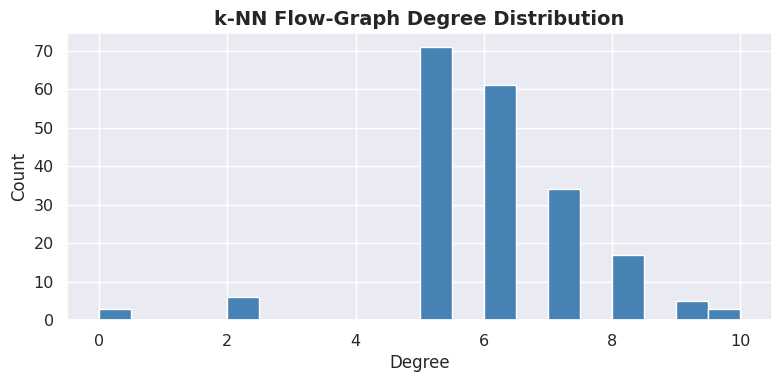

In [31]:
VIS_N = min(
    CFG.KNN_VIS_N,
    len(flow_knn_df)
)

A_sub = (
    A_dense_knn[
        :VIS_N,
        :VIS_N
    ]
    .numpy()
)

y_sub = y_graph_knn[:VIS_N]

G_knn = nx.from_numpy_array(
    A_sub
)

pos_knn = nx.spring_layout(
    G_knn,
    seed=CFG.SEED,
    k=1.5/np.sqrt(
        max(VIS_N, 1)
    )
)

node_colors = [
    "#2196F3"
    if lbl == 0
    else "#F44336"
    for lbl in y_sub
]

node_sizes = [
    30 if lbl == 0 else 60
    for lbl in y_sub
]

fig, ax = plt.subplots(
    figsize=(13, 10)
)

nx.draw_networkx_nodes(
    G_knn,
    pos_knn,
    node_color=node_colors,
    node_size=node_sizes,
    alpha=0.85,
    ax=ax
)

nx.draw_networkx_edges(
    G_knn,
    pos_knn,
    alpha=0.15,
    edge_color="#78909C",
    width=0.7,
    ax=ax
)

legend_elements = [
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#2196F3",
        markersize=10,
        label="Normal flow"
    ),
    Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor="#F44336",
        markersize=10,
        label="Attack flow"
    )
]

ax.legend(
    handles=legend_elements,
    fontsize=12,
    loc="upper left"
)

ax.set_title(
    f"k-NN Flow-Similarity Graph — "
    f"{VIS_N}-Node Subgraph\n"
    "(Blue=Normal, Red=Attack)",
    fontsize=14,
    fontweight="bold"
)

ax.axis("off")
plt.tight_layout()
plt.show()

degrees = [
    d for _, d in G_knn.degree()
]

fig, ax = plt.subplots(
    figsize=(8, 4)
)

ax.hist(
    degrees,
    bins=20,
    color="steelblue",
    edgecolor="white"
)

ax.set_title(
    "k-NN Flow-Graph Degree Distribution",
    fontweight="bold"
)
ax.set_xlabel("Degree")
ax.set_ylabel("Count")

plt.tight_layout()
plt.show()

### 17.5 Paper-Style GNN Architecture View

The GNN is adapted to **edge classification** because the TON_IoT labels belong to flows.

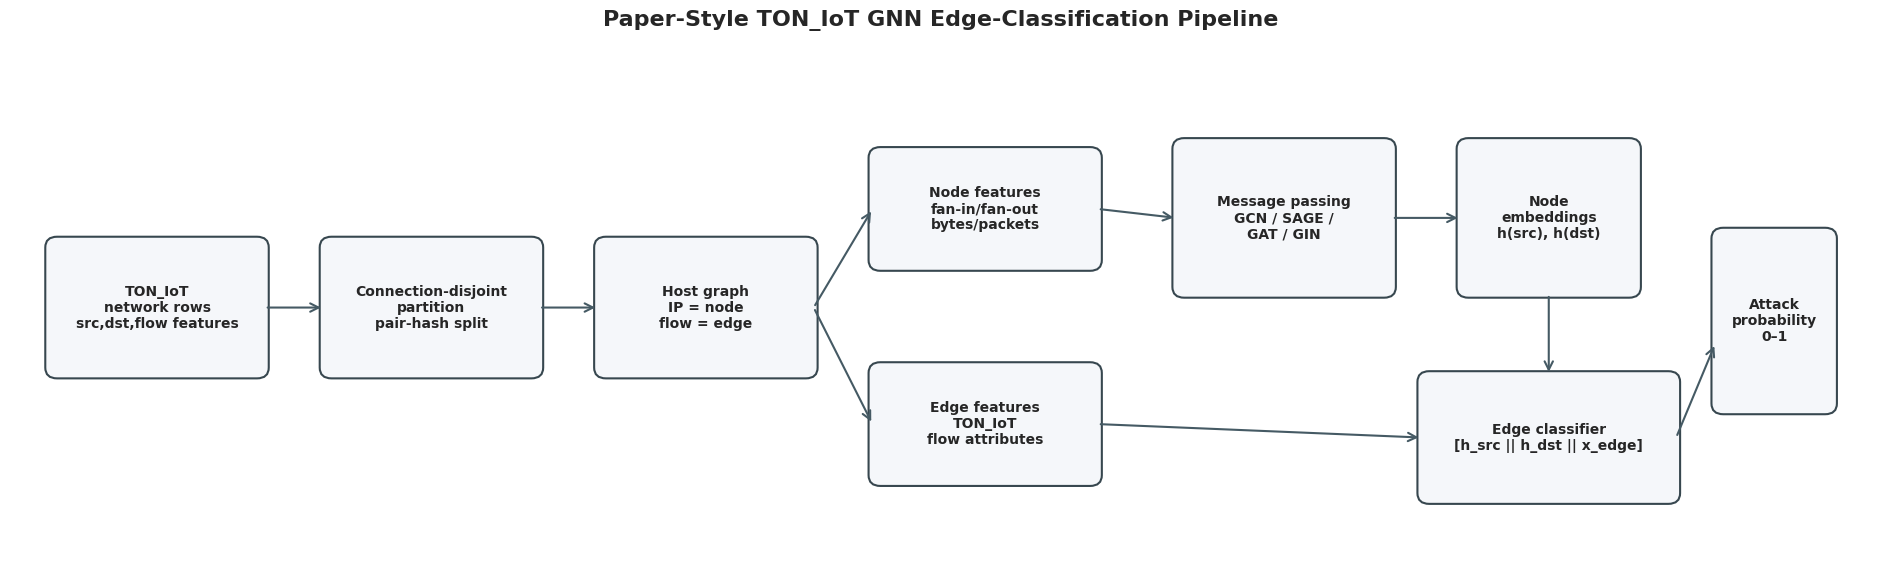

In [32]:
from matplotlib.patches import (
    FancyBboxPatch,
    FancyArrowPatch
)

fig, ax = plt.subplots(
    figsize=(19, 6)
)

ax.set_xlim(0, 19)
ax.set_ylim(0, 6)
ax.axis("off")

boxes = [
    (
        0.4, 2.2, 2.2, 1.5,
        "TON_IoT\nnetwork rows\nsrc,dst,flow features"
    ),
    (
        3.2, 2.2, 2.2, 1.5,
        "Connection-disjoint\npartition\npair-hash split"
    ),
    (
        6.0, 2.2, 2.2, 1.5,
        "Host graph\nIP = node\nflow = edge"
    ),
    (
        8.8, 3.4, 2.3, 1.3,
        "Node features\nfan-in/fan-out\nbytes/packets"
    ),
    (
        8.8, 1.0, 2.3, 1.3,
        "Edge features\nTON_IoT\nflow attributes"
    ),
    (
        11.9, 3.1, 2.2, 1.7,
        "Message passing\nGCN / SAGE /\nGAT / GIN"
    ),
    (
        14.8, 3.1, 1.8, 1.7,
        "Node\nembeddings\nh(src), h(dst)"
    ),
    (
        14.4, 0.8, 2.6, 1.4,
        "Edge classifier\n[h_src || h_dst || x_edge]"
    ),
    (
        17.4, 1.8, 1.2, 2.0,
        "Attack\nprobability\n0–1"
    )
]

for x, y, w, h, txt in boxes:
    patch = FancyBboxPatch(
        (x, y),
        w, h,
        boxstyle="round,pad=0.04,rounding_size=0.12",
        facecolor="#F5F7FA",
        edgecolor="#37474F",
        linewidth=1.5
    )
    ax.add_patch(patch)

    ax.text(
        x+w/2,
        y+h/2,
        txt,
        ha="center",
        va="center",
        fontsize=10,
        fontweight="bold"
    )

arrows = [
    ((2.6, 2.95), (3.2, 2.95)),
    ((5.4, 2.95), (6.0, 2.95)),
    ((8.2, 2.95), (8.8, 4.05)),
    ((8.2, 2.95), (8.8, 1.65)),
    ((11.1, 4.05), (11.9, 3.95)),
    ((14.1, 3.95), (14.8, 3.95)),
    ((15.7, 3.1), (15.7, 2.2)),
    ((11.1, 1.65), (14.4, 1.5)),
    ((17.0, 1.5), (17.4, 2.55))
]

for a, b in arrows:
    ax.add_patch(
        FancyArrowPatch(
            a, b,
            arrowstyle="->",
            mutation_scale=15,
            linewidth=1.5,
            color="#455A64"
        )
    )

ax.set_title(
    "Paper-Style TON_IoT GNN "
    "Edge-Classification Pipeline",
    fontsize=16,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 18. Track A — Classical Machine Learning Models

The complete baseline set from the supplied notebook is retained:

- Logistic Regression
- Decision Tree
- Random Forest
- Extra Trees
- AdaBoost
- XGBoost
- LightGBM
- CatBoost
- Gaussian Naive Bayes
- KNN
- Linear SVM
- MLP

All models use the same held-out connection-disjoint test sample later used by the GNN models.

In [33]:
ml_tr = eval_train_df.copy()
ml_te = eval_test_df.copy()

X_tr_ml = (
    ml_tr[FEAT_COLS_FINAL]
    .values.astype(np.float32)
)
y_tr_ml = (
    ml_tr[TARGET]
    .values.astype(int)
)

X_te_ml = (
    ml_te[FEAT_COLS_FINAL]
    .values.astype(np.float32)
)
y_te_ml = (
    ml_te[TARGET]
    .values.astype(int)
)

cw = class_weight_dict

ML_MODELS = {
    "Logistic Regression":
        LogisticRegression(
            max_iter=500,
            C=1.0,
            class_weight=cw,
            random_state=CFG.SEED
        ),

    "Decision Tree":
        DecisionTreeClassifier(
            max_depth=12,
            class_weight=cw,
            random_state=CFG.SEED
        ),

    "Random Forest":
        RandomForestClassifier(
            n_estimators=120,
            max_depth=12,
            class_weight=cw,
            random_state=CFG.SEED,
            n_jobs=-1
        ),

    "Extra Trees":
        ExtraTreesClassifier(
            n_estimators=120,
            max_depth=12,
            class_weight=cw,
            random_state=CFG.SEED,
            n_jobs=-1
        ),

    "AdaBoost":
        AdaBoostClassifier(
            n_estimators=80,
            random_state=CFG.SEED
        ),

    "Naive Bayes":
        GaussianNB(),

    "KNN":
        KNeighborsClassifier(
            n_neighbors=7,
            n_jobs=-1
        ),

    "Linear SVM":
        LinearSVC(
            max_iter=2500,
            class_weight=cw,
            random_state=CFG.SEED
        ),

    "MLP":
        MLPClassifier(
            hidden_layer_sizes=(64, 32),
            max_iter=120,
            random_state=CFG.SEED,
            early_stopping=True
        )
}

if XGB_AVAILABLE:
    ML_MODELS["XGBoost"] = (
        xgb.XGBClassifier(
            n_estimators=100,
            max_depth=7,
            scale_pos_weight=(
                cw.get(1, 1.0) /
                max(cw.get(0, 1.0), 1e-9)
            ),
            learning_rate=0.08,
            random_state=CFG.SEED,
            n_jobs=-1,
            verbosity=0,
            eval_metric="logloss"
        )
    )

if LGB_AVAILABLE:
    ML_MODELS["LightGBM"] = (
        lgb.LGBMClassifier(
            n_estimators=100,
            max_depth=7,
            class_weight=cw,
            learning_rate=0.08,
            random_state=CFG.SEED,
            n_jobs=-1,
            verbose=-1
        )
    )

if CAT_AVAILABLE:
    ML_MODELS["CatBoost"] = (
        cb.CatBoostClassifier(
            iterations=100,
            depth=7,
            class_weights=[
                cw.get(0, 1.0),
                cw.get(1, 1.0)
            ],
            random_state=CFG.SEED,
            verbose=0
        )
    )

all_results = {}

def model_size_mb(model):
    try:
        return (
            len(pickle.dumps(model)) /
            (1024**2)
        )
    except Exception:
        return np.nan

for name, model in ML_MODELS.items():
    try:
        print(
            f"Training {name:<24} ...",
            end=" ",
            flush=True
        )

        t0 = time.time()
        model.fit(
            X_tr_ml,
            y_tr_ml
        )
        t_train = (
            time.time() - t0
        )

        t1 = time.time()
        preds = model.predict(
            X_te_ml
        )
        t_inf = (
            time.time() - t1
        )

        if hasattr(
            model,
            "predict_proba"
        ):
            probs = (
                model.predict_proba(
                    X_te_ml
                )[:, 1]
            )

        elif hasattr(
            model,
            "decision_function"
        ):
            probs = (
                model.decision_function(
                    X_te_ml
                )
            )

        else:
            probs = (
                preds.astype(float)
            )

        cmv = confusion_matrix(
            y_te_ml,
            preds,
            labels=[0, 1]
        )
        fpr_v = (
            cmv[0, 1] /
            max(
                cmv[0].sum(),
                1
            )
        )

        all_results[name] = {
            "Accuracy":
                accuracy_score(
                    y_te_ml,
                    preds
                ),

            "Precision":
                precision_score(
                    y_te_ml,
                    preds,
                    zero_division=0
                ),

            "Recall":
                recall_score(
                    y_te_ml,
                    preds,
                    zero_division=0
                ),

            "F1":
                f1_score(
                    y_te_ml,
                    preds,
                    zero_division=0
                ),

            "ROC AUC":
                roc_auc_score(
                    y_te_ml,
                    probs
                ),

            "PR AUC":
                average_precision_score(
                    y_te_ml,
                    probs
                ),

            "FPR": fpr_v,

            "Train Time (s)":
                round(
                    t_train,
                    3
                ),

            "Infer Time (s)":
                round(
                    t_inf,
                    4
                ),

            "Model Size (MB)":
                model_size_mb(model),

            "Eval N":
                len(y_te_ml),

            "Scope":
                "Common connection-disjoint test",

            "_probs":
                np.asarray(probs),

            "_preds":
                np.asarray(preds),

            "_y_true":
                y_te_ml.copy()
        }

        print(
            f"F1="
            f"{all_results[name]['F1']:.4f} "
            f"AUC="
            f"{all_results[name]['ROC AUC']:.4f}"
        )

    except Exception as ex:
        print(
            f"⚠ failed: {ex}"
        )

print(
    f"\n✅ {len(all_results)} "
    "classical baseline models completed."
)

Training Logistic Regression      ... F1=0.9836 AUC=0.9977
Training Decision Tree            ... F1=0.8687 AUC=0.7630
Training Random Forest            ... F1=0.9934 AUC=0.9994
Training Extra Trees              ... F1=0.9956 AUC=0.9998
Training AdaBoost                 ... F1=0.9958 AUC=0.9994
Training Naive Bayes              ... F1=0.9416 AUC=0.9656
Training KNN                      ... F1=0.9630 AUC=0.8566
Training Linear SVM               ... F1=0.9880 AUC=0.9984
Training MLP                      ... F1=0.9924 AUC=0.9922
Training XGBoost                  ... F1=0.9141 AUC=0.9651
Training LightGBM                 ... F1=0.9301 AUC=0.9601
Training CatBoost                 ... F1=0.9658 AUC=0.9826

✅ 12 classical baseline models completed.


## 19. Track A — Sequential Deep Learning Models

The supplied notebook's five sequence architectures are retained:
- RNN
- LSTM
- GRU
- BiLSTM
- CNN-LSTM

Early stopping, cosine-annealing learning-rate scheduling and class-weighted binary cross-entropy are used.

Training RNN        ... early-stop@13 F1=0.9951 AUC=0.9962
Training LSTM       ... early-stop@13 F1=0.9954 AUC=0.9957
Training GRU        ... early-stop@16 F1=0.9923 AUC=0.9962
Training BiLSTM     ... early-stop@12 F1=0.9951 AUC=0.9980
Training CNN-LSTM   ... early-stop@12 F1=0.9941 AUC=0.9961


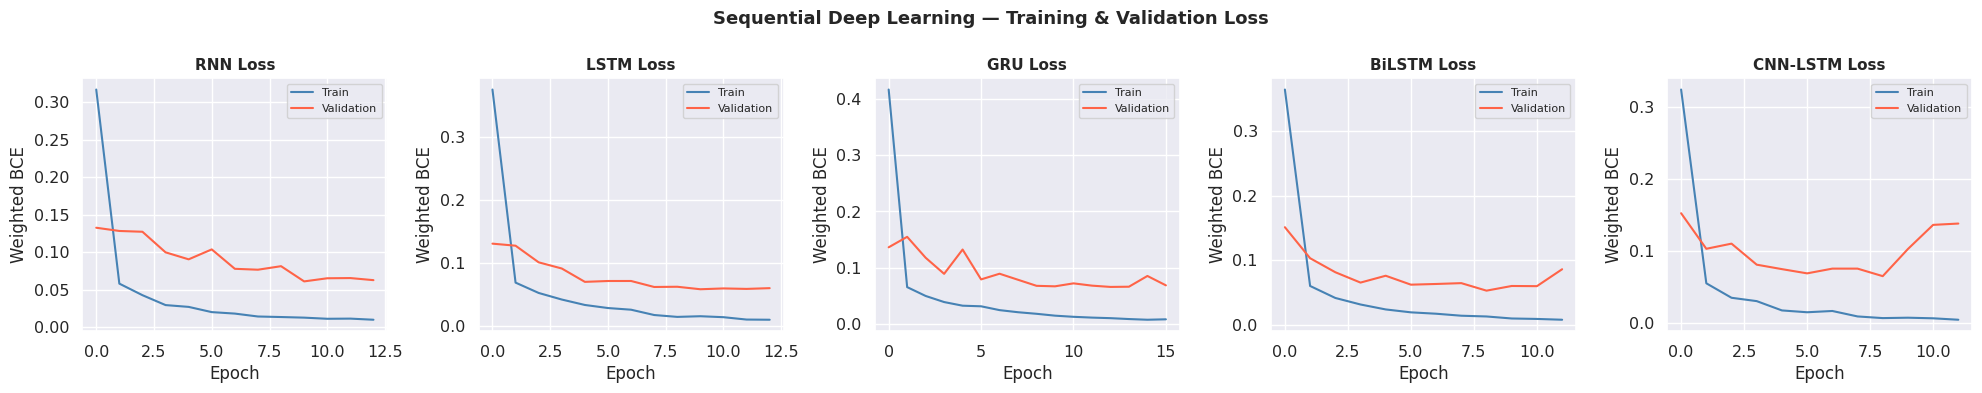

In [34]:
def make_loader(X, y, batch_size, shuffle=True):
    ds = TensorDataset(
        torch.tensor(X, dtype=torch.float32),
        torch.tensor(y, dtype=torch.float32)
    )
    return DataLoader(
        ds,
        batch_size=batch_size,
        shuffle=shuffle
    )

train_loader = make_loader(
    X_seq_tr,
    y_seq_tr,
    CFG.DL_BATCH,
    shuffle=True
)

test_loader = make_loader(
    X_seq_te,
    y_seq_te,
    CFG.DL_BATCH,
    shuffle=False
)

class SimpleRNN(nn.Module):
    def __init__(self, n_feat, hidden=32):
        super().__init__()
        self.rnn = nn.RNN(
            n_feat,
            hidden,
            batch_first=True
        )
        self.fc = nn.Linear(
            hidden,
            1
        )

    def forward(self, x):
        _, h = self.rnn(x)
        return torch.sigmoid(
            self.fc(
                h[-1]
            )
        ).squeeze(-1)


class LSTMNet(nn.Module):
    def __init__(
        self,
        n_feat,
        hidden=32,
        layers=1
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            n_feat,
            hidden,
            layers,
            batch_first=True
        )

        self.drop = nn.Dropout(
            0.2
        )

        self.fc = nn.Linear(
            hidden,
            1
        )

    def forward(self, x):
        out, _ = self.lstm(x)

        return torch.sigmoid(
            self.fc(
                self.drop(
                    out[:, -1, :]
                )
            )
        ).squeeze(-1)


class GRUNet(nn.Module):
    def __init__(
        self,
        n_feat,
        hidden=32
    ):
        super().__init__()

        self.gru = nn.GRU(
            n_feat,
            hidden,
            batch_first=True
        )

        self.drop = nn.Dropout(
            0.2
        )

        self.fc = nn.Linear(
            hidden,
            1
        )

    def forward(self, x):
        out, _ = self.gru(x)

        return torch.sigmoid(
            self.fc(
                self.drop(
                    out[:, -1, :]
                )
            )
        ).squeeze(-1)


class BiLSTMNet(nn.Module):
    def __init__(
        self,
        n_feat,
        hidden=32
    ):
        super().__init__()

        self.lstm = nn.LSTM(
            n_feat,
            hidden,
            batch_first=True,
            bidirectional=True
        )

        self.fc = nn.Linear(
            hidden * 2,
            1
        )

    def forward(self, x):
        out, _ = self.lstm(x)

        return torch.sigmoid(
            self.fc(
                out[:, -1, :]
            )
        ).squeeze(-1)


class CNNLSTMNet(nn.Module):
    def __init__(
        self,
        n_feat,
        hidden=32,
        window=5
    ):
        super().__init__()

        self.conv1 = nn.Conv1d(
            n_feat,
            32,
            kernel_size=2,
            padding=1
        )

        self.pool = (
            nn.AdaptiveMaxPool1d(
                output_size=window
            )
        )

        self.lstm = nn.LSTM(
            32,
            hidden,
            batch_first=True
        )

        self.fc = nn.Linear(
            hidden,
            1
        )

    def forward(self, x):
        xc = F.relu(
            self.conv1(
                x.permute(
                    0, 2, 1
                )
            )
        )

        xc = (
            self.pool(xc)
            .permute(
                0, 2, 1
            )
        )

        out, _ = self.lstm(xc)

        return torch.sigmoid(
            self.fc(
                out[:, -1, :]
            )
        ).squeeze(-1)


def weighted_bce(
    prob,
    target
):
    base = F.binary_cross_entropy(
        prob,
        target,
        reduction="none"
    )

    w0 = float(
        class_weight_dict.get(
            0,
            1.0
        )
    )

    w1 = float(
        class_weight_dict.get(
            1,
            1.0
        )
    )

    weights = torch.where(
        target > 0.5,
        torch.tensor(
            w1,
            device=target.device
        ),
        torch.tensor(
            w0,
            device=target.device
        )
    )

    return (
        base * weights
    ).mean()


def train_dl_model(
    model,
    tr_loader,
    te_loader,
    epochs=CFG.DL_EPOCHS,
    lr=CFG.DL_LR,
    patience=CFG.DL_PATIENCE
):
    model = model.to(
        CFG.DEVICE
    )

    opt = optim.Adam(
        model.parameters(),
        lr=lr
    )

    sched = (
        optim.lr_scheduler
        .CosineAnnealingLR(
            opt,
            T_max=max(
                epochs,
                1
            )
        )
    )

    history = {
        "train_loss": [],
        "val_loss": []
    }

    best_val = np.inf
    patience_cnt = 0

    best_state = deepcopy(
        model.state_dict()
    )

    t0 = time.time()

    for epoch in range(
        epochs
    ):
        model.train()

        train_losses = []

        for bx, by in tr_loader:
            bx = bx.to(
                CFG.DEVICE
            )

            by = by.to(
                CFG.DEVICE
            )

            opt.zero_grad()

            out = model(bx)

            loss = weighted_bce(
                out,
                by
            )

            loss.backward()
            opt.step()

            train_losses.append(
                loss.item()
            )

        model.eval()

        val_losses = []

        with torch.no_grad():
            for bx, by in te_loader:
                bx = bx.to(
                    CFG.DEVICE
                )

                by = by.to(
                    CFG.DEVICE
                )

                val_losses.append(
                    weighted_bce(
                        model(bx),
                        by
                    ).item()
                )

        tr_loss = float(
            np.mean(
                train_losses
            )
        )

        val_loss = float(
            np.mean(
                val_losses
            )
        )

        history["train_loss"].append(
            tr_loss
        )

        history["val_loss"].append(
            val_loss
        )

        sched.step()

        if val_loss < (
            best_val - 1e-6
        ):
            best_val = val_loss
            best_state = deepcopy(
                model.state_dict()
            )
            patience_cnt = 0

        else:
            patience_cnt += 1

            if (
                patience_cnt
                >= patience
            ):
                print(
                    f"early-stop@"
                    f"{epoch+1}",
                    end=" "
                )
                break

    train_time = (
        time.time() - t0
    )

    model.load_state_dict(
        best_state
    )

    model.eval()

    all_probs = []

    t1 = time.time()

    with torch.no_grad():
        for bx, _ in te_loader:
            bx = bx.to(
                CFG.DEVICE
            )

            all_probs.extend(
                model(bx)
                .detach()
                .cpu()
                .numpy()
                .tolist()
            )

    inf_time = (
        time.time() - t1
    )

    probs = np.asarray(
        all_probs
    )

    preds = (
        probs >= 0.5
    ).astype(int)

    return (
        model,
        preds,
        probs,
        train_time,
        inf_time,
        history
    )


DL_ARCHITECTURES = {
    "RNN":
        SimpleRNN(
            N_FEATURES,
            CFG.DL_HIDDEN
        ),

    "LSTM":
        LSTMNet(
            N_FEATURES,
            CFG.DL_HIDDEN
        ),

    "GRU":
        GRUNet(
            N_FEATURES,
            CFG.DL_HIDDEN
        ),

    "BiLSTM":
        BiLSTMNet(
            N_FEATURES,
            CFG.DL_HIDDEN
        ),

    "CNN-LSTM":
        CNNLSTMNet(
            N_FEATURES,
            CFG.DL_HIDDEN,
            CFG.WINDOW_SIZE
        )
}

dl_histories = {}

for name, model in DL_ARCHITECTURES.items():
    print(
        f"Training "
        f"{name:<10} ...",
        end=" ",
        flush=True
    )

    (
        model,
        preds,
        probs,
        t_tr,
        t_inf,
        hist
    ) = train_dl_model(
        model,
        train_loader,
        test_loader
    )

    y_true_dl = (
        y_seq_te
        .astype(int)
    )

    dl_histories[name] = (
        hist
    )

    cmv = confusion_matrix(
        y_true_dl,
        preds,
        labels=[0, 1]
    )

    fpr_v = (
        cmv[0, 1] /
        max(
            cmv[0].sum(),
            1
        )
    )

    all_results[name] = {
        "Accuracy":
            accuracy_score(
                y_true_dl,
                preds
            ),

        "Precision":
            precision_score(
                y_true_dl,
                preds,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true_dl,
                preds,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true_dl,
                preds,
                zero_division=0
            ),

        "ROC AUC":
            roc_auc_score(
                y_true_dl,
                probs
            ),

        "PR AUC":
            average_precision_score(
                y_true_dl,
                probs
            ),

        "FPR":
            fpr_v,

        "Train Time (s)":
            round(
                t_tr,
                3
            ),

        "Infer Time (s)":
            round(
                t_inf,
                4
            ),

        "Model Size (MB)":
            (
                sum(
                    p.numel() *
                    p.element_size()
                    for p in model.parameters()
                )
                /
                (1024**2)
            ),

        "Eval N":
            len(y_true_dl),

        "Scope":
            "Ordered-flow sequence test",

        "_probs":
            probs,

        "_preds":
            preds,

        "_y_true":
            y_true_dl
    }

    print(
        f"F1="
        f"{all_results[name]['F1']:.4f} "
        f"AUC="
        f"{all_results[name]['ROC AUC']:.4f}"
    )

fig, axes = plt.subplots(
    1,
    len(dl_histories),
    figsize=(
        4*len(dl_histories),
        4
    )
)

if len(dl_histories) == 1:
    axes = [axes]

for ax, (
    name,
    hist
) in zip(
    axes,
    dl_histories.items()
):
    ax.plot(
        hist["train_loss"],
        label="Train",
        color="steelblue"
    )

    ax.plot(
        hist["val_loss"],
        label="Validation",
        color="tomato"
    )

    ax.set_title(
        f"{name} Loss",
        fontsize=11,
        fontweight="bold"
    )

    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weighted BCE")
    ax.legend(fontsize=8)

plt.suptitle(
    "Sequential Deep Learning — "
    "Training & Validation Loss",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

## 20. Track B — Graph Neural Networks

Four GNN architectures are implemented in pure PyTorch and adapted to the **real TON_IoT host graph**.

| Model | Aggregation | Main advantage |
|---|---|---|
| GCN | Normalised neighbour sum | Graph smoothing |
| GraphSAGE | Mean neighbourhood | Inductive generalisation |
| GAT | Attention-weighted neighbourhood | Adaptive neighbour importance |
| GIN | MLP on neighbourhood sum | High structural expressive power |

### Edge Classification

\[
z_{uv}=[h_u \Vert h_v \Vert x_{uv}]
\]

The edge classifier uses the source embedding, destination embedding and flow features.

Training GCN        GNN ... F1=0.2301 AUC=0.7941
Training GraphSAGE  GNN ... F1=0.4868 AUC=0.7263
Training GAT        GNN ... F1=0.0000 AUC=0.6993
Training GIN        GNN ... F1=0.9135 AUC=0.7388


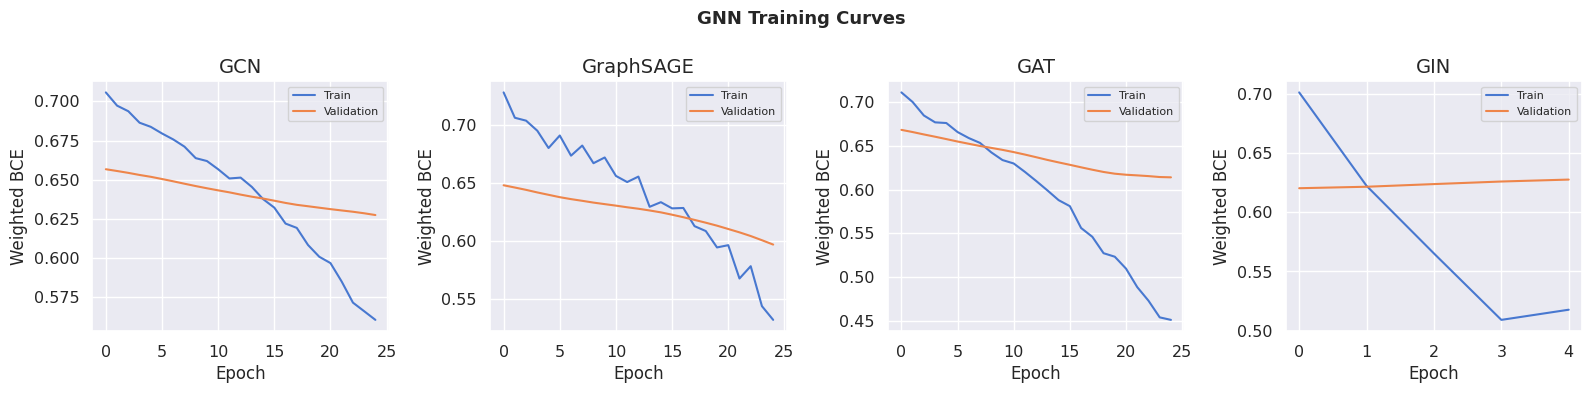


✅ GNN training complete — 4 architectures.


In [35]:
class GCNLayer(nn.Module):
    """Kipf-Welling style graph convolution."""

    def __init__(
        self,
        in_f,
        out_f
    ):
        super().__init__()

        self.W = nn.Linear(
            in_f,
            out_f,
            bias=True
        )

    def forward(
        self,
        x,
        adj
    ):
        eye = torch.eye(
            adj.size(0),
            device=adj.device
        )

        a = adj + eye

        deg = a.sum(1)

        d_inv = torch.pow(
            deg.clamp(
                min=1e-6
            ),
            -0.5
        )

        a_norm = (
            d_inv[:, None]
            *
            a
            *
            d_inv[None, :]
        )

        return F.relu(
            self.W(
                a_norm @ x
            )
        )


class SAGELayer(nn.Module):
    """GraphSAGE mean aggregation."""

    def __init__(
        self,
        in_f,
        out_f
    ):
        super().__init__()

        self.W = nn.Linear(
            in_f * 2,
            out_f
        )

    def forward(
        self,
        x,
        adj
    ):
        deg = (
            adj.sum(
                1,
                keepdim=True
            )
            .clamp(
                min=1.0
            )
        )

        agg = (
            adj @ x
        ) / deg

        return F.relu(
            self.W(
                torch.cat(
                    [x, agg],
                    dim=1
                )
            )
        )


class GATLayer(nn.Module):
    """Single-head dense GAT layer."""

    def __init__(
        self,
        in_f,
        out_f
    ):
        super().__init__()

        self.W = nn.Linear(
            in_f,
            out_f,
            bias=False
        )

        self.a = nn.Linear(
            2*out_f,
            1,
            bias=False
        )

    def forward(
        self,
        x,
        adj
    ):
        Wh = self.W(x)

        N = Wh.size(0)

        Wh_i = (
            Wh.unsqueeze(1)
            .expand(
                -1,
                N,
                -1
            )
        )

        Wh_j = (
            Wh.unsqueeze(0)
            .expand(
                N,
                -1,
                -1
            )
        )

        e = (
            self.a(
                torch.cat(
                    [
                        Wh_i,
                        Wh_j
                    ],
                    dim=-1
                )
            )
            .squeeze(-1)
        )

        mask_adj = (
            adj
            +
            torch.eye(
                N,
                device=adj.device
            )
        ) > 0

        e = e.masked_fill(
            ~mask_adj,
            -1e9
        )

        attn = F.softmax(
            e,
            dim=1
        )

        return F.elu(
            attn @ Wh
        )


class GINLayer(nn.Module):
    """Graph Isomorphism Network layer."""

    def __init__(
        self,
        in_f,
        out_f
    ):
        super().__init__()

        self.mlp = nn.Sequential(
            nn.Linear(
                in_f,
                out_f
            ),
            nn.ReLU(),
            nn.Linear(
                out_f,
                out_f
            )
        )

        self.eps = nn.Parameter(
            torch.zeros(1)
        )

    def forward(
        self,
        x,
        adj
    ):
        agg = adj @ x

        return F.relu(
            self.mlp(
                (
                    1 +
                    self.eps
                )
                * x
                +
                agg
            )
        )


class EdgeGNNClassifier(nn.Module):
    """
    Two-layer graph encoder plus
    flow-edge binary classifier.
    """

    def __init__(
        self,
        layer_cls,
        node_in,
        edge_in,
        hidden=32
    ):
        super().__init__()

        self.conv1 = layer_cls(
            node_in,
            hidden
        )

        self.conv2 = layer_cls(
            hidden,
            hidden
        )

        self.drop = nn.Dropout(
            0.25
        )

        self.edge_mlp = nn.Sequential(
            nn.Linear(
                hidden*2 +
                edge_in,
                hidden
            ),
            nn.ReLU(),
            nn.Dropout(
                0.2
            ),
            nn.Linear(
                hidden,
                1
            )
        )

    def encode(
        self,
        node_x,
        adj
    ):
        h = self.conv1(
            node_x,
            adj
        )

        h = self.drop(h)

        h = self.conv2(
            h,
            adj
        )

        return h

    def forward(
        self,
        node_x,
        adj,
        src,
        dst,
        edge_x
    ):
        h = self.encode(
            node_x,
            adj
        )

        z = torch.cat(
            [
                h[src],
                h[dst],
                edge_x
            ],
            dim=1
        )

        return torch.sigmoid(
            self.edge_mlp(z)
        ).squeeze(-1)


def graph_to_tensors(g):
    return {
        "node_x":
            torch.tensor(
                g["node_x"],
                dtype=torch.float32,
                device=CFG.DEVICE
            ),

        "adj":
            torch.tensor(
                g["adj_msg"],
                dtype=torch.float32,
                device=CFG.DEVICE
            ),

        "src":
            torch.tensor(
                g["src"],
                dtype=torch.long,
                device=CFG.DEVICE
            ),

        "dst":
            torch.tensor(
                g["dst"],
                dtype=torch.long,
                device=CFG.DEVICE
            ),

        "edge_x":
            torch.tensor(
                g["edge_x"],
                dtype=torch.float32,
                device=CFG.DEVICE
            ),

        "y":
            torch.tensor(
                g["y"],
                dtype=torch.float32,
                device=CFG.DEVICE
            )
    }


fit_t = graph_to_tensors(
    graph_fit
)
val_t = graph_to_tensors(
    graph_val
)
test_t = graph_to_tensors(
    graph_test
)

gnn_counts = Counter(
    graph_fit["y"].astype(int)
)

gnn_total = len(
    graph_fit["y"]
)

gnn_weights = {
    cls:
        gnn_total /
        (
            len(gnn_counts) *
            cnt
        )
    for cls, cnt
    in gnn_counts.items()
}


def weighted_graph_bce(
    prob,
    target,
    weights
):
    base = F.binary_cross_entropy(
        prob,
        target,
        reduction="none"
    )

    w0 = float(
        weights.get(
            0,
            1.0
        )
    )

    w1 = float(
        weights.get(
            1,
            1.0
        )
    )

    w = torch.where(
        target > 0.5,
        torch.tensor(
            w1,
            device=target.device
        ),
        torch.tensor(
            w0,
            device=target.device
        )
    )

    return (
        base * w
    ).mean()


def train_edge_gnn(
    model,
    fit_t,
    val_t,
    test_t,
    epochs=CFG.GNN_EPOCHS,
    lr=CFG.GNN_LR,
    patience=CFG.GNN_PATIENCE
):
    model = model.to(
        CFG.DEVICE
    )

    opt = optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=5e-4
    )

    best_state = deepcopy(
        model.state_dict()
    )

    best_val = np.inf
    wait = 0

    history = {
        "train_loss": [],
        "val_loss": []
    }

    t0 = time.time()

    for epoch in range(
        epochs
    ):
        model.train()

        opt.zero_grad()

        p = model(
            fit_t["node_x"],
            fit_t["adj"],
            fit_t["src"],
            fit_t["dst"],
            fit_t["edge_x"]
        )

        loss = weighted_graph_bce(
            p,
            fit_t["y"],
            gnn_weights
        )

        loss.backward()

        torch.nn.utils.clip_grad_norm_(
            model.parameters(),
            5.0
        )

        opt.step()

        model.eval()

        with torch.no_grad():
            pv = model(
                val_t["node_x"],
                val_t["adj"],
                val_t["src"],
                val_t["dst"],
                val_t["edge_x"]
            )

            vloss = (
                weighted_graph_bce(
                    pv,
                    val_t["y"],
                    gnn_weights
                )
                .item()
            )

        history[
            "train_loss"
        ].append(
            float(
                loss.item()
            )
        )

        history[
            "val_loss"
        ].append(
            float(
                vloss
            )
        )

        if vloss < (
            best_val -
            1e-6
        ):
            best_val = vloss

            best_state = deepcopy(
                model.state_dict()
            )

            wait = 0

        else:
            wait += 1

            if (
                wait >=
                patience
            ):
                break

    train_time = (
        time.time() -
        t0
    )

    model.load_state_dict(
        best_state
    )

    model.eval()

    t1 = time.time()

    with torch.no_grad():
        probs = (
            model(
                test_t["node_x"],
                test_t["adj"],
                test_t["src"],
                test_t["dst"],
                test_t["edge_x"]
            )
            .detach()
            .cpu()
            .numpy()
        )

    infer_time = (
        time.time() -
        t1
    )

    preds = (
        probs >= 0.5
    ).astype(int)

    y_true = (
        test_t["y"]
        .detach()
        .cpu()
        .numpy()
        .astype(int)
    )

    return (
        model,
        y_true,
        preds,
        probs,
        train_time,
        infer_time,
        history
    )


node_in = (
    graph_fit["node_x"]
    .shape[1]
)

edge_in = (
    graph_fit["edge_x"]
    .shape[1]
)

GNN_MODELS = {
    "GCN":
        EdgeGNNClassifier(
            GCNLayer,
            node_in,
            edge_in,
            CFG.GNN_HIDDEN
        ),

    "GraphSAGE":
        EdgeGNNClassifier(
            SAGELayer,
            node_in,
            edge_in,
            CFG.GNN_HIDDEN
        ),

    "GAT":
        EdgeGNNClassifier(
            GATLayer,
            node_in,
            edge_in,
            CFG.GNN_HIDDEN
        ),

    "GIN":
        EdgeGNNClassifier(
            GINLayer,
            node_in,
            edge_in,
            CFG.GNN_HIDDEN
        )
}

gnn_histories = {}

for name, model in GNN_MODELS.items():
    print(
        f"Training "
        f"{name:<10} GNN ...",
        end=" ",
        flush=True
    )

    (
        model,
        y_true_g,
        preds_g,
        probs_g,
        t_tr,
        t_inf,
        hist
    ) = train_edge_gnn(
        model,
        fit_t,
        val_t,
        test_t
    )

    gnn_histories[name] = (
        hist
    )

    cmv = confusion_matrix(
        y_true_g,
        preds_g,
        labels=[0, 1]
    )

    fpr_v = (
        cmv[0, 1] /
        max(
            cmv[0].sum(),
            1
        )
    )

    all_results[
        f"{name} (GNN)"
    ] = {
        "Accuracy":
            accuracy_score(
                y_true_g,
                preds_g
            ),

        "Precision":
            precision_score(
                y_true_g,
                preds_g,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_true_g,
                preds_g,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_true_g,
                preds_g,
                zero_division=0
            ),

        "ROC AUC":
            roc_auc_score(
                y_true_g,
                probs_g
            ),

        "PR AUC":
            average_precision_score(
                y_true_g,
                probs_g
            ),

        "FPR":
            fpr_v,

        "Train Time (s)":
            round(
                t_tr,
                3
            ),

        "Infer Time (s)":
            round(
                t_inf,
                4
            ),

        "Model Size (MB)":
            (
                sum(
                    p.numel() *
                    p.element_size()
                    for p in model.parameters()
                )
                /
                (1024**2)
            ),

        "Eval N":
            len(y_true_g),

        "Scope":
            "Common connection-disjoint test",

        "_probs":
            probs_g,

        "_preds":
            preds_g,

        "_y_true":
            y_true_g
    }

    r = all_results[
        f"{name} (GNN)"
    ]

    print(
        f"F1="
        f"{r['F1']:.4f} "
        f"AUC="
        f"{r['ROC AUC']:.4f}"
    )

fig, axes = plt.subplots(
    1,
    len(gnn_histories),
    figsize=(
        4*len(gnn_histories),
        4
    )
)

if len(
    gnn_histories
) == 1:
    axes = [axes]

for ax, (
    name,
    hist
) in zip(
    axes,
    gnn_histories.items()
):
    ax.plot(
        hist["train_loss"],
        label="Train"
    )

    ax.plot(
        hist["val_loss"],
        label="Validation"
    )

    ax.set_title(name)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Weighted BCE")
    ax.legend(fontsize=8)

plt.suptitle(
    "GNN Training Curves",
    fontsize=13,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

print(
    f"\n✅ GNN training complete — "
    f"{len(GNN_MODELS)} architectures."
)

## 21. Hyperparameter Tuning

The supplied sample tunes LightGBM with Optuna. That content is retained, but the procedure is corrected so the final test set is never used for model selection.

- Fit buckets: 0–5
- Validation bucket: 6
- Final held-out test: 7–9

Running Optuna LightGBM search (10 trials) ...
Best validation F1: 0.9996904982977406
Best parameters:
{'n_estimators': 123, 'max_depth': 3, 'learning_rate': 0.07068239480981442, 'num_leaves': 26, 'subsample': 0.6260206371941118, 'colsample_bytree': 0.9795542149013333, 'min_child_samples': 49}


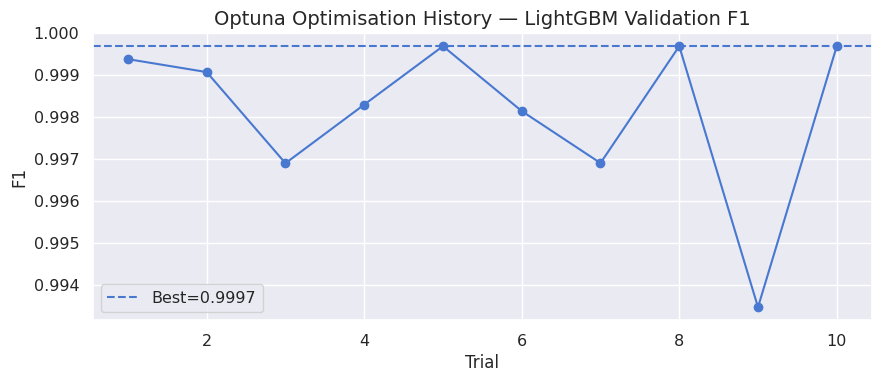

In [36]:
if OPTUNA_AVAILABLE and LGB_AVAILABLE:
    tune_fit_pool = df_train_enc[
        df_train_enc["_split_bucket"].isin(
            CFG.TUNE_BUCKETS
        )
    ]

    tune_val_pool = df_train_enc[
        df_train_enc["_split_bucket"].isin(
            CFG.VAL_BUCKETS
        )
    ]

    tune_tr = tune_fit_pool.sample(
        n=min(12_000, len(tune_fit_pool)),
        random_state=CFG.SEED
    )

    tune_va = tune_val_pool.sample(
        n=min(4_000, len(tune_val_pool)),
        random_state=CFG.SEED + 1
    )

    X_tune_tr = tune_tr[
        FEAT_COLS_FINAL
    ].values

    y_tune_tr = tune_tr[
        TARGET
    ].values.astype(int)

    X_tune_va = tune_va[
        FEAT_COLS_FINAL
    ].values

    y_tune_va = tune_va[
        TARGET
    ].values.astype(int)

    def lgb_objective(trial):
        params = {
            "n_estimators":
                trial.suggest_int(
                    "n_estimators",
                    40,
                    180
                ),

            "max_depth":
                trial.suggest_int(
                    "max_depth",
                    3,
                    10
                ),

            "learning_rate":
                trial.suggest_float(
                    "learning_rate",
                    0.01,
                    0.25,
                    log=True
                ),

            "num_leaves":
                trial.suggest_int(
                    "num_leaves",
                    15,
                    80
                ),

            "subsample":
                trial.suggest_float(
                    "subsample",
                    0.6,
                    1.0
                ),

            "colsample_bytree":
                trial.suggest_float(
                    "colsample_bytree",
                    0.6,
                    1.0
                ),

            "min_child_samples":
                trial.suggest_int(
                    "min_child_samples",
                    5,
                    50
                ),

            "verbose": -1,
            "random_state": CFG.SEED,
            "n_jobs": -1
        }

        clf = lgb.LGBMClassifier(
            **params,
            class_weight=class_weight_dict
        )

        clf.fit(
            X_tune_tr,
            y_tune_tr
        )

        pred = clf.predict(
            X_tune_va
        )

        return f1_score(
            y_tune_va,
            pred,
            zero_division=0
        )

    print(
        "Running Optuna LightGBM search "
        "(10 trials) ..."
    )

    study = optuna.create_study(
        direction="maximize",
        sampler=(
            optuna.samplers
            .TPESampler(
                seed=CFG.SEED
            )
        )
    )

    study.optimize(
        lgb_objective,
        n_trials=10,
        show_progress_bar=False
    )

    print(
        "Best validation F1:",
        study.best_value
    )

    print(
        "Best parameters:"
    )
    print(
        study.best_params
    )

    trial_vals = [
        t.value
        for t in study.trials
        if t.value is not None
    ]

    fig, ax = plt.subplots(
        figsize=(9, 4)
    )

    ax.plot(
        range(
            1,
            len(trial_vals)+1
        ),
        trial_vals,
        "o-"
    )

    ax.axhline(
        max(trial_vals),
        ls="--",
        label=(
            f"Best="
            f"{max(trial_vals):.4f}"
        )
    )

    ax.set_title(
        "Optuna Optimisation History — "
        "LightGBM Validation F1"
    )
    ax.set_xlabel("Trial")
    ax.set_ylabel("F1")
    ax.legend()

    plt.tight_layout()
    plt.show()

    best_lgb = lgb.LGBMClassifier(
        **study.best_params,
        class_weight=class_weight_dict,
        n_jobs=-1,
        random_state=CFG.SEED,
        verbose=-1
    )

    t0 = time.time()

    best_lgb.fit(
        X_tr_ml,
        y_tr_ml
    )

    t_tr = (
        time.time() -
        t0
    )

    t1 = time.time()

    tuned_preds = (
        best_lgb.predict(
            X_te_ml
        )
    )

    tuned_probs = (
        best_lgb.predict_proba(
            X_te_ml
        )[:, 1]
    )

    t_inf = (
        time.time() -
        t1
    )

    cmv = confusion_matrix(
        y_te_ml,
        tuned_preds,
        labels=[0, 1]
    )

    fpr_v = (
        cmv[0, 1] /
        max(
            cmv[0].sum(),
            1
        )
    )

    all_results[
        "LightGBM (Tuned)"
    ] = {
        "Accuracy":
            accuracy_score(
                y_te_ml,
                tuned_preds
            ),

        "Precision":
            precision_score(
                y_te_ml,
                tuned_preds,
                zero_division=0
            ),

        "Recall":
            recall_score(
                y_te_ml,
                tuned_preds,
                zero_division=0
            ),

        "F1":
            f1_score(
                y_te_ml,
                tuned_preds,
                zero_division=0
            ),

        "ROC AUC":
            roc_auc_score(
                y_te_ml,
                tuned_probs
            ),

        "PR AUC":
            average_precision_score(
                y_te_ml,
                tuned_probs
            ),

        "FPR":
            fpr_v,

        "Train Time (s)":
            round(t_tr, 3),

        "Infer Time (s)":
            round(t_inf, 4),

        "Model Size (MB)":
            model_size_mb(
                best_lgb
            ),

        "Eval N":
            len(y_te_ml),

        "Scope":
            "Common connection-disjoint test",

        "_probs":
            tuned_probs,

        "_preds":
            tuned_preds,

        "_y_true":
            y_te_ml.copy()
    }

else:
    print(
        "⚠ Optuna and/or LightGBM unavailable. "
        "Hyperparameter tuning skipped safely."
    )

## 22. Model Evaluation

### 22.1 Comprehensive Metrics Table

The table reports:
- Accuracy
- Precision
- Recall
- F1
- ROC-AUC
- PR-AUC
- False Positive Rate
- Training time
- Inference time
- Model size
- Evaluation sample size / scope

In [37]:
table_rows = {}

for name, res in all_results.items():
    table_rows[name] = {
        k: v
        for k, v in res.items()
        if not k.startswith("_")
    }

results_df = (
    pd.DataFrame(
        table_rows
    )
    .T
)

numeric_cols_results = [
    "Accuracy",
    "Precision",
    "Recall",
    "F1",
    "ROC AUC",
    "PR AUC",
    "FPR",
    "Train Time (s)",
    "Infer Time (s)",
    "Model Size (MB)",
    "Eval N"
]

for col in numeric_cols_results:
    if col in results_df.columns:
        results_df[col] = pd.to_numeric(
            results_df[col],
            errors="coerce"
        )

results_df = results_df.sort_values(
    "F1",
    ascending=False
)

print("=" * 105)
print(
    "  COMPREHENSIVE MODEL "
    "EVALUATION SUMMARY"
)
print("=" * 105)

display(results_df)

print("\nTop models by F1:")

display(
    results_df[[
        "F1",
        "Recall",
        "Precision",
        "ROC AUC",
        "PR AUC",
        "FPR",
        "Train Time (s)",
        "Model Size (MB)",
        "Scope"
    ]]
    .head(12)
)

  COMPREHENSIVE MODEL EVALUATION SUMMARY


,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,FPR,Train Time (s),Infer Time (s),Model Size (MB),Eval N,Scope
AdaBoost,0.993200,0.997033,0.994575,0.995802,0.999413,0.999862,0.012698,2.086,0.0379,0.043460,5000,Common connection-disjoint test
Extra Trees,0.992800,0.992404,0.998767,0.995575,0.999804,0.999955,0.032804,0.406,0.0556,1.695560,5000,Common connection-disjoint test
LSTM,0.992485,0.993222,0.997525,0.995369,0.995680,0.998711,0.028947,3.886,0.0282,0.041630,1996,Ordered-flow sequence test
BiLSTM,0.991984,0.992611,0.997525,0.995062,0.997963,0.999494,0.031579,3.813,0.0285,0.083256,1996,Ordered-flow sequence test
RNN,0.991984,0.993218,0.996906,0.995059,0.996191,0.998950,0.028947,4.195,0.0276,0.010502,1996,Ordered-flow sequence test
CNN-LSTM,0.990481,0.992597,0.995668,0.994130,0.996085,0.998933,0.031579,4.841,0.0360,0.044926,1996,Ordered-flow sequence test
Random Forest,0.989400,0.997514,0.989396,0.993438,0.999379,0.999852,0.010582,0.768,0.0561,1.182491,5000,Common connection-disjoint test
MLP,0.987600,0.992112,0.992602,0.992357,0.992241,0.998003,0.033862,3.051,0.0028,0.070199,5000,Common connection-disjoint test
GRU,0.987475,0.993793,0.990718,0.992253,0.996222,0.998996,0.026316,4.561,0.0280,0.031254,1996,Ordered-flow sequence test
Linear SVM,0.980800,0.998992,0.977312,0.988033,0.998365,0.999512,0.004233,0.124,0.0010,0.001032,5000,Common connection-disjoint test



Top models by F1:


,F1,Recall,Precision,ROC AUC,PR AUC,FPR,Train Time (s),Model Size (MB),Scope
AdaBoost,0.995802,0.994575,0.997033,0.999413,0.999862,0.012698,2.086,0.043460,Common connection-disjoint test
Extra Trees,0.995575,0.998767,0.992404,0.999804,0.999955,0.032804,0.406,1.695560,Common connection-disjoint test
LSTM,0.995369,0.997525,0.993222,0.995680,0.998711,0.028947,3.886,0.041630,Ordered-flow sequence test
BiLSTM,0.995062,0.997525,0.992611,0.997963,0.999494,0.031579,3.813,0.083256,Ordered-flow sequence test
RNN,0.995059,0.996906,0.993218,0.996191,0.998950,0.028947,4.195,0.010502,Ordered-flow sequence test
CNN-LSTM,0.994130,0.995668,0.992597,0.996085,0.998933,0.031579,4.841,0.044926,Ordered-flow sequence test
Random Forest,0.993438,0.989396,0.997514,0.999379,0.999852,0.010582,0.768,1.182491,Common connection-disjoint test
MLP,0.992357,0.992602,0.992112,0.992241,0.998003,0.033862,3.051,0.070199,Common connection-disjoint test
GRU,0.992253,0.990718,0.993793,0.996222,0.998996,0.026316,4.561,0.031254,Ordered-flow sequence test
Linear SVM,0.988033,0.977312,0.998992,0.998365,0.999512,0.004233,0.124,0.001032,Common connection-disjoint test


### 22.2 ROC Curves

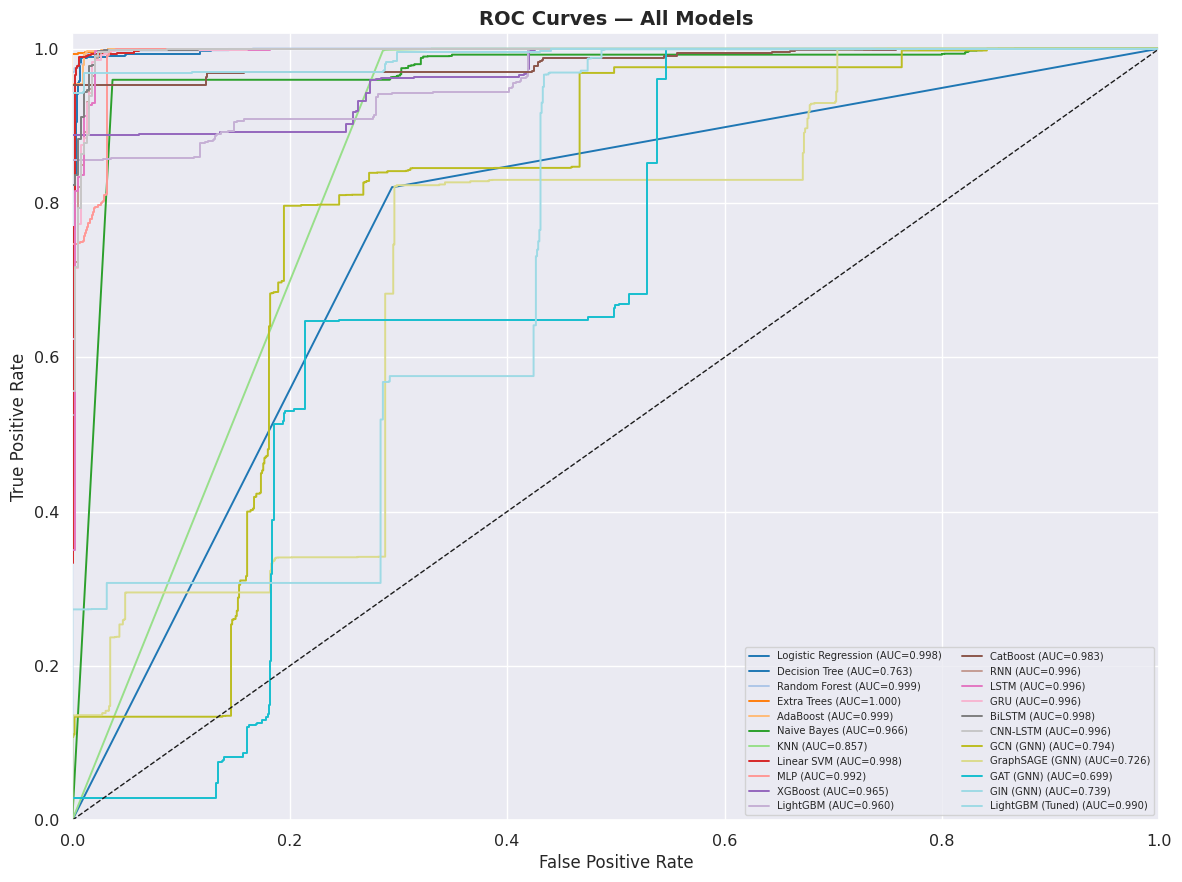

In [38]:
fig, ax = plt.subplots(
    figsize=(12, 9)
)

cmap = cm.get_cmap(
    "tab20",
    max(
        len(all_results),
        1
    )
)

for i, (
    name,
    res
) in enumerate(
    all_results.items()
):
    probs = np.asarray(
        res["_probs"]
    )

    y_t = np.asarray(
        res["_y_true"]
    )

    if (
        len(probs) != len(y_t)
        or
        len(np.unique(y_t)) < 2
    ):
        continue

    try:
        fpr, tpr, _ = roc_curve(
            y_t,
            probs
        )

        roc_auc_v = auc(
            fpr,
            tpr
        )

        ax.plot(
            fpr,
            tpr,
            lw=1.4,
            color=cmap(i),
            label=(
                f"{name} "
                f"(AUC={roc_auc_v:.3f})"
            )
        )

    except Exception:
        pass

ax.plot(
    [0, 1],
    [0, 1],
    "k--",
    lw=1
)

ax.set_xlabel(
    "False Positive Rate"
)
ax.set_ylabel(
    "True Positive Rate"
)
ax.set_title(
    "ROC Curves — All Models",
    fontsize=14,
    fontweight="bold"
)
ax.legend(
    loc="lower right",
    fontsize=7.2,
    ncol=2
)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.02])

plt.tight_layout()
plt.show()

### 22.3 Precision–Recall Curves

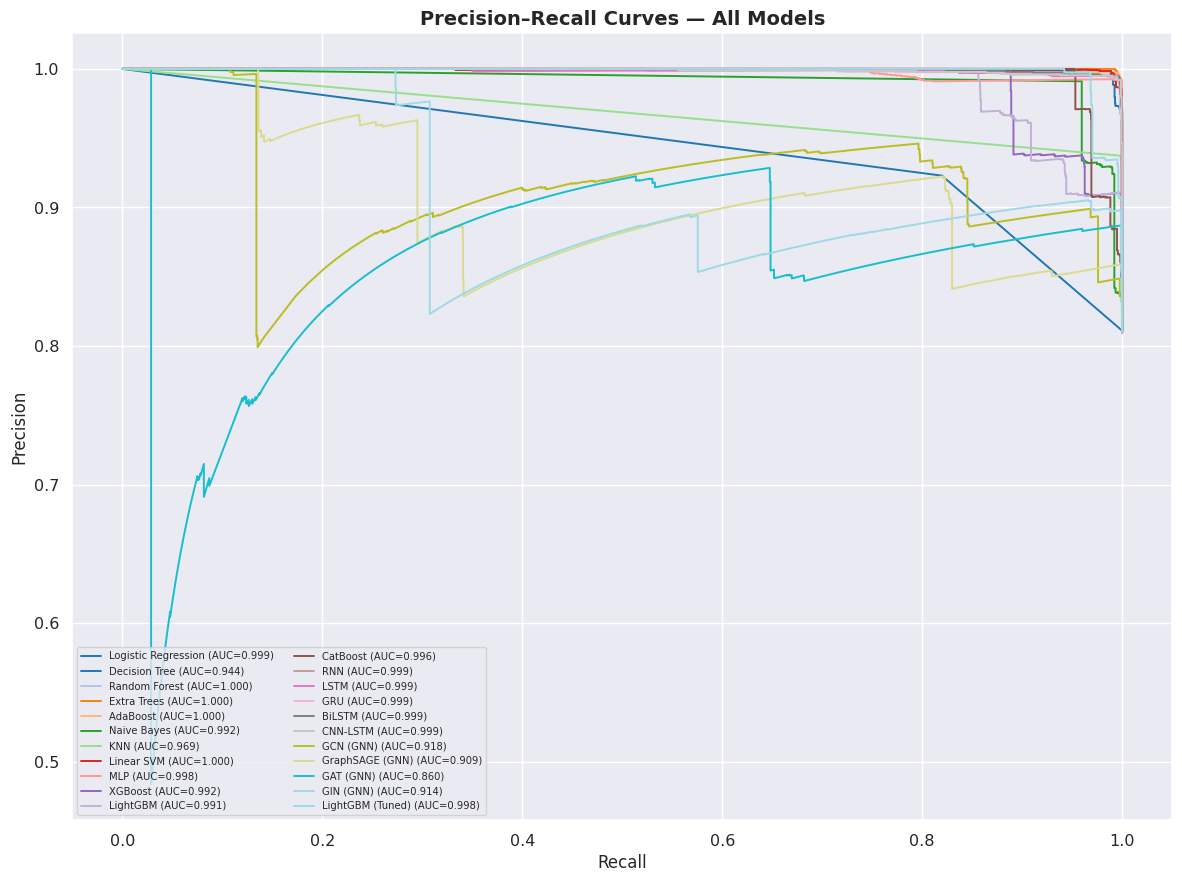

In [39]:
fig, ax = plt.subplots(
    figsize=(12, 9)
)

for i, (
    name,
    res
) in enumerate(
    all_results.items()
):
    probs = np.asarray(
        res["_probs"]
    )

    y_t = np.asarray(
        res["_y_true"]
    )

    if (
        len(probs) != len(y_t)
        or
        len(np.unique(y_t)) < 2
    ):
        continue

    try:
        prec_v, rec_v, _ = (
            precision_recall_curve(
                y_t,
                probs
            )
        )

        pr_auc_v = auc(
            rec_v,
            prec_v
        )

        ax.plot(
            rec_v,
            prec_v,
            lw=1.4,
            color=cmap(i),
            label=(
                f"{name} "
                f"(AUC={pr_auc_v:.3f})"
            )
        )

    except Exception:
        pass

ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title(
    "Precision–Recall Curves — All Models",
    fontsize=14,
    fontweight="bold"
)
ax.legend(
    loc="lower left",
    fontsize=7.2,
    ncol=2
)

plt.tight_layout()
plt.show()

## 23. Comparative Analysis

### 23.1 Ranked Performance & Cost

- Green = classical/tabular
- Blue = sequential deep learning
- Red = GNN

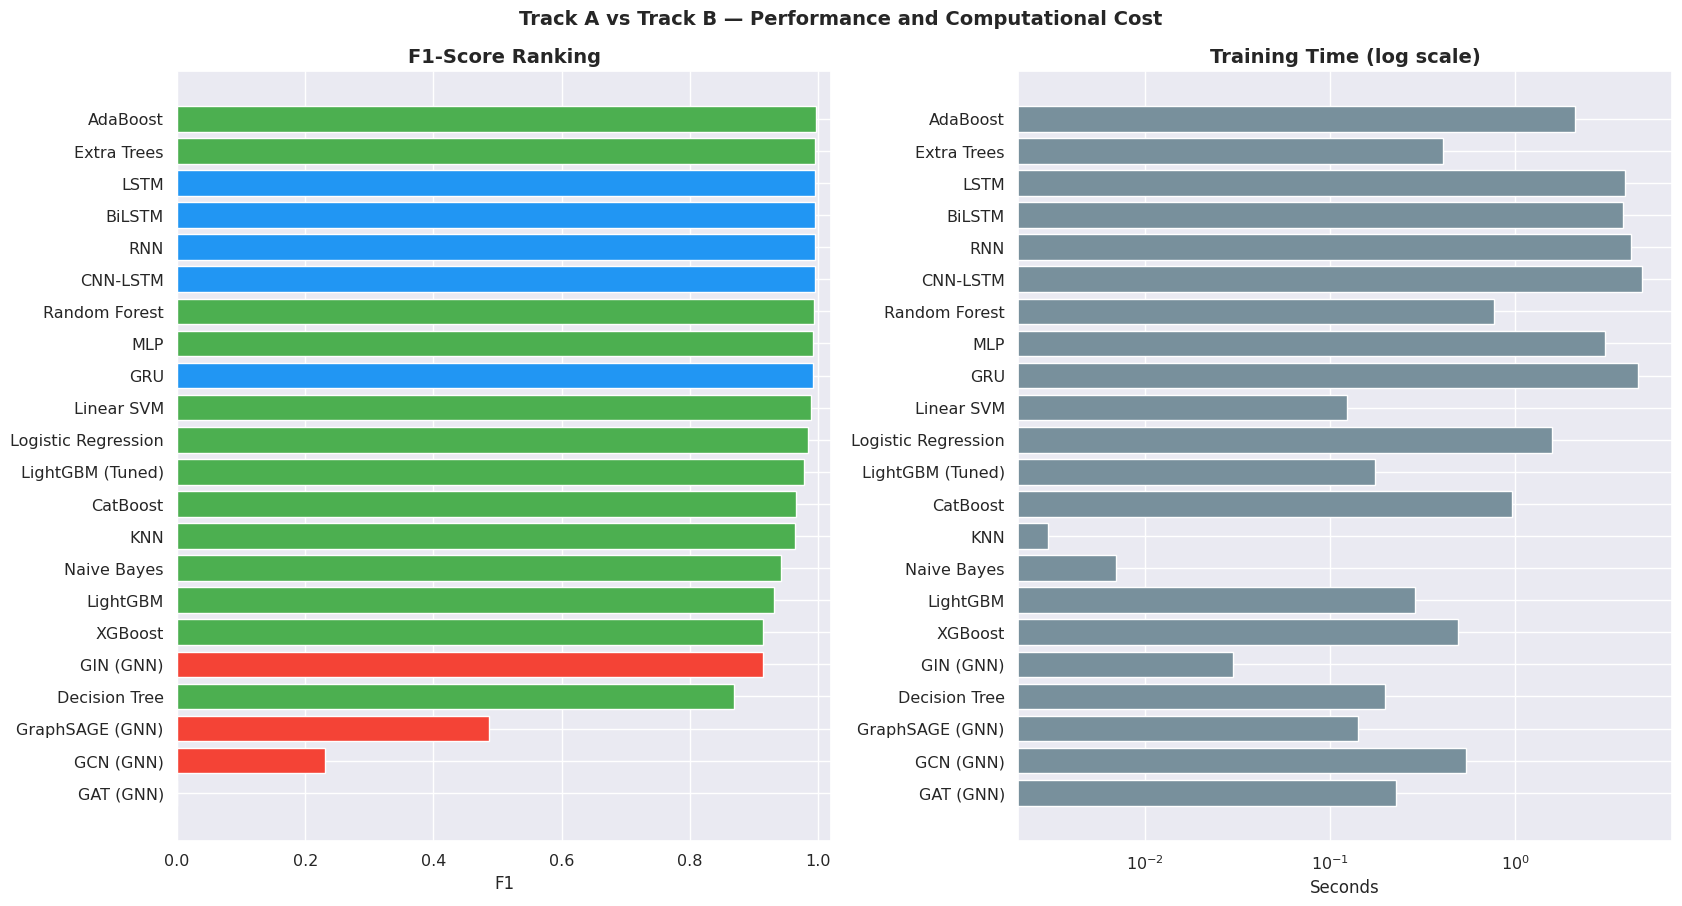

,F1,ROC AUC,PR AUC,FPR,Train Time (s),Scope
AdaBoost,0.995802,0.999413,0.999862,0.012698,2.086,Common connection-disjoint test
Extra Trees,0.995575,0.999804,0.999955,0.032804,0.406,Common connection-disjoint test
LSTM,0.995369,0.995680,0.998711,0.028947,3.886,Ordered-flow sequence test
BiLSTM,0.995062,0.997963,0.999494,0.031579,3.813,Ordered-flow sequence test
RNN,0.995059,0.996191,0.998950,0.028947,4.195,Ordered-flow sequence test
CNN-LSTM,0.994130,0.996085,0.998933,0.031579,4.841,Ordered-flow sequence test
Random Forest,0.993438,0.999379,0.999852,0.010582,0.768,Common connection-disjoint test
MLP,0.992357,0.992241,0.998003,0.033862,3.051,Common connection-disjoint test
GRU,0.992253,0.996222,0.998996,0.026316,4.561,Ordered-flow sequence test
Linear SVM,0.988033,0.998365,0.999512,0.004233,0.124,Common connection-disjoint test


In [40]:
ranked = results_df.sort_values(
    "F1",
    ascending=True
)

def family_color(name):
    if "GNN" in name:
        return "#F44336"

    if any(
        key in name
        for key in [
            "RNN",
            "LSTM",
            "GRU"
        ]
    ):
        return "#2196F3"

    return "#4CAF50"

colors = [
    family_color(n)
    for n in ranked.index
]

fig, axes = plt.subplots(
    1,
    2,
    figsize=(
        17,
        max(
            7,
            len(ranked)*0.42
        )
    )
)

axes[0].barh(
    ranked.index,
    ranked["F1"],
    color=colors
)

axes[0].set_title(
    "F1-Score Ranking",
    fontweight="bold"
)

axes[0].set_xlabel(
    "F1"
)

axes[0].set_xlim(
    0,
    1.02
)

times = (
    ranked["Train Time (s)"]
    .fillna(0.001)
    .clip(lower=0.001)
)

axes[1].barh(
    ranked.index,
    times,
    color="#78909C"
)

axes[1].set_xscale(
    "log"
)

axes[1].set_title(
    "Training Time "
    "(log scale)",
    fontweight="bold"
)

axes[1].set_xlabel(
    "Seconds"
)

plt.suptitle(
    "Track A vs Track B — "
    "Performance and Computational Cost",
    fontsize=14,
    fontweight="bold"
)

plt.tight_layout()
plt.show()

display(
    results_df[[
        "F1",
        "ROC AUC",
        "PR AUC",
        "FPR",
        "Train Time (s)",
        "Scope"
    ]]
    .head(10)
)

### 23.2 Strict Common-Test Comparison

Only models evaluated on **`Common connection-disjoint test`** are used in this direct comparison. Classical ML and GNN models therefore predict exactly the same held-out flow rows.

,Accuracy,Precision,Recall,F1,ROC AUC,PR AUC,FPR,Train Time (s),Model Size (MB)
AdaBoost,0.9932,0.997033,0.994575,0.995802,0.999413,0.999862,0.012698,2.086,0.043460
Extra Trees,0.9928,0.992404,0.998767,0.995575,0.999804,0.999955,0.032804,0.406,1.695560
Random Forest,0.9894,0.997514,0.989396,0.993438,0.999379,0.999852,0.010582,0.768,1.182491
MLP,0.9876,0.992112,0.992602,0.992357,0.992241,0.998003,0.033862,3.051,0.070199
Linear SVM,0.9808,0.998992,0.977312,0.988033,0.998365,0.999512,0.004233,0.124,0.001032
Logistic Regression,0.9738,0.998222,0.969420,0.983611,0.997742,0.999399,0.007407,1.575,0.001143
LightGBM (Tuned),0.9634,0.997431,0.957337,0.976972,0.990208,0.997844,0.010582,0.175,0.123027
CatBoost,0.9448,0.971080,0.960543,0.965782,0.982637,0.996295,0.122751,0.955,0.212951
KNN,0.9378,0.929358,0.999260,0.963042,0.856622,0.937371,0.325926,0.003,3.033342
Naive Bayes,0.9002,0.895991,0.992109,0.941603,0.965553,0.987911,0.494180,0.007,0.002142


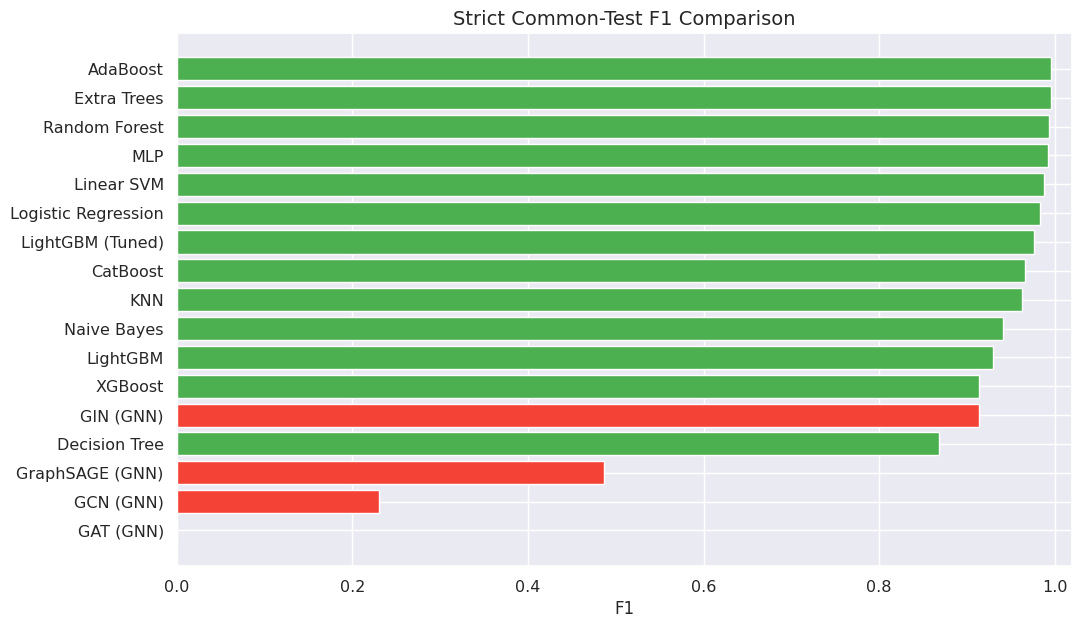

In [41]:
common_df = (
    results_df[
        results_df["Scope"] ==
        "Common connection-disjoint test"
    ]
    .copy()
)

display(
    common_df[[
        "Accuracy",
        "Precision",
        "Recall",
        "F1",
        "ROC AUC",
        "PR AUC",
        "FPR",
        "Train Time (s)",
        "Model Size (MB)"
    ]]
)

if len(common_df):
    fig, ax = plt.subplots(
        figsize=(
            11,
            max(
                5,
                len(common_df)*0.38
            )
        )
    )

    common_sorted = (
        common_df
        .sort_values("F1")
    )

    ax.barh(
        common_sorted.index,
        common_sorted["F1"],
        color=[
            family_color(n)
            for n
            in common_sorted.index
        ]
    )

    ax.set_xlim(
        0,
        1.02
    )

    ax.set_xlabel(
        "F1"
    )

    ax.set_title(
        "Strict Common-Test "
        "F1 Comparison"
    )

    plt.tight_layout()
    plt.show()

### 23.3 McNemar Hypothesis Test — Best Baseline vs Best GNN

**\(H_0\):** the two models have equal paired error probability.  
**\(H_1\):** their paired error probabilities differ.

This is a direct statistical test on the exact same test observations.

In [42]:
baseline_names = [
    n for n in common_df.index
    if "GNN" not in n
]

gnn_names = [
    n for n in common_df.index
    if "GNN" in n
]

if (
    baseline_names
    and
    gnn_names
):
    best_baseline = (
        common_df
        .loc[
            baseline_names,
            "F1"
        ]
        .idxmax()
    )

    best_gnn = (
        common_df
        .loc[
            gnn_names,
            "F1"
        ]
        .idxmax()
    )

    y = np.asarray(
        all_results[
            best_baseline
        ]["_y_true"]
    )

    p_a = np.asarray(
        all_results[
            best_baseline
        ]["_preds"]
    )

    p_b = np.asarray(
        all_results[
            best_gnn
        ]["_preds"]
    )

    assert np.array_equal(
        y,
        np.asarray(
            all_results[
                best_gnn
            ]["_y_true"]
        )
    )

    a_correct = (
        p_a == y
    )

    b_correct = (
        p_b == y
    )

    n01 = int(
        np.sum(
            a_correct &
            ~b_correct
        )
    )

    n10 = int(
        np.sum(
            ~a_correct &
            b_correct
        )
    )

    discordant = (
        n01 +
        n10
    )

    if discordant > 0:
        p_exact = (
            stats.binomtest(
                min(
                    n01,
                    n10
                ),
                n=discordant,
                p=0.5,
                alternative="two-sided"
            )
            .pvalue
        )
    else:
        p_exact = 1.0

    print(
        "Best baseline:",
        best_baseline
    )

    print(
        "Best GNN:",
        best_gnn
    )

    print(
        "n01 "
        "(baseline correct, GNN wrong):",
        n01
    )

    print(
        "n10 "
        "(baseline wrong, GNN correct):",
        n10
    )

    print(
        "Exact McNemar p-value:",
        p_exact
    )

    print(
        "Decision @ α=0.05:",
        (
            "Reject H0"
            if p_exact < 0.05
            else
            "Fail to reject H0"
        )
    )

else:
    print(
        "McNemar test requires "
        "at least one baseline "
        "and one GNN."
    )

Best baseline: AdaBoost
Best GNN: GIN (GNN)
n01 (baseline correct, GNN wrong): 755
n10 (baseline wrong, GNN correct): 21
Exact McNemar p-value: 3.750989185815273e-193
Decision @ α=0.05: Reject H0


### 23.4 Analysis Discussion

**Gradient Boosting Models**  
These models can capture complex non-linear interactions between TON_IoT flow variables and often provide strong low-latency baselines.

**Sequential Deep Learning**  
RNN/LSTM/GRU models inspect short local ordering patterns. Because the network CSV lacks a true flow timestamp, their results should be described as ordered-flow sequence results.

**Graph Neural Networks**  
The GNNs combine:
1. source-host context,
2. destination-host context,
3. host-to-host connectivity,
4. flow-level edge attributes.

This is the central structural advantage of Track B. If a GNN wins on the common connection-disjoint test, that supports the value of relational modelling. If a tabular baseline wins, that is still an important result and should be discussed together with training cost and model size.

## 24. Error Analysis

False negatives are especially costly in intrusion detection because missed attacks can allow attacker dwell time. False positives matter because alert overload degrades analyst trust.

Best common-test model: AdaBoost


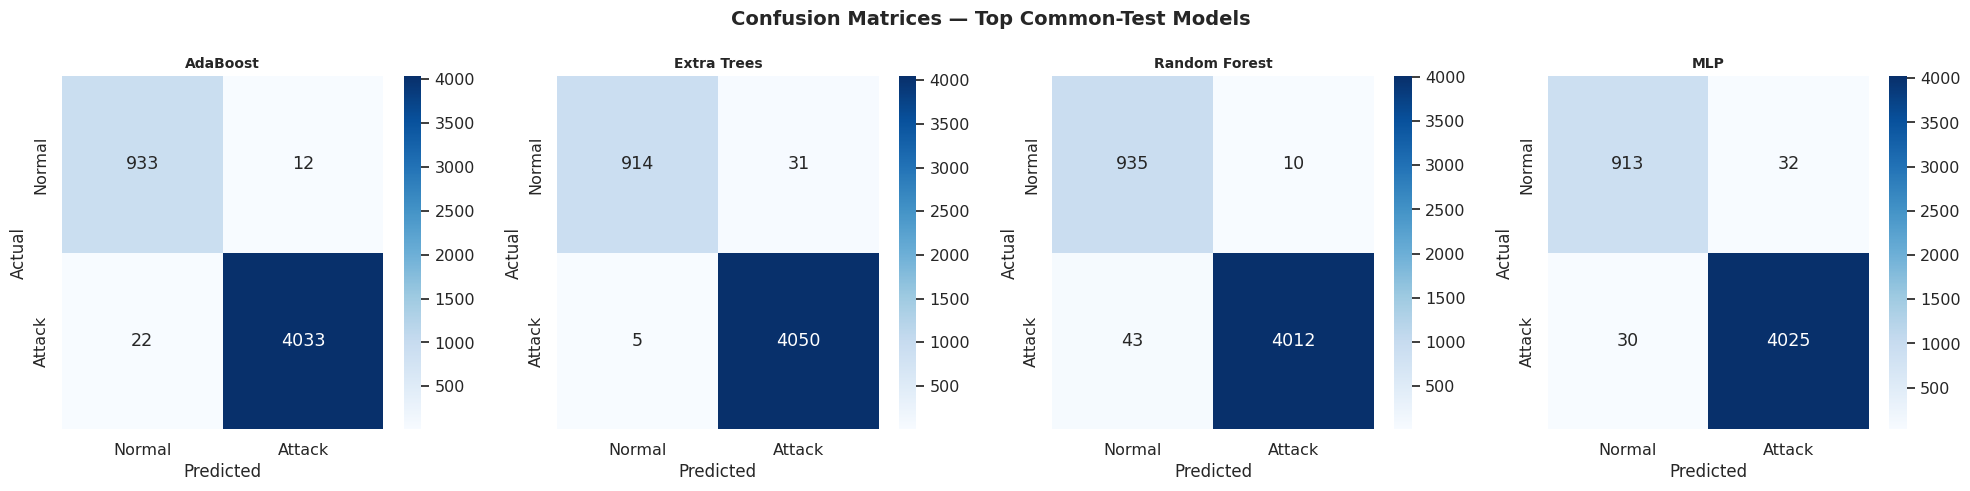


Detailed Classification Report:
              precision    recall  f1-score   support

      Normal       0.98      0.99      0.98       945
      Attack       1.00      0.99      1.00      4055

    accuracy                           0.99      5000
   macro avg       0.99      0.99      0.99      5000
weighted avg       0.99      0.99      0.99      5000


Traffic-type error audit:


,n,actual_attack_rate,accuracy,predicted_attack_rate
type,,,,
xss,614.0,1.0,0.977199,0.977199
normal,945.0,0.0,0.987302,0.012698
backdoor,757.0,1.0,0.993395,0.993395
injection,292.0,1.0,0.996575,0.996575
dos,605.0,1.0,0.998347,0.998347
ransomware,657.0,1.0,0.998478,0.998478
mitm,9.0,1.0,1.000000,1.000000
ddos,466.0,1.0,1.000000,1.000000
password,382.0,1.0,1.000000,1.000000


False positives: 12
False negatives: 22

Sample false positives:


,src_ip,dst_ip,proto,service,type,label,_row_id,prediction,correct
31767,172.17.0.8,192.168.1.190,1.0,0.625,normal,0,117050,1,False
32246,172.17.0.5,192.168.1.190,1.0,0.625,normal,0,118293,1,False
32484,172.17.0.5,192.168.1.190,1.0,0.625,normal,0,118788,1,False
32109,172.17.0.8,192.168.1.190,1.0,0.625,normal,0,118011,1,False
32260,172.17.0.7,192.168.1.190,1.0,0.625,normal,0,118321,1,False
31743,172.17.0.5,192.168.1.190,1.0,0.625,normal,0,116982,1,False
32261,172.17.0.8,192.168.1.190,1.0,0.625,normal,0,118322,1,False
32476,172.17.0.5,192.168.1.190,1.0,0.625,normal,0,118767,1,False
32267,172.17.0.5,192.168.1.190,1.0,0.625,normal,0,118336,1,False
32188,172.17.0.8,192.168.1.190,1.0,0.625,normal,0,118167,1,False


Sample false negatives:


,src_ip,dst_ip,proto,service,type,label,_row_id,prediction,correct
196,192.168.1.193,192.168.1.33,0.5,0.625,backdoor,1,530,0,False
57188,192.168.1.32,52.28.231.150,0.5,0.625,xss,1,199214,0,False
50549,203.14.129.10,192.168.1.33,1.0,0.625,ransomware,1,170179,0,False
59605,192.168.1.32,52.28.231.150,0.5,0.625,xss,1,207049,0,False
58394,192.168.1.32,52.28.231.150,0.5,0.625,xss,1,202533,0,False
22852,192.168.1.30,255.255.255.255,1.0,0.625,injection,1,61874,0,False
186,192.168.1.193,192.168.1.33,0.5,0.625,backdoor,1,468,0,False
58393,192.168.1.32,52.28.231.150,0.5,0.625,xss,1,202532,0,False
201,192.168.1.193,192.168.1.33,0.5,0.625,backdoor,1,535,0,False
54486,192.168.1.32,52.28.231.150,0.5,0.625,xss,1,191990,0,False


In [43]:
best_common_name = (
    common_df["F1"].idxmax()
    if len(common_df)
    else
    results_df["F1"].idxmax()
)

best_res = all_results[
    best_common_name
]

best_preds = np.asarray(
    best_res["_preds"]
)

best_y_true = np.asarray(
    best_res["_y_true"]
)

print(
    "Best common-test model:",
    best_common_name
)

top4 = (
    common_df.index[:4]
    if len(common_df) >= 4
    else common_df.index
)

if len(top4):
    fig, axes = plt.subplots(
        1,
        len(top4),
        figsize=(
            5*len(top4),
            5
        )
    )

    if len(top4) == 1:
        axes = [axes]

    for ax, model_name in zip(
        axes,
        top4
    ):
        res = all_results[
            model_name
        ]

        y_true = np.asarray(
            res["_y_true"]
        )

        preds = np.asarray(
            res["_preds"]
        )

        cm_val = confusion_matrix(
            y_true,
            preds,
            labels=[0, 1]
        )

        sns.heatmap(
            cm_val,
            annot=True,
            fmt="d",
            cmap="Blues",
            ax=ax,
            xticklabels=[
                "Normal",
                "Attack"
            ],
            yticklabels=[
                "Normal",
                "Attack"
            ]
        )

        ax.set_title(
            model_name,
            fontsize=10,
            fontweight="bold"
        )

        ax.set_xlabel(
            "Predicted"
        )

        ax.set_ylabel(
            "Actual"
        )

    plt.suptitle(
        "Confusion Matrices — "
        "Top Common-Test Models",
        fontsize=14,
        fontweight="bold"
    )

    plt.tight_layout()
    plt.show()

print(
    "\nDetailed Classification Report:"
)

print(
    classification_report(
        best_y_true,
        best_preds,
        target_names=[
            "Normal",
            "Attack"
        ],
        zero_division=0
    )
)

if len(best_preds) == len(ml_te):
    audit_df = (
        ml_te[[
            "src_ip",
            "dst_ip",
            "proto",
            "service",
            "type",
            "label",
            "_row_id"
        ]]
        .copy()
    )

    audit_df[
        "prediction"
    ] = best_preds

    audit_df[
        "correct"
    ] = (
        audit_df["label"]
        .astype(int)
        ==
        audit_df["prediction"]
        .astype(int)
    )

    attack_audit = (
        audit_df
        .groupby("type")
        .apply(
            lambda g:
            pd.Series({
                "n": len(g),
                "actual_attack_rate":
                    g["label"].mean(),
                "accuracy":
                    g["correct"].mean(),
                "predicted_attack_rate":
                    g["prediction"].mean()
            })
        )
        .sort_values(
            "accuracy"
        )
    )

    print(
        "\nTraffic-type error audit:"
    )
    display(
        attack_audit
    )

    fp = audit_df[
        (
            audit_df["label"] == 0
        )
        &
        (
            audit_df["prediction"] == 1
        )
    ]

    fn = audit_df[
        (
            audit_df["label"] == 1
        )
        &
        (
            audit_df["prediction"] == 0
        )
    ]

    print(
        f"False positives: "
        f"{len(fp):,}"
    )

    print(
        f"False negatives: "
        f"{len(fn):,}"
    )

    print(
        "\nSample false positives:"
    )
    display(
        fp.head(10)
    )

    print(
        "Sample false negatives:"
    )
    display(
        fn.head(10)
    )

## 25. Discussion

### Statistical Significance
- Section 7 tests whether TON_IoT numerical features differ between benign and attack populations.
- Section 23 compares the best classical baseline and best GNN with an exact paired McNemar test.
- Statistical significance should always be interpreted together with effect size, false-positive rate and computational cost.

### Security Implications

**False Negatives**  
Recall is critical because missed malicious flows can permit persistence, lateral movement or exfiltration.

**False Positives**  
A high FPR creates alert fatigue. Operational IDS models therefore need both high recall and acceptable precision.

**Why Graph Connections Matter**  
The main graph represents real communications: `source host → destination host`. Scanning fan-out, DDoS fan-in and repeated abnormal relationships are visible through connectivity, node degree and message passing.

### Limitations
1. `train_test_network.csv` does not expose a true flow timestamp.
2. The connection-disjoint split is intentionally harder than a random-flow split.
3. GNN node features are label-free but are aggregated from each graph partition.
4. The notebook is sample-limited for runtime; full-data retraining may change rankings.
5. TON_IoT is a controlled cybersecurity testbed.
6. Binary classification is the main comparison; multiclass `type` is used in EDA and error analysis.

## 26. Conclusion & Future Work

### Conclusion

This notebook preserves the supplied sample notebook's complete A-to-Z workflow while adapting it to the TON_IoT schema and the graph-centric Group-A project.

It includes:
- full EDA,
- descriptive statistics,
- normality testing,
- Mann–Whitney tests,
- correlation analysis,
- ADF/KPSS/ACF/PACF,
- real IoT telemetry inter-arrival analysis,
- cleaning,
- feature engineering,
- encoding,
- scaling,
- class imbalance handling,
- classical ML baselines,
- sequential deep-learning baselines,
- supplementary k-NN flow graph,
- real directed host-communication graph,
- GCN, GraphSAGE, GAT and GIN edge classifiers,
- Optuna tuning,
- ROC/PR evaluation,
- strict common-test comparison,
- McNemar significance testing,
- error analysis.

### Future Work

1. True dynamic temporal graphs using original timestamps.
2. Heterogeneous host/port/protocol/service/device graphs.
3. Temporal GNNs: TGN, TGAT, DySAT, EvolveGCN.
4. Multiclass attack-type edge classification.
5. GNN explainability and attention visualisation.
6. Sparse PyG implementation for full-scale training.
7. Fusion of network + IoT + Linux + Windows telemetry.
8. Online/streaming intrusion detection.
9. Adversarial robustness testing.
10. Ablation: edge-only vs topology-only vs full GNN.

## 27. References & Reproducibility

### Core References

1. A. Alsaedi, N. Moustafa, Z. Tari, A. Mahmood, and A. Anwar, **“TON_IoT Telemetry Dataset: A New Generation Dataset of IoT and IIoT for Data-Driven Intrusion Detection Systems,”** *IEEE Access*, vol. 8, pp. 165130–165150, 2020. DOI: 10.1109/ACCESS.2020.3022862.

2. T. N. Kipf and M. Welling, **“Semi-Supervised Classification with Graph Convolutional Networks,”** ICLR, 2017.

3. W. L. Hamilton, R. Ying, and J. Leskovec, **“Inductive Representation Learning on Large Graphs,”** NeurIPS, 2017.

4. P. Veličković et al., **“Graph Attention Networks,”** ICLR, 2018.

5. K. Xu, W. Hu, J. Leskovec, and S. Jegelka, **“How Powerful are Graph Neural Networks?”** ICLR, 2019.

### Reproducibility Checklist

- [x] Fixed random seed
- [x] Library versions printed
- [x] Kaggle dataset path auto-discovery
- [x] No hard-coded Kaggle dataset slug
- [x] Directed train/test connections are disjoint
- [x] Scaler fitted only on training partition
- [x] Category encoders fitted only on training partition
- [x] Hyperparameter tuning uses validation, not final test
- [x] Test labels are not used to construct features
- [x] Classical ML and GNN use the same common test rows
- [x] Metrics are produced by executed code

### Viva — Key Objects

| Object | Meaning |
|---|---|
| `graph_fit["node_x"]` | `[N_hosts, 8]` label-free host features |
| `graph_fit["adj_msg"]` | `[N_hosts, N_hosts]` message-passing adjacency |
| `graph_fit["src"]` | source host index per flow |
| `graph_fit["dst"]` | destination host index per flow |
| `graph_fit["edge_x"]` | selected flow-level GNN edge features |
| `graph_fit["y"]` | binary flow labels |
| `X_seq_tr` | ordered-flow sequences |

### Likely Viva Questions

1. Why are IP addresses graph nodes?
2. Why is each flow an edge?
3. Why not use random row splitting?
4. What is the difference between the main host graph and k-NN similarity graph?
5. Why is GraphSAGE inductive?
6. Why is GAT useful for variable neighbour importance?
7. What does GIN change relative to GCN?
8. What is in `edge_x`?
9. Why are labels excluded from node features?
10. Why is PR-AUC important?
11. What does McNemar's test evaluate?
12. How would you add true temporal graph snapshots?